# Banco de pruebas v2 — TFG Solar ABM

Comparación sistemática de reglas de aprendizaje para el modelo ABM.

**Estructura:**
- §0–§1: setup y parametrizaciones de mercado
- §2: óptimo numérico de referencia (homogéneo + per-agente BR)
- §3: runner con regla inyectable (monkey-patch)
- §4: métricas y visualizaciones genéricas
- §5: definiciones de las 4 reglas
- §6–§9: una sección por regla con plantilla idéntica
- §10: comparativa cross-rule

**Regla de oro:** las celdas de visualización solo leen `resultado_<regla>` almacenado. Cambiar los filtros (agentes, fracciones, días) NO dispara re-simulación — solo se re-dibuja.


## §0 Setup


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Localiza workspace/scripts
here = Path.cwd()
for p in [here, *here.parents]:
    cand = p / 'workspace' / 'scripts'
    if cand.exists():
        sys.path.insert(0, str(cand)); break
    cand2 = p / 'scripts'
    if cand2.exists() and (p / 'notebooks').exists():
        sys.path.insert(0, str(cand2)); break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from model import SolarAgent, MarketModel, DEFAULT_PARAMS, stable_softmax

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
print('Setup OK')


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup OK


## §1 Parametrizaciones de mercado

Dos puntos de referencia: **ESQUINA** (solar muy limitada, ratio precios ≈ 0.58 independiente de eta) e **INTERIOR** (solar holgada en E, óptimo interior < 1).


In [2]:
PARAMS_ESQUINA = {
    'N': 30,
    'DEMAND_M': 60.0,
    'DEMAND_E': 120.0,
    'CAP_LOW': 0.8,
    'CAP_HIGH': 1.2,
    'STOR_CAP_LOW': 0.5,
    'STOR_CAP_HIGH': 2.0,
    'STORAGE_GRAN': 10,
}

PARAMS_INTERIOR = {
    'N': 30,
    'DEMAND_M': 80.0,
    'DEMAND_E': 120.0,
    'CAP_LOW': 2.5,
    'CAP_HIGH': 2.5,
    'STOR_CAP_LOW': 10,
    'STOR_CAP_HIGH': 10,
    'STORAGE_GRAN': 10,
}


## §2 Referencias homogéneas para juzgar la convergencia del ABM

Tres referencias con interpretaciones distintas:

- **§2.1 Cartel (óptimo cooperativo)**: f que maximiza el `profit/agente` cuando todos van al unísono. Equivale al óptimo del agente representativo. Es el techo si los agentes pudieran coordinarse.
- **§2.2 Nash homogéneo simétrico**: f tal que `BR(f) = f` (punto fijo de la mejor respuesta). Es el equilibrio al que deberían converger los agentes ABM individualmente racionales. Suele estar **por encima** del cartel (cada agente tiene incentivo a almacenar más para aprovechar el P_E que el cartel sostiene).
- **§2.3 BR per-agente**: diagnóstico — anclando en el Nash, los `f_i*` deberían ser ≈ Nash si los agentes son homogéneos. Si son heterogéneos, ver cómo se desvían según `storage_capacity`/`capacity`.

**Nota sobre la condición ratio = η**: es la aproximación del Nash en el límite N→∞ (price-takers). Para N finito hay una corrección de poder de mercado, generalmente pequeña.


### §2.1 Cartel (óptimo cooperativo del agente representativo)


#### §2.1.1 Óptimo del agente único — CPO analítica (sección 4.6.1)

Resolución numérica de la condición de primer orden derivada en la sección 4.6.1 del TFG. Para un agente representativo (equivalente al cártel de N agentes homogéneos) se calcula:

- Capacidad agregada $M = N \alpha_M c$, $\,E = N \alpha_E c$ y batería agregada $s_{\text{agg}} = N s$.
- $\pi(f)$ y $d\pi/df$ explícitas como funciones de $f$.
- Raíz de $d\pi/df$ en el régimen interior con `scipy.optimize.brentq`.
- Detección automática de bordes (esquina inferior, esquina superior, saturación de batería).

Esta referencia debería coincidir con el `cooperativo` del grid search §2.1.2 (pero más precisa: la CPO no está limitada por el paso del grid).


=== Óptimo del agente único (CPO 4.6.1) ===
  Régimen          : interior
  f*               : 0.4753
  π(f*) agregado   : 8531.28
  π(f*) / N        : 284.38
  P_M(f*)          : 86.030
  P_E(f*)          : 137.051
  P_M/P_E en f*    : 0.628   (η = 0.900)
  f saturación     : 6.349


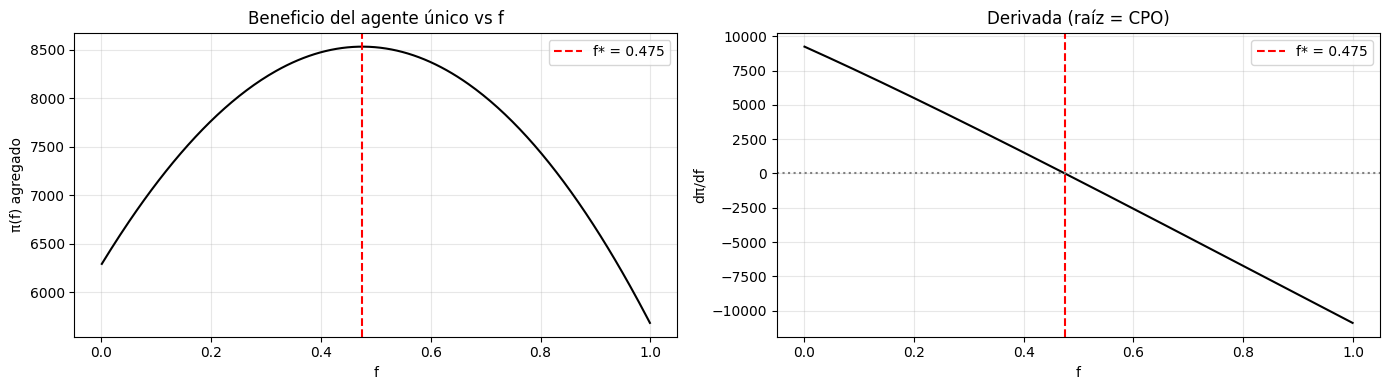

In [3]:
from scipy.optimize import brentq

def solve_unico_cpo(params=None):
    """Resuelve la CPO de la sección 4.6.1 para el agente único representativo
    (cártel de N agentes homogéneos).

    Notación:
        M = N · α_M · c   (producción bruta agregada de mañana, ε=1)
        E = N · α_E · c   (producción bruta agregada de tarde, ε=1)
        s_agg = N · s     (capacidad agregada de batería)

    En régimen interior (gas en ambos periodos, batería no saturada):

        dπ/df = M · { α_G γ_G · q^M · g^M^(γ_G-1) - P_M
                    - α_G γ_G η · q^E · g^E^(γ_G-1) + η P_E }

    con q^M = (1-f)M, q^E = E + η f M, g^M = D_M - q^M, g^E = D_E - q^E,
    P_M = c0 + α_G g^M^γ_G, P_E = c0 + α_G g^E^γ_G.
    """
    p = {**DEFAULT_PARAMS, **(params or {})}
    n_agents = p['N']
    c_agg = n_agents * (p['CAP_LOW'] + p['CAP_HIGH']) / 2.0
    M = p['ALPHA_M'] * c_agg
    E = p['ALPHA_E'] * c_agg
    eta = (p['ETA_LOW'] + p['ETA_HIGH']) / 2.0
    D_M, D_E = p['DEMAND_M'], p['DEMAND_E']
    c0, ag, gg = p['C0'], p['ALPHA_G'], p['GAMMA_G']
    s_agg = n_agents * (p['STOR_CAP_LOW'] + p['STOR_CAP_HIGH']) / 2.0
    f_sat = s_agg / (eta * M) if eta * M > 0 else float('inf')

    def pi(f):
        qM = (1 - f) * M
        S = min(s_agg, eta * f * M)
        qE = E + S
        gM = max(D_M - qM, 0.0)
        gE = max(D_E - qE, 0.0)
        PM = c0 + ag * gM**gg if gM > 0 else 0.0
        PE = c0 + ag * gE**gg if gE > 0 else 0.0
        return PM * qM + PE * qE

    def dpi_interior(f):
        qM = (1 - f) * M
        qE = E + eta * f * M
        gM = D_M - qM
        gE = D_E - qE
        PM = c0 + ag * gM**gg
        PE = c0 + ag * gE**gg
        return M * (
            ag * gg * qM * gM**(gg - 1) - PM
            - ag * gg * eta * qE * gE**(gg - 1) + eta * PE
        )

    f_max = min(0.999, f_sat - 1e-6) if f_sat <= 1 else 0.999
    if dpi_interior(1e-3) <= 0:
        f_star, regimen = 0.0, 'esquina_inferior'
    elif dpi_interior(f_max) >= 0:
        f_star = min(1.0, f_sat)
        regimen = 'saturacion' if f_sat <= 1 else 'esquina_superior'
    else:
        f_star = brentq(dpi_interior, 1e-3, f_max, xtol=1e-8)
        regimen = 'interior'

    qM = (1 - f_star) * M
    S = min(s_agg, eta * f_star * M)
    qE = E + S
    gM = max(D_M - qM, 0.0); gE = max(D_E - qE, 0.0)
    PM = c0 + ag * gM**gg if gM > 0 else 0.0
    PE = c0 + ag * gE**gg if gE > 0 else 0.0

    return {
        'f_star': f_star,
        'pi_star': pi(f_star),
        'PM_star': PM, 'PE_star': PE,
        'ratio_star': PM / PE if PE > 0 else float('inf'),
        'regimen': regimen,
        'M_agg': M, 'E_agg': E, 'eta': eta, 'f_sat': f_sat,
        '_pi': pi, '_dpi': dpi_interior,
    }


optimo_unico = solve_unico_cpo(PARAMS_INTERIOR)

print('=== Óptimo del agente único (CPO 4.6.1) ===')
print(f"  Régimen          : {optimo_unico['regimen']}")
print(f"  f*               : {optimo_unico['f_star']:.4f}")
print(f"  π(f*) agregado   : {optimo_unico['pi_star']:.2f}")
print(f"  π(f*) / N        : {optimo_unico['pi_star'] / PARAMS_INTERIOR['N']:.2f}")
print(f"  P_M(f*)          : {optimo_unico['PM_star']:.3f}")
print(f"  P_E(f*)          : {optimo_unico['PE_star']:.3f}")
print(f"  P_M/P_E en f*    : {optimo_unico['ratio_star']:.3f}   (η = {optimo_unico['eta']:.3f})")
print(f"  f saturación     : {optimo_unico['f_sat']:.3f}")

# Curva π(f) y dπ/df
f_upper = min(0.999, optimo_unico['f_sat'] - 1e-3) if optimo_unico['f_sat'] <= 1 else 0.999
fs = np.linspace(0.001, f_upper, 300)
pis = np.array([optimo_unico['_pi'](f) for f in fs])
dpis = np.array([optimo_unico['_dpi'](f) for f in fs])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(fs, pis, color='black')
ax1.axvline(optimo_unico['f_star'], color='red', linestyle='--',
            label=f"f* = {optimo_unico['f_star']:.3f}")
ax1.set_xlabel('f'); ax1.set_ylabel('π(f) agregado')
ax1.set_title('Beneficio del agente único vs f')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(fs, dpis, color='black')
ax2.axhline(0, color='gray', linestyle=':')
ax2.axvline(optimo_unico['f_star'], color='red', linestyle='--',
            label=f"f* = {optimo_unico['f_star']:.3f}")
ax2.set_xlabel('f'); ax2.set_ylabel('dπ/df')
ax2.set_title('Derivada (raíz = CPO)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


#### §2.1.2 Verificación con grid search

Cross-check de la CPO analítica de §2.1.1 corriendo simulaciones forzadas con f homogénea y eligiendo la f que maximiza el `profit/agente`. Debería dar lo mismo (módulo paso del grid).


In [4]:
def run_with_forced_f(f_fixed, params=None, seed=0, days=200, storage_enabled=True):
    """Corre simulación forzando que TODOS los agentes usen f_fixed (sin aprendizaje)."""
    original_produce = SolarAgent.produce_and_decide
    original_update = SolarAgent.update_learning

    def patched_produce(self):
        p = self.model.params
        eps = random.uniform(1 - p['WEATHER_VAR'], 1 + p['WEATHER_VAR'])
        self.qM_raw = p['ALPHA_M'] * self.capacity * eps
        self.qE_raw = p['ALPHA_E'] * self.capacity * eps
        choice = f_fixed
        self.last_choice = choice
        self.stored = min(self.storage_capacity, self.eta * choice * self.qM_raw)
        self.qM = (1.0 - choice) * self.qM_raw
        self.qE = self.qE_raw + self.stored

    def patched_update(self, profit):
        self.profit = profit

    SolarAgent.produce_and_decide = patched_produce
    SolarAgent.update_learning = patched_update
    try:
        model = MarketModel(params=params, storage_enabled=storage_enabled, seed=seed)
        for _ in range(days):
            model.step_day()
        return model, model.get_model_data(), model.get_agent_data()
    finally:
        SolarAgent.produce_and_decide = original_produce
        SolarAgent.update_learning = original_update


def compute_cartel_grid(params=None, grid=21, seeds=range(3), days=200, last=100):
    """Cartel via grid search sobre f homogéneo (cross-check del óptimo analítico §2.1.1).

    Devuelve dict con `f_star`, `profit_star`, `price_M_star`, `price_E_star`, `ratio_star`
    (apuntan al cartel, compatibles con `resumen_metricas`), más:
    - `cooperativo`: subdict redundante con las claves del cartel (acceso explícito)
    - `price_taker_approx`: f donde ratio=η, INFORMATIVA. Es la aproximación Nash N→∞,
      NO es el Nash real para N finito (ver §2.2 para Nash real via BR fixed-point)
    - `detalle`, `resumen`, `eta_referencia`
    """
    fs = np.linspace(0, 1, grid)
    rows = []
    for f in fs:
        for seed in seeds:
            _, df, _ = run_with_forced_f(float(f), params=params, seed=seed, days=days)
            tail = df.tail(last)
            rows.append({
                'f': float(f), 'seed': seed,
                'profit': tail['avg_profit'].mean(),
                'price_M': tail['price_M'].mean(),
                'price_E': tail['price_E'].mean(),
            })
    detalle = pd.DataFrame(rows)
    resumen = detalle.groupby('f').mean(numeric_only=True).reset_index()
    resumen['ratio'] = resumen['price_M'] / resumen['price_E'].clip(lower=1e-9)

    idx_coop = int(resumen['profit'].idxmax())
    coop = {
        'f_star': float(resumen.loc[idx_coop, 'f']),
        'profit_star': float(resumen.loc[idx_coop, 'profit']),
        'price_M_star': float(resumen.loc[idx_coop, 'price_M']),
        'price_E_star': float(resumen.loc[idx_coop, 'price_E']),
        'ratio_star': float(resumen.loc[idx_coop, 'ratio']),
    }

    p_eff = {**DEFAULT_PARAMS, **(params or {})}
    eta_ref = (p_eff['ETA_LOW'] + p_eff['ETA_HIGH']) / 2.0
    diff = (resumen['ratio'] - eta_ref).values
    if diff[0] * diff[-1] < 0:
        signs = np.sign(diff)
        idx = int(np.where(signs[:-1] * signs[1:] <= 0)[0][0])
        d0, d1 = diff[idx], diff[idx + 1]
        t = -d0 / (d1 - d0) if abs(d1 - d0) > 1e-12 else 0.0
        def lerp(col):
            v0 = resumen.loc[idx, col]; v1 = resumen.loc[idx + 1, col]
            return float(v0 + t * (v1 - v0))
        pt = {'f_star': lerp('f'), 'profit_star': lerp('profit'),
              'price_M_star': lerp('price_M'), 'price_E_star': lerp('price_E'),
              'ratio_star': lerp('ratio'), 'corner': False}
    elif (diff < 0).all():
        idx_n = len(resumen) - 1
        pt = {'f_star': 1.0, 'profit_star': float(resumen.loc[idx_n, 'profit']),
              'price_M_star': float(resumen.loc[idx_n, 'price_M']),
              'price_E_star': float(resumen.loc[idx_n, 'price_E']),
              'ratio_star': float(resumen.loc[idx_n, 'ratio']), 'corner': True}
    else:
        pt = {'f_star': 0.0, 'profit_star': float(resumen.loc[0, 'profit']),
              'price_M_star': float(resumen.loc[0, 'price_M']),
              'price_E_star': float(resumen.loc[0, 'price_E']),
              'ratio_star': float(resumen.loc[0, 'ratio']), 'corner': True}

    return {
        # Top-level = cartel (compatible con resumen_metricas)
        'f_star': coop['f_star'],
        'profit_star': coop['profit_star'],
        'price_M_star': coop['price_M_star'],
        'price_E_star': coop['price_E_star'],
        'ratio_star': coop['ratio_star'],
        # Subdicts
        'cooperativo': coop,
        'price_taker_approx': pt,    # informativa, NO es Nash real
        'eta_referencia': eta_ref,
        'detalle': detalle,
        'resumen': resumen,
    }


# Alias de compatibilidad: en versiones anteriores se llamaba compute_optimal_f_homogeneo
compute_optimal_f_homogeneo = compute_cartel_grid


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


=== Cartel (grid search) ===
  f_cartel       = 0.4750
  profit_cartel  = 284.31
  ratio_cartel   = 0.627

=== Cross-check vs §2.1.1 (analítica) ===
  f_analitico    = 0.4753  (régimen: interior)
  diferencia f   = 0.0003  (debería ser <= paso del grid)

=== Aproximación price-taker (lim N→∞, INFORMATIVA) ===
  f_pt           = 0.6497
  ratio_pt       = 0.900  (η = 0.900)
  NOTA: esto NO es el Nash real para N finito. Ver §2.2 para Nash real.


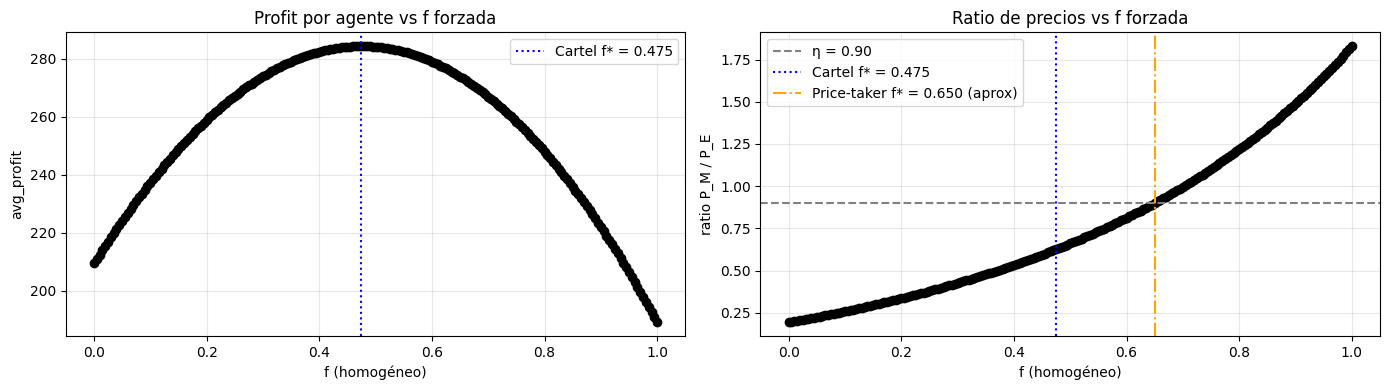

In [5]:
# Cartel via grid search (cross-check del analítico §2.1.1)
optimo_homogeneo = compute_cartel_grid(
    params=PARAMS_INTERIOR, grid=201, seeds=range(3), days=200, last=100,
)

c = optimo_homogeneo['cooperativo']
pt = optimo_homogeneo['price_taker_approx']
print('=== Cartel (grid search) ===')
print(f"  f_cartel       = {c['f_star']:.4f}")
print(f"  profit_cartel  = {c['profit_star']:.2f}")
print(f"  ratio_cartel   = {c['ratio_star']:.3f}")

print('\n=== Cross-check vs §2.1.1 (analítica) ===')
try:
    print(f"  f_analitico    = {optimo_unico['f_star']:.4f}  (régimen: {optimo_unico['regimen']})")
    print(f"  diferencia f   = {abs(c['f_star'] - optimo_unico['f_star']):.4f}  (debería ser <= paso del grid)")
except NameError:
    print('  (ejecuta §2.1.1 antes para comparar)')

print('\n=== Aproximación price-taker (lim N→∞, INFORMATIVA) ===')
print(f"  f_pt           = {pt['f_star']:.4f}{' (esquina)' if pt.get('corner') else ''}")
print(f"  ratio_pt       = {pt['ratio_star']:.3f}  (η = {optimo_homogeneo['eta_referencia']:.3f})")
print(f"  NOTA: esto NO es el Nash real para N finito. Ver §2.2 para Nash real.")

# Plot perfil profit + ratio vs f
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
_resumen = optimo_homogeneo['resumen']
ax1.plot(_resumen['f'], _resumen['profit'], 'o-', color='black')
ax1.axvline(c['f_star'], color='blue', linestyle=':', label=f"Cartel f* = {c['f_star']:.3f}")
ax1.set_xlabel('f (homogéneo)'); ax1.set_ylabel('avg_profit')
ax1.set_title('Profit por agente vs f forzada')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(_resumen['f'], _resumen['ratio'], 'o-', color='black')
ax2.axhline(optimo_homogeneo['eta_referencia'], color='gray', linestyle='--',
            label=f"η = {optimo_homogeneo['eta_referencia']:.2f}")
ax2.axvline(c['f_star'], color='blue', linestyle=':', label=f"Cartel f* = {c['f_star']:.3f}")
ax2.axvline(pt['f_star'], color='orange', linestyle='-.',
            label=f"Price-taker f* = {pt['f_star']:.3f} (aprox)")
ax2.set_xlabel('f (homogéneo)'); ax2.set_ylabel('ratio P_M / P_E')
ax2.set_title('Ratio de precios vs f forzada')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### §2.2 Nash homogéneo via best-response fixed-point

El Nash simétrico es la f tal que **BR(f) = f**: si los demás están en f, mi mejor respuesta también es f, y nadie quiere desviarse. Es el equilibrio relevante para los agentes ABM.

Notar que es inviable hacer el cálculo con N agentes heterogéneos. Aparte de aumentar el coste computacional de 1×grid×grid
a N×grid×grid, habría que iterar varias veces sobre los resultados para buscar convergencia (no asegurada).

**Algoritmo:**
1. Para cada `f_h` en un grid: corre simulación con todos a `f_h` excepto un agente representativo, evalúa BR(`f_h`) buscando el `f_i` que maximiza su profit.
2. Encuentra el `f_h` donde la curva BR(`f_h`) cruza la diagonal — ese es el Nash.

**Por qué no basta con la condición ratio = η:** esa es la aproximación price-taker (N→∞). Para N finito, las desviaciones individuales mueven los precios, y el Nash real queda ligeramente por debajo del price-taker. Con N=30 la diferencia es pequeña (~0.02) pero suficiente para que la BR no cuadre exactamente.


In [6]:
def run_with_forced_f_heterogeneo(f_per_agent, params=None, seed=0, days=200):
    """Cada agente usa su f propia (dict agent_id → f). Sin aprendizaje."""
    original_produce = SolarAgent.produce_and_decide
    original_update = SolarAgent.update_learning

    def patched_produce(self):
        p = self.model.params
        eps = random.uniform(1 - p['WEATHER_VAR'], 1 + p['WEATHER_VAR'])
        self.qM_raw = p['ALPHA_M'] * self.capacity * eps
        self.qE_raw = p['ALPHA_E'] * self.capacity * eps
        choice = f_per_agent.get(self.unique_id, 0.0)
        self.last_choice = choice
        self.stored = min(self.storage_capacity, self.eta * choice * self.qM_raw)
        self.qM = (1.0 - choice) * self.qM_raw
        self.qE = self.qE_raw + self.stored

    def patched_update(self, profit):
        self.profit = profit

    SolarAgent.produce_and_decide = patched_produce
    SolarAgent.update_learning = patched_update
    try:
        model = MarketModel(params=params, seed=seed)
        for _ in range(days):
            model.step_day()
        return model, model.get_model_data(), model.get_agent_data()
    finally:
        SolarAgent.produce_and_decide = original_produce
        SolarAgent.update_learning = original_update


In [7]:
def compute_nash_homogeneo_BR(params=None, f_h_grid=None, f_i_grid=None,
                                seed=0, days=150, last=50):
    """Encuentra Nash homogéneo via BR fixed-point.

    Para cada `f_h` en `f_h_grid`: calcula BR(`f_h`) = argmax_{f_i} profit_i
    asumiendo a los demás en `f_h`. Por simetría basta UN agente representativo.
    El Nash es donde BR(`f_h`) = `f_h` (cruce con la diagonal, interpolado).

    En 2 fases:
    Fase exhaustiva: para CADA f_h en el grid (los 12 puntos - default), evalúa BR(f_h) probando los 21 valores de f_i y quedándose con el argmax. Hace los 12 × 21 = 252 sims.
    Fase de localización: con la curva BR completa, busca dónde gap = BR(f_h) - f_h cambia de signo. En ese intervalo, interpolación lineal para sacar Nash con precisión sub-grid.
    """
    if f_h_grid is None:
        f_h_grid = np.round(np.linspace(0.3, 0.85, 12), 3)
    if f_i_grid is None:
        f_i_grid = np.linspace(0.0, 1.0, 21)

    template = MarketModel(params=params, seed=seed)
    agent_ids = sorted(a.unique_id for a in template.agents)
    target = agent_ids[0]

    rows = []
    for f_h in f_h_grid:
        profits = []
        for f_i in f_i_grid:
            f_assign = {aid: float(f_h) for aid in agent_ids}
            f_assign[target] = float(f_i)
            _, _, df_a = run_with_forced_f_heterogeneo(f_assign, params=params, seed=seed, days=days)
            tail = df_a[(df_a['agent_id'] == target) & (df_a['day'] >= days - last + 1)]
            profits.append(tail['agent_profit'].mean())
        profits = np.array(profits)
        br = float(f_i_grid[int(np.argmax(profits))])
        rows.append({'f_h': float(f_h), 'BR': br, 'gap': br - float(f_h),
                     'profit_at_BR': float(profits.max())})
    curva = pd.DataFrame(rows)

    gap = curva['gap'].values
    if gap[0] * gap[-1] >= 0:
        if (gap > 0).all():
            f_nash, corner = 1.0, 'corner_up'
        elif (gap < 0).all():
            f_nash, corner = 0.0, 'corner_down'
        else:
            f_nash = float(curva.loc[np.abs(gap).argmin(), 'f_h']); corner = 'no_crossing'
    else:
        signs = np.sign(gap)
        idx = int(np.where(signs[:-1] * signs[1:] <= 0)[0][0])
        g0, g1 = gap[idx], gap[idx + 1]
        t = -g0 / (g1 - g0) if abs(g1 - g0) > 1e-12 else 0.0
        f0, f1 = float(curva.loc[idx, 'f_h']), float(curva.loc[idx + 1, 'f_h'])
        f_nash = f0 + t * (f1 - f0); corner = None

    # Evaluar prices/profit en f_nash via simulación homogénea
    _, df_m, _ = run_with_forced_f(float(f_nash), params=params, seed=seed, days=days)
    tail_m = df_m.tail(last)

    return {
        'f_star': float(f_nash),
        'profit_star': float(tail_m['avg_profit'].mean()),
        'price_M_star': float(tail_m['price_M'].mean()),
        'price_E_star': float(tail_m['price_E'].mean()),
        'ratio_star': float(tail_m['price_M'].mean() / max(tail_m['price_E'].mean(), 1e-9)),
        'curva_BR': curva,
        'corner': corner,
    }


=== Nash homogéneo via BR fixed-point ===
  f_nash       = 0.6388
  profit_nash  = 275.14
  ratio_nash   = 0.880
  corner       = None

Comparación con cartel y price-taker:
  Cartel       f = 0.4750  (analítico: 0.4753)
  Nash real    f = 0.6388
  Price-taker  f = 0.6497  (aprox N→∞)
  Gap Nash - PT  = -0.0109


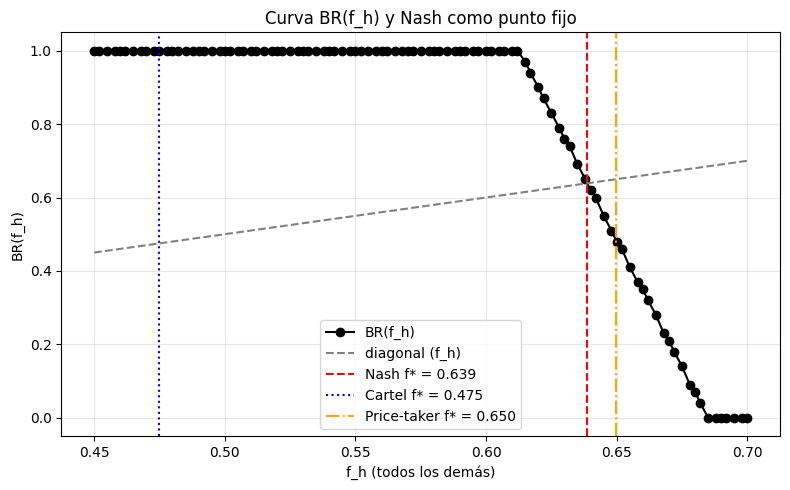

In [8]:
# Nash homogéneo via BR fixed-point
optimo_nash = compute_nash_homogeneo_BR(
    params=PARAMS_INTERIOR,
    f_h_grid=np.round(np.linspace(0.45, 0.7, 101), 3),
    f_i_grid=np.linspace(0.0, 1.0, 101),
    seed=0, days=150, last=50,
)

print('=== Nash homogéneo via BR fixed-point ===')
print(f"  f_nash       = {optimo_nash['f_star']:.4f}")
print(f"  profit_nash  = {optimo_nash['profit_star']:.2f}")
print(f"  ratio_nash   = {optimo_nash['ratio_star']:.3f}")
print(f"  corner       = {optimo_nash['corner']}")

print('\nComparación con cartel y price-taker:')
print(f"  Cartel       f = {optimo_homogeneo['cooperativo']['f_star']:.4f}  (analítico: "
      f"{optimo_unico['f_star']:.4f})" if 'optimo_unico' in dir() else '')
print(f"  Nash real    f = {optimo_nash['f_star']:.4f}")
print(f"  Price-taker  f = {optimo_homogeneo['price_taker_approx']['f_star']:.4f}  (aprox N→∞)")
print(f"  Gap Nash - PT  = {optimo_nash['f_star'] - optimo_homogeneo['price_taker_approx']['f_star']:+.4f}")

# Plot curva BR(f_h) y diagonal
fig, ax = plt.subplots(figsize=(8, 5))
c = optimo_nash['curva_BR']
ax.plot(c['f_h'], c['BR'], 'o-', color='black', label='BR(f_h)')
ax.plot(c['f_h'], c['f_h'], '--', color='gray', label='diagonal (f_h)')
ax.axvline(optimo_nash['f_star'], color='red', linestyle='--',
           label=f"Nash f* = {optimo_nash['f_star']:.3f}")
ax.axvline(optimo_homogeneo['cooperativo']['f_star'], color='blue', linestyle=':',
           label=f"Cartel f* = {optimo_homogeneo['cooperativo']['f_star']:.3f}")
ax.axvline(optimo_homogeneo['price_taker_approx']['f_star'], color='orange', linestyle='-.',
           label=f"Price-taker f* = {optimo_homogeneo['price_taker_approx']['f_star']:.3f}")
ax.set_xlabel('f_h (todos los demás)'); ax.set_ylabel('BR(f_h)')
ax.set_title('Curva BR(f_h) y Nash como punto fijo')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()


In [9]:
optimo_nash['curva_BR']

,f_h,BR,gap,profit_at_BR
0,0.450,1.0,0.550,330.145513
1,0.452,1.0,0.548,329.625899
2,0.455,1.0,0.545,328.846833
3,0.458,1.0,0.542,328.068192
4,0.460,1.0,0.540,327.549335
...,...,...,...,...
96,0.690,0.0,-0.690,284.507432
97,0.692,0.0,-0.692,284.757342
98,0.695,0.0,-0.695,285.132708
99,0.698,0.0,-0.698,285.508674


#### §2.2.1 Diagnóstico: el paisaje plano cerca del Nash

Una observación clave: cuando `f_h` está cerca de la condición de indiferencia (`ratio ≈ η`), la curva `profit_i(f_i)` es muy plana (variación de ~1% sobre todo el rango `f_i ∈ [0, 1]`). Esto significa que el **argmax** (BR) puede caer lejos de `f_h` aunque `f_h` sea casi Nash. La distancia entre `f_h` y `BR(f_h)` NO mide qué tan lejos estamos del Nash — el Nash es el punto fijo de la BR, no la BR de un `f_h` cualquiera.


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Paisaje profit_i(f_i) con todos los demás en f_h = 0.650:
  Variación total      : 3.466
  Como % del nivel     : 1.23%
  argmax (BR)          : f_i = 0.500
  profit en f_i = f_h  : 281.591
  profit en BR         : 281.932
  Diferencia max - eq  : 0.341


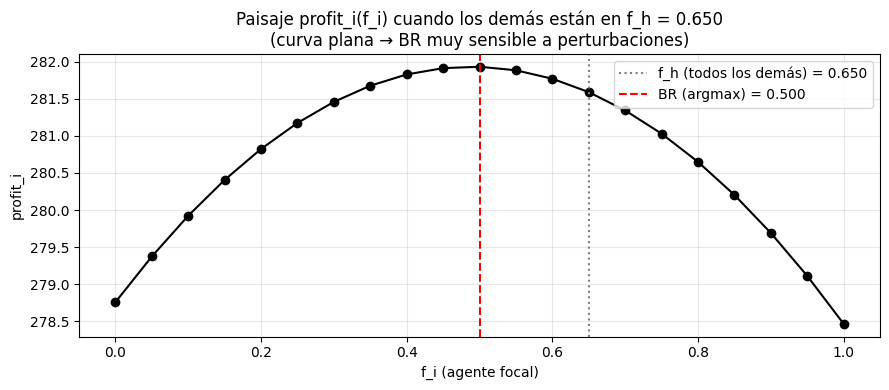

In [10]:
# Paisaje profit_i(f_i) anclado en el price-taker (donde ratio=η). Curva muy plana.
f_h_test = optimo_homogeneo['price_taker_approx']['f_star']
template = MarketModel(params=PARAMS_INTERIOR, seed=0)
agent_ids = sorted(a.unique_id for a in template.agents)
target = agent_ids[0]

f_i_grid = np.linspace(0.0, 1.0, 21)
profits = []
for f_i in f_i_grid:
    f_assign = {aid: float(f_h_test) for aid in agent_ids}
    f_assign[target] = float(f_i)
    _, _, df_a = run_with_forced_f_heterogeneo(f_assign, params=PARAMS_INTERIOR, seed=0, days=150)
    tail = df_a[(df_a['agent_id'] == target) & (df_a['day'] >= 100)]
    profits.append(tail['agent_profit'].mean())
profits = np.array(profits)

rng = profits.max() - profits.min()
print(f'Paisaje profit_i(f_i) con todos los demás en f_h = {f_h_test:.3f}:')
print(f'  Variación total      : {rng:.3f}')
print(f'  Como % del nivel     : {rng / profits.max() * 100:.2f}%')
print(f'  argmax (BR)          : f_i = {f_i_grid[profits.argmax()]:.3f}')
print(f'  profit en f_i = f_h  : {np.interp(f_h_test, f_i_grid, profits):.3f}')
print(f'  profit en BR         : {profits.max():.3f}')
print(f'  Diferencia max - eq  : {profits.max() - np.interp(f_h_test, f_i_grid, profits):.3f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f_i_grid, profits, 'o-', color='black')
ax.axvline(f_h_test, color='gray', linestyle=':',
           label=f'f_h (todos los demás) = {f_h_test:.3f}')
ax.axvline(f_i_grid[profits.argmax()], color='red', linestyle='--',
           label=f'BR (argmax) = {f_i_grid[profits.argmax()]:.3f}')
ax.set_xlabel('f_i (agente focal)'); ax.set_ylabel('profit_i')
ax.set_title(f'Paisaje profit_i(f_i) cuando los demás están en f_h = {f_h_test:.3f}\n'
             '(curva plana → BR muy sensible a perturbaciones)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


#### §2.2.2 Nash simétrico — CPO analítica (sección 4.6.2)

Resolución directa de la condición de primer orden derivada en la sección 4.6.2 del TFG, para un equilibrio de Nash simétrico con $n$ agentes idénticos. La función es paramétrica en $n$:

- Con $n = 2$ corresponde al caso teórico estricto de la sección 4.6.2 (dos agentes simétricos).
- Con $n = N$ (parámetro del modelo) corresponde a la generalización a $N$ agentes simétricos, comparable directamente con el cártel de §2.1.1.

CPO Nash simétrico (régimen interior, sin saturación):

$$P_M - \eta P_E = \alpha_G \gamma_G \cdot \Bigl\{ q_i^M [g^M]^{\gamma_G - 1} - \eta q_i^E [g^E]^{\gamma_G - 1} \Bigr\}$$

Diferencia clave con el cártel (§2.1.1): la cuña usa cantidades **individuales** $q_i = Q/n$, no agregadas. Por ello $f^*_{\text{cártel}} \leq f^*_{\text{Nash}}(n) \leq f^*_{\text{precio-aceptante}}$, con la cota Nash desplazándose hacia el precio-aceptante a medida que $n$ aumenta.


In [11]:
def solve_nash_simetricos(params=None, n_agentes=2):
    """Resuelve la CPO del equilibrio de Nash simétrico (sección 4.6.2).

    Para n_agentes=2 corresponde exactamente al caso del 4.6.2 estricto.
    Para n_agentes=N (parámetro del modelo) generaliza a N agentes simétricos.

    Notación (régimen interior, sin saturación):
        M_i, E_i = α_M·c, α_E·c           (producción individual)
        q_i^M = (1-f) M_i,  q_i^E = E_i + η f M_i
        Q^M = n · q_i^M,    Q^E = n · q_i^E
        g^p = D_p - Q^p,    P_p = c0 + α_G g_p^γ_G

    CPO:
        ∂π_i/∂f_i = M_i · { α_G γ_G q_i^M g^M^(γ_G-1) - P_M
                          - α_G γ_G η q_i^E g^E^(γ_G-1) + η P_E } = 0
    """
    p = {**DEFAULT_PARAMS, **(params or {})}
    c_i = (p['CAP_LOW'] + p['CAP_HIGH']) / 2.0
    M_i = p['ALPHA_M'] * c_i
    E_i = p['ALPHA_E'] * c_i
    eta = (p['ETA_LOW'] + p['ETA_HIGH']) / 2.0
    D_M, D_E = p['DEMAND_M'], p['DEMAND_E']
    c0, ag, gg = p['C0'], p['ALPHA_G'], p['GAMMA_G']
    s_i = (p['STOR_CAP_LOW'] + p['STOR_CAP_HIGH']) / 2.0
    f_sat = s_i / (eta * M_i) if eta * M_i > 0 else float('inf')

    def pi_i(f):
        qM_i = (1 - f) * M_i
        S_i = min(s_i, eta * f * M_i)
        qE_i = E_i + S_i
        QM = n_agentes * qM_i
        QE = n_agentes * qE_i
        gM = max(D_M - QM, 0.0); gE = max(D_E - QE, 0.0)
        PM = c0 + ag * gM**gg if gM > 0 else 0.0
        PE = c0 + ag * gE**gg if gE > 0 else 0.0
        return PM * qM_i + PE * qE_i

    def dpi_interior(f):
        qM_i = (1 - f) * M_i
        qE_i = E_i + eta * f * M_i
        QM = n_agentes * qM_i; QE = n_agentes * qE_i
        gM = D_M - QM; gE = D_E - QE
        if gM <= 0 or gE <= 0:
            return float('nan')
        PM = c0 + ag * gM**gg; PE = c0 + ag * gE**gg
        return M_i * (
            ag * gg * qM_i * gM**(gg - 1) - PM
            - ag * gg * eta * qE_i * gE**(gg - 1) + eta * PE
        )

    f_max = min(0.999, f_sat - 1e-6) if f_sat <= 1 else 0.999
    d0 = dpi_interior(1e-3); d1 = dpi_interior(f_max)
    if not np.isfinite(d0) or not np.isfinite(d1):
        f_star, regimen = float('nan'), 'fuera_interior'
    elif d0 <= 0:
        f_star, regimen = 0.0, 'esquina_inferior'
    elif d1 >= 0:
        f_star = min(1.0, f_sat)
        regimen = 'saturacion' if f_sat <= 1 else 'esquina_superior'
    else:
        f_star = brentq(dpi_interior, 1e-3, f_max, xtol=1e-8)
        regimen = 'interior'

    if np.isfinite(f_star):
        qM_i = (1 - f_star) * M_i
        S_i_eff = min(s_i, eta * f_star * M_i)
        qE_i = E_i + S_i_eff
        QM = n_agentes * qM_i; QE = n_agentes * qE_i
        gM = max(D_M - QM, 0.0); gE = max(D_E - QE, 0.0)
        PM = c0 + ag * gM**gg if gM > 0 else 0.0
        PE = c0 + ag * gE**gg if gE > 0 else 0.0
    else:
        PM = PE = float('nan')

    return {
        'f_star': f_star,
        'pi_i_star': pi_i(f_star) if np.isfinite(f_star) else float('nan'),
        'PM_star': PM, 'PE_star': PE,
        'ratio_star': PM / PE if PE > 0 else float('inf'),
        'regimen': regimen,
        'n_agentes': n_agentes,
        'M_i': M_i, 'E_i': E_i, 'eta': eta, 'f_sat': f_sat,
        '_pi_i': pi_i, '_dpi': dpi_interior,
    }




##### §2.2.2.a Caso N=2 — capacidades individuales escaladas

Para que la comparación de Nash N=2 con la simulación del modelo sea conceptualmente coherente, conviene mantener constante la **oferta agregada** y solo variar el número de agentes entre los que se reparte. Con los parámetros del modelo (`N=30`, `c=2,5`) la capacidad agregada es `30 · 2,5 = 75`. Reproducir la misma oferta agregada con dos agentes exige `c_i = 37,5` para cada uno (y batería `s_i = 150` para mantener resultados sin saturación).

Bajo esta parametrización el caso N=2 deja de ser degenerado y permite contrastar las cuatro referencias homogéneas: cártel (CPO + grid), Nash (CPO + BR fixed-point) y precio-aceptante.


=== Caso N=2 (capacidades escaladas, oferta agregada idéntica a N=30) ===
  Cártel (CPO 4.6.1)         : f* = 0.4753, PM/PE = 0.628
  Cártel (grid search)       : f* = 0.4750, PM/PE = 0.627
  Nash (CPO 4.6.2)           : f* = 0.5370, PM/PE = 0.714    (régimen: interior)
  Nash (BR fixed-point)      : f* = 0.5352, PM/PE = 0.711
  Precio-aceptante (ratio=η) : f* = 0.6504, PM/PE = 0.900


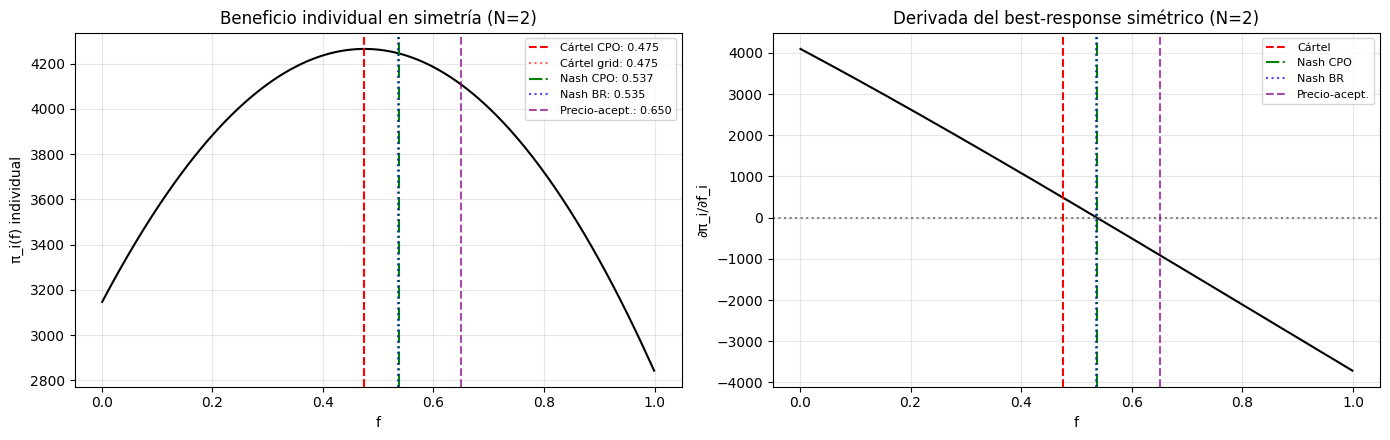

In [12]:
# Caso N=2: capacidades individuales escaladas para mantener oferta agregada (75)
PARAMS_INTERIOR_N2 = {
    **PARAMS_INTERIOR,
    'N': 2,
    'CAP_LOW': 37.5, 'CAP_HIGH': 37.5,
    'STOR_CAP_LOW': 150.0, 'STOR_CAP_HIGH': 150.0,
}

# Referencias analíticas (CPO)
cartel_cpo_n2 = solve_unico_cpo(PARAMS_INTERIOR_N2) # para cartel con N=2 (sección 4.6.1) -- idéntico al caso único porque la oferta agregada es la misma
nash_cpo_n2   = solve_nash_simetricos(PARAMS_INTERIOR_N2, n_agentes=2)

# Cross-check vía simulación (grid search del cártel + BR fixed-point del Nash)
cartel_grid_n2 = compute_cartel_grid(PARAMS_INTERIOR_N2, grid=201, seeds=range(1), days=200, last=100) # para cártel con N=2, igual a N=30 por oferta agregada idéntica
nash_br_n2 = compute_nash_homogeneo_BR(
    PARAMS_INTERIOR_N2,
    f_h_grid=np.round(np.linspace(0.4, 0.85, 12), 3),
    f_i_grid=np.linspace(0.0, 1.0, 21),
    seed=0, days=150, last=50,
)
pt_n2 = cartel_grid_n2['price_taker_approx']

print('=== Caso N=2 (capacidades escaladas, oferta agregada idéntica a N=30) ===')
print(f"  Cártel (CPO 4.6.1)         : f* = {cartel_cpo_n2['f_star']:.4f}, PM/PE = {cartel_cpo_n2['ratio_star']:.3f}")
print(f"  Cártel (grid search)       : f* = {cartel_grid_n2['cooperativo']['f_star']:.4f}, PM/PE = {cartel_grid_n2['cooperativo']['ratio_star']:.3f}")
print(f"  Nash (CPO 4.6.2)           : f* = {nash_cpo_n2['f_star']:.4f}, PM/PE = {nash_cpo_n2['ratio_star']:.3f}    (régimen: {nash_cpo_n2['regimen']})")
print(f"  Nash (BR fixed-point)      : f* = {nash_br_n2['f_star']:.4f}, PM/PE = {nash_br_n2['ratio_star']:.3f}")
print(f"  Precio-aceptante (ratio=η) : f* = {pt_n2['f_star']:.4f}, PM/PE = {pt_n2['ratio_star']:.3f}")

# Plot: π_i(f) y dπ_i/df_i para N=2
f_upper = min(0.999, nash_cpo_n2['f_sat'] - 1e-3) if nash_cpo_n2['f_sat'] <= 1 else 0.999
fs = np.linspace(0.001, f_upper, 300)
pis_n  = np.array([nash_cpo_n2['_pi_i'](f) for f in fs])
dpis_n = np.array([nash_cpo_n2['_dpi'](f)  for f in fs])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(fs, pis_n, color='black')
ax1.axvline(cartel_cpo_n2['f_star'], color='red',    linestyle='--',
            label=f"Cártel CPO: {cartel_cpo_n2['f_star']:.3f}")
ax1.axvline(cartel_grid_n2['cooperativo']['f_star'], color='red', linestyle=':', alpha=0.6,
            label=f"Cártel grid: {cartel_grid_n2['cooperativo']['f_star']:.3f}")
if np.isfinite(nash_cpo_n2['f_star']):
    ax1.axvline(nash_cpo_n2['f_star'], color='green',  linestyle='-.',
                label=f"Nash CPO: {nash_cpo_n2['f_star']:.3f}")
ax1.axvline(nash_br_n2['f_star'], color='blue',   linestyle=':', alpha=0.7,
            label=f"Nash BR: {nash_br_n2['f_star']:.3f}")
ax1.axvline(pt_n2['f_star'], color='purple', linestyle='--', alpha=0.7,
            label=f"Precio-acept.: {pt_n2['f_star']:.3f}")
ax1.set_xlabel('f'); ax1.set_ylabel('π_i(f) individual')
ax1.set_title('Beneficio individual en simetría (N=2)')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.plot(fs, dpis_n, color='black')
ax2.axhline(0, color='gray', linestyle=':')
ax2.axvline(cartel_cpo_n2['f_star'], color='red', linestyle='--', label='Cártel')
if np.isfinite(nash_cpo_n2['f_star']):
    ax2.axvline(nash_cpo_n2['f_star'], color='green', linestyle='-.', label='Nash CPO')
ax2.axvline(nash_br_n2['f_star'], color='blue', linestyle=':', alpha=0.7, label='Nash BR')
ax2.axvline(pt_n2['f_star'], color='purple', linestyle='--', alpha=0.7, label='Precio-acept.')
ax2.set_xlabel('f'); ax2.set_ylabel('∂π_i/∂f_i')
ax2.set_title('Derivada del best-response simétrico (N=2)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


=== Nash homogéneo via BR fixed-point ===
  f_nash       = 0.5367
  profit_nash  = 4230.87
  ratio_nash   = 0.713
  corner       = None

Comparación con cartel y price-taker:
  Cartel       f = 0.4750  (analítico: 0.4753)
  Nash real    f = 0.5367
  Price-taker  f = 0.6497  (aprox N→∞)
  Gap Nash - PT  = -0.1130


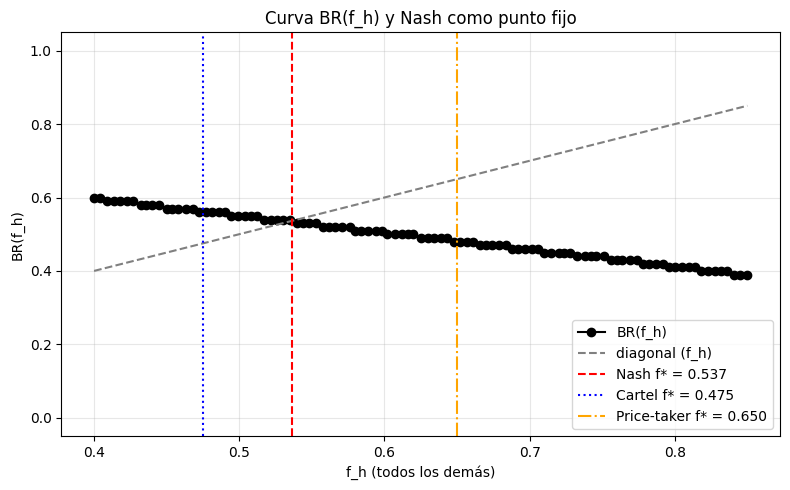

In [13]:
# Nash homogéneo via BR fixed-point
optimo_nash_n2 = compute_nash_homogeneo_BR(
    params=PARAMS_INTERIOR_N2,
    f_h_grid=np.round(np.linspace(0.4, 0.85, 101), 3),
    f_i_grid=np.linspace(0.0, 1.0, 101),
    seed=0, days=150, last=50,
)

print('=== Nash homogéneo via BR fixed-point ===')
print(f"  f_nash       = {optimo_nash_n2['f_star']:.4f}")
print(f"  profit_nash  = {optimo_nash_n2['profit_star']:.2f}")
print(f"  ratio_nash   = {optimo_nash_n2['ratio_star']:.3f}")
print(f"  corner       = {optimo_nash_n2['corner']}")

print('\nComparación con cartel y price-taker:')
print(f"  Cartel       f = {optimo_homogeneo['cooperativo']['f_star']:.4f}  (analítico: "
      f"{optimo_unico['f_star']:.4f})" if 'optimo_unico' in dir() else '')
print(f"  Nash real    f = {optimo_nash_n2['f_star']:.4f}")
print(f"  Price-taker  f = {optimo_homogeneo['price_taker_approx']['f_star']:.4f}  (aprox N→∞)")
print(f"  Gap Nash - PT  = {optimo_nash_n2['f_star'] - optimo_homogeneo['price_taker_approx']['f_star']:+.4f}")

# Plot curva BR(f_h) y diagonal
fig, ax = plt.subplots(figsize=(8, 5))
c = optimo_nash_n2['curva_BR']
ax.plot(c['f_h'], c['BR'], 'o-', color='black', label='BR(f_h)')
ax.plot(c['f_h'], c['f_h'], '--', color='gray', label='diagonal (f_h)')
ax.axvline(optimo_nash_n2['f_star'], color='red', linestyle='--',
           label=f"Nash f* = {optimo_nash_n2['f_star']:.3f}")
ax.axvline(optimo_homogeneo['cooperativo']['f_star'], color='blue', linestyle=':',
           label=f"Cartel f* = {optimo_homogeneo['cooperativo']['f_star']:.3f}")
ax.axvline(optimo_homogeneo['price_taker_approx']['f_star'], color='orange', linestyle='-.',
           label=f"Price-taker f* = {optimo_homogeneo['price_taker_approx']['f_star']:.3f}")
ax.set_xlabel('f_h (todos los demás)'); ax.set_ylabel('BR(f_h)')
ax.set_title('Curva BR(f_h) y Nash como punto fijo')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()

##### §2.2.2.b Caso N=30 — parámetros del modelo

Con los parámetros originales del modelo (`N=30`, `c=2,5`), reusa todas las referencias homogéneas ya calculadas arriba (`optimo_unico`, `optimo_homogeneo`, `optimo_nash`) y añade el Nash analítico generalizado a N=30 vía `solve_nash_simetricos`. La cuña de poder de mercado se diluye por el factor `1/N`, por lo que el Nash debería caer cerca del precio-aceptante (`ratio = η`) y muy lejos del cártel.


=== Caso N=30 (parámetros del modelo) ===
  Cártel (CPO 4.6.1)         : f* = 0.4753, PM/PE = 0.628
  Cártel (grid search)       : f* = 0.4750, PM/PE = 0.627
  Nash (CPO generalizada)    : f* = 0.6393, PM/PE = 0.881    (régimen: interior)
  Nash (BR fixed-point)      : f* = 0.6387, PM/PE = 0.880
  Precio-aceptante (ratio=η) : f* = 0.6497, PM/PE = 0.900


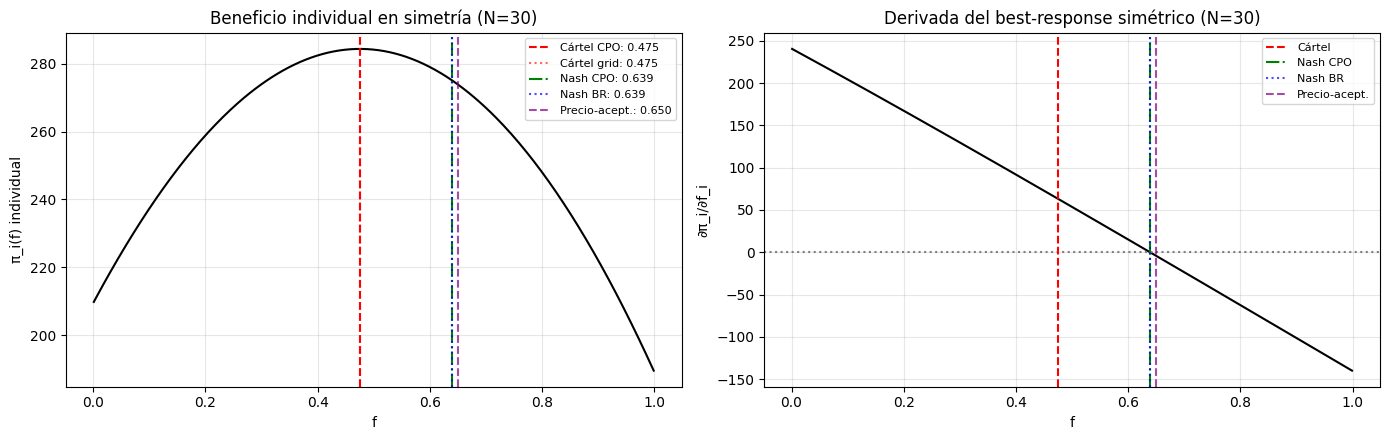

In [14]:
# Caso N=30: parámetros del modelo. Reusa las referencias ya calculadas:
#   optimo_unico        (cártel CPO §2.1.1)
#   optimo_homogeneo    (cártel grid + price_taker §2.1.2)
#   optimo_nash         (Nash BR fixed-point §2.2)
optimo_nash = compute_nash_homogeneo_BR(
    params=PARAMS_INTERIOR,
    f_h_grid=np.round(np.linspace(0.4, 0.85, 100), 3),
    f_i_grid=np.linspace(0.0, 1.0, 100),
    seed=0, days=150, last=50,
)

nash_cpo_n30 = solve_nash_simetricos(PARAMS_INTERIOR, n_agentes=PARAMS_INTERIOR['N'])
pt_n30 = optimo_homogeneo['price_taker_approx']

print('=== Caso N=30 (parámetros del modelo) ===')
print(f"  Cártel (CPO 4.6.1)         : f* = {optimo_unico['f_star']:.4f}, PM/PE = {optimo_unico['ratio_star']:.3f}")
print(f"  Cártel (grid search)       : f* = {optimo_homogeneo['cooperativo']['f_star']:.4f}, PM/PE = {optimo_homogeneo['cooperativo']['ratio_star']:.3f}")
print(f"  Nash (CPO generalizada)    : f* = {nash_cpo_n30['f_star']:.4f}, PM/PE = {nash_cpo_n30['ratio_star']:.3f}    (régimen: {nash_cpo_n30['regimen']})")
print(f"  Nash (BR fixed-point)      : f* = {optimo_nash['f_star']:.4f}, PM/PE = {optimo_nash['ratio_star']:.3f}")
print(f"  Precio-aceptante (ratio=η) : f* = {pt_n30['f_star']:.4f}, PM/PE = {pt_n30['ratio_star']:.3f}")

# Plot: π_i(f) y dπ_i/df_i para N=30
f_upper = min(0.999, nash_cpo_n30['f_sat'] - 1e-3) if nash_cpo_n30['f_sat'] <= 1 else 0.999
fs = np.linspace(0.001, f_upper, 300)
pis_n  = np.array([nash_cpo_n30['_pi_i'](f) for f in fs])
dpis_n = np.array([nash_cpo_n30['_dpi'](f)  for f in fs])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(fs, pis_n, color='black')
ax1.axvline(optimo_unico['f_star'], color='red', linestyle='--',
            label=f"Cártel CPO: {optimo_unico['f_star']:.3f}")
ax1.axvline(optimo_homogeneo['cooperativo']['f_star'], color='red', linestyle=':', alpha=0.6,
            label=f"Cártel grid: {optimo_homogeneo['cooperativo']['f_star']:.3f}")
if np.isfinite(nash_cpo_n30['f_star']):
    ax1.axvline(nash_cpo_n30['f_star'], color='green', linestyle='-.',
                label=f"Nash CPO: {nash_cpo_n30['f_star']:.3f}")
ax1.axvline(optimo_nash['f_star'], color='blue', linestyle=':', alpha=0.7,
            label=f"Nash BR: {optimo_nash['f_star']:.3f}")
ax1.axvline(pt_n30['f_star'], color='purple', linestyle='--', alpha=0.7,
            label=f"Precio-acept.: {pt_n30['f_star']:.3f}")
ax1.set_xlabel('f'); ax1.set_ylabel('π_i(f) individual')
ax1.set_title('Beneficio individual en simetría (N=30)')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.plot(fs, dpis_n, color='black')
ax2.axhline(0, color='gray', linestyle=':')
ax2.axvline(optimo_unico['f_star'], color='red', linestyle='--', label='Cártel')
if np.isfinite(nash_cpo_n30['f_star']):
    ax2.axvline(nash_cpo_n30['f_star'], color='green', linestyle='-.', label='Nash CPO')
ax2.axvline(optimo_nash['f_star'], color='blue', linestyle=':', alpha=0.7, label='Nash BR')
ax2.axvline(pt_n30['f_star'], color='purple', linestyle='--', alpha=0.7, label='Precio-acept.')
ax2.set_xlabel('f'); ax2.set_ylabel('∂π_i/∂f_i')
ax2.set_title('Derivada del best-response simétrico (N=30)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


### Extra: Comparación Gráfica de ambas

=== Comparativa (parámetros del modelo) ===
  Cártel (CPO 4.6.1)         : f* = 0.4753, PM/PE = 0.628
  Cártel (grid search)       : f* = 0.4750, PM/PE = 0.627
  Nash N = 2 (CPO 4.6.2)           : f* = 0.5370, PM/PE = 0.714    (régimen: interior)
  Nash N = 2 (BR fixed-point)      : f* = 0.5352, PM/PE = 0.711
  Nash N = 30 (CPO generalizada)    : f* = 0.6393, PM/PE = 0.881    (régimen: interior)
  Nash N = 30 (BR fixed-point)      : f* = 0.6387, PM/PE = 0.880
  Precio-aceptante (ratio=η) : f* = 0.6497, PM/PE = 0.900


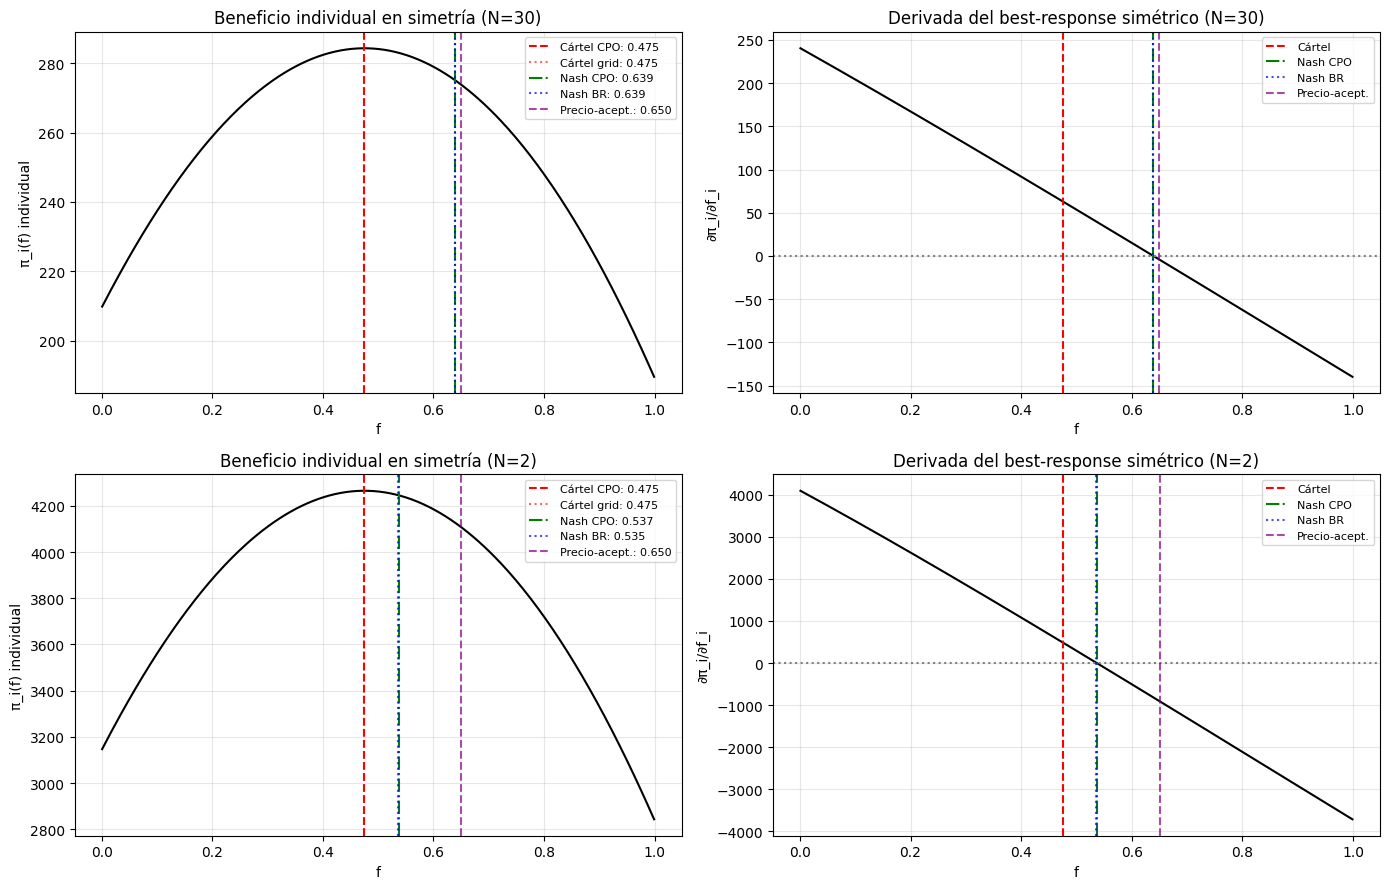

In [15]:
print('=== Comparativa (parámetros del modelo) ===')
print(f"  Cártel (CPO 4.6.1)         : f* = {optimo_unico['f_star']:.4f}, PM/PE = {optimo_unico['ratio_star']:.3f}")
print(f"  Cártel (grid search)       : f* = {optimo_homogeneo['cooperativo']['f_star']:.4f}, PM/PE = {optimo_homogeneo['cooperativo']['ratio_star']:.3f}")
print(f"  Nash N = 2 (CPO 4.6.2)           : f* = {nash_cpo_n2['f_star']:.4f}, PM/PE = {nash_cpo_n2['ratio_star']:.3f}    (régimen: {nash_cpo_n2['regimen']})")
print(f"  Nash N = 2 (BR fixed-point)      : f* = {nash_br_n2['f_star']:.4f}, PM/PE = {nash_br_n2['ratio_star']:.3f}")
print(f"  Nash N = 30 (CPO generalizada)    : f* = {nash_cpo_n30['f_star']:.4f}, PM/PE = {nash_cpo_n30['ratio_star']:.3f}    (régimen: {nash_cpo_n30['regimen']})")
print(f"  Nash N = 30 (BR fixed-point)      : f* = {optimo_nash['f_star']:.4f}, PM/PE = {optimo_nash['ratio_star']:.3f}")
print(f"  Precio-aceptante (ratio=η) : f* = {pt_n30['f_star']:.4f}, PM/PE = {pt_n30['ratio_star']:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
(ax1, ax2), (ax3, ax4) = axes

# ── N=30 ──────────────────────────────────────────────────────────────────────
f_upper_30 = min(0.999, nash_cpo_n30['f_sat'] - 1e-3) if nash_cpo_n30['f_sat'] <= 1 else 0.999
fs_30 = np.linspace(0.001, f_upper_30, 300)
pis_n30  = np.array([nash_cpo_n30['_pi_i'](f) for f in fs_30])
dpis_n30 = np.array([nash_cpo_n30['_dpi'](f)  for f in fs_30])

ax1.plot(fs_30, pis_n30, color='black')
ax1.axvline(optimo_unico['f_star'],                          color='red',    linestyle='--',        label=f"Cártel CPO: {optimo_unico['f_star']:.3f}")
ax1.axvline(optimo_homogeneo['cooperativo']['f_star'],       color='red',    linestyle=':',  alpha=0.6, label=f"Cártel grid: {optimo_homogeneo['cooperativo']['f_star']:.3f}")
if np.isfinite(nash_cpo_n30['f_star']):
    ax1.axvline(nash_cpo_n30['f_star'],                      color='green',  linestyle='-.',        label=f"Nash CPO: {nash_cpo_n30['f_star']:.3f}")
ax1.axvline(optimo_nash['f_star'],                           color='blue',   linestyle=':',  alpha=0.7, label=f"Nash BR: {optimo_nash['f_star']:.3f}")
ax1.axvline(pt_n30['f_star'],                                color='purple', linestyle='--', alpha=0.7, label=f"Precio-acept.: {pt_n30['f_star']:.3f}")
ax1.set_xlabel('f'); ax1.set_ylabel('π_i(f) individual')
ax1.set_title('Beneficio individual en simetría (N=30)')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.plot(fs_30, dpis_n30, color='black')
ax2.axhline(0, color='gray', linestyle=':')
ax2.axvline(optimo_unico['f_star'],                          color='red',    linestyle='--',        label='Cártel')
if np.isfinite(nash_cpo_n30['f_star']):
    ax2.axvline(nash_cpo_n30['f_star'],                      color='green',  linestyle='-.',        label='Nash CPO')
ax2.axvline(optimo_nash['f_star'],                           color='blue',   linestyle=':',  alpha=0.7, label='Nash BR')
ax2.axvline(pt_n30['f_star'],                                color='purple', linestyle='--', alpha=0.7, label='Precio-acept.')
ax2.set_xlabel('f'); ax2.set_ylabel('∂π_i/∂f_i')
ax2.set_title('Derivada del best-response simétrico (N=30)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── N=2 ───────────────────────────────────────────────────────────────────────
f_upper_2 = min(0.999, nash_cpo_n2['f_sat'] - 1e-3) if nash_cpo_n2['f_sat'] <= 1 else 0.999
fs_2 = np.linspace(0.001, f_upper_2, 300)
pis_n2  = np.array([nash_cpo_n2['_pi_i'](f) for f in fs_2])
dpis_n2 = np.array([nash_cpo_n2['_dpi'](f)  for f in fs_2])

ax3.plot(fs_2, pis_n2, color='black')
ax3.axvline(cartel_cpo_n2['f_star'],                         color='red',    linestyle='--',        label=f"Cártel CPO: {cartel_cpo_n2['f_star']:.3f}")
ax3.axvline(cartel_grid_n2['cooperativo']['f_star'],         color='red',    linestyle=':',  alpha=0.6, label=f"Cártel grid: {cartel_grid_n2['cooperativo']['f_star']:.3f}")
if np.isfinite(nash_cpo_n2['f_star']):
    ax3.axvline(nash_cpo_n2['f_star'],                       color='green',  linestyle='-.',        label=f"Nash CPO: {nash_cpo_n2['f_star']:.3f}")
ax3.axvline(nash_br_n2['f_star'],                            color='blue',   linestyle=':',  alpha=0.7, label=f"Nash BR: {nash_br_n2['f_star']:.3f}")
ax3.axvline(pt_n2['f_star'],                                 color='purple', linestyle='--', alpha=0.7, label=f"Precio-acept.: {pt_n2['f_star']:.3f}")
ax3.set_xlabel('f'); ax3.set_ylabel('π_i(f) individual')
ax3.set_title('Beneficio individual en simetría (N=2)')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

ax4.plot(fs_2, dpis_n2, color='black')
ax4.axhline(0, color='gray', linestyle=':')
ax4.axvline(cartel_cpo_n2['f_star'],                         color='red',    linestyle='--',        label='Cártel')
if np.isfinite(nash_cpo_n2['f_star']):
    ax4.axvline(nash_cpo_n2['f_star'],                       color='green',  linestyle='-.',        label='Nash CPO')
ax4.axvline(nash_br_n2['f_star'],                            color='blue',   linestyle=':',  alpha=0.7, label='Nash BR')
ax4.axvline(pt_n2['f_star'],                                 color='purple', linestyle='--', alpha=0.7, label='Precio-acept.')
ax4.set_xlabel('f'); ax4.set_ylabel('∂π_i/∂f_i')
ax4.set_title('Derivada del best-response simétrico (N=2)')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== Comparativa (parámetros del modelo) ===
  Cártel (CPO 4.6.1)         : f* = 0.4753, PM/PE = 0.628
  Cártel (grid search)       : f* = 0.4750, PM/PE = 0.627
  Nash N = 2 (CPO 4.6.2)           : f* = 0.5370, PM/PE = 0.714    (régimen: interior)
  Nash N = 2 (BR fixed-point)      : f* = 0.5352, PM/PE = 0.711
  Nash N = 30 (CPO generalizada)    : f* = 0.6393, PM/PE = 0.881    (régimen: interior)
  Nash N = 30 (BR fixed-point)      : f* = 0.6387, PM/PE = 0.880
  Precio-aceptante (ratio=η) : f* = 0.6497, PM/PE = 0.900


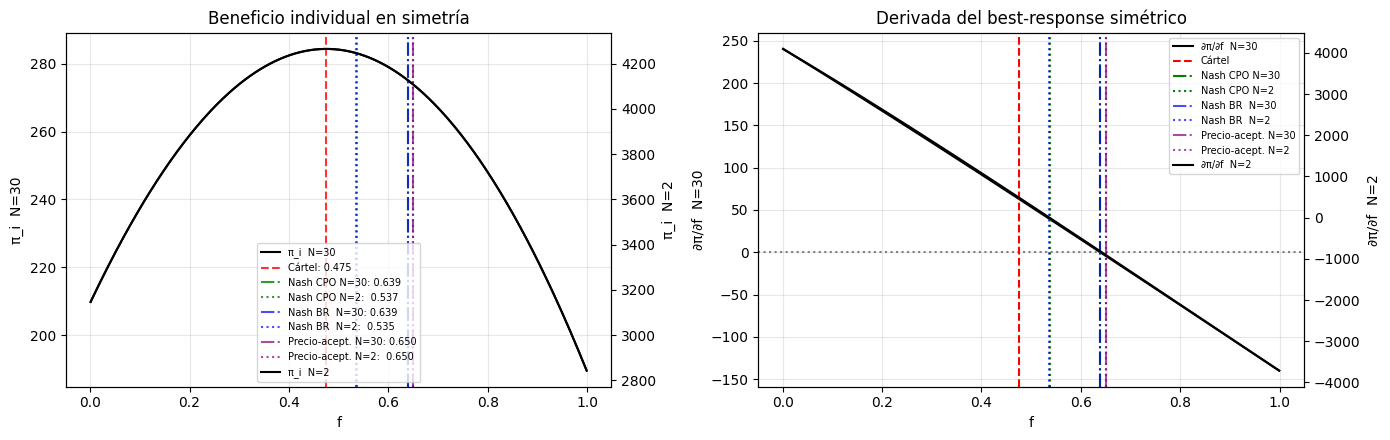

In [16]:
print('=== Comparativa (parámetros del modelo) ===')
print(f"  Cártel (CPO 4.6.1)         : f* = {optimo_unico['f_star']:.4f}, PM/PE = {optimo_unico['ratio_star']:.3f}")
print(f"  Cártel (grid search)       : f* = {optimo_homogeneo['cooperativo']['f_star']:.4f}, PM/PE = {optimo_homogeneo['cooperativo']['ratio_star']:.3f}")
print(f"  Nash N = 2 (CPO 4.6.2)           : f* = {nash_cpo_n2['f_star']:.4f}, PM/PE = {nash_cpo_n2['ratio_star']:.3f}    (régimen: {nash_cpo_n2['regimen']})")
print(f"  Nash N = 2 (BR fixed-point)      : f* = {nash_br_n2['f_star']:.4f}, PM/PE = {nash_br_n2['ratio_star']:.3f}")
print(f"  Nash N = 30 (CPO generalizada)    : f* = {nash_cpo_n30['f_star']:.4f}, PM/PE = {nash_cpo_n30['ratio_star']:.3f}    (régimen: {nash_cpo_n30['regimen']})")
print(f"  Nash N = 30 (BR fixed-point)      : f* = {optimo_nash['f_star']:.4f}, PM/PE = {optimo_nash['ratio_star']:.3f}")
print(f"  Precio-aceptante (ratio=η) : f* = {pt_n30['f_star']:.4f}, PM/PE = {pt_n30['ratio_star']:.3f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# ── Rangos de f ───────────────────────────────────────────────────────────────
f_upper_30 = min(0.999, nash_cpo_n30['f_sat'] - 1e-3) if nash_cpo_n30['f_sat'] <= 1 else 0.999
f_upper_2  = min(0.999, nash_cpo_n2['f_sat']  - 1e-3) if nash_cpo_n2['f_sat']  <= 1 else 0.999

fs_30 = np.linspace(0.001, f_upper_30, 300)
fs_2  = np.linspace(0.001, f_upper_2,  300)

pis_n30  = np.array([nash_cpo_n30['_pi_i'](f) for f in fs_30])
dpis_n30 = np.array([nash_cpo_n30['_dpi'](f)  for f in fs_30])
pis_n2   = np.array([nash_cpo_n2['_pi_i'](f)  for f in fs_2])
dpis_n2  = np.array([nash_cpo_n2['_dpi'](f)   for f in fs_2])

# ── Ax1: beneficio individual ─────────────────────────────────────────────────
ax1b = ax1.twinx()

ax1.plot(fs_30,  pis_n30, color='black', linestyle='-',  label='π_i  N=30')
ax1b.plot(fs_2,  pis_n2,  color='black', linestyle='-', label='π_i  N=2')

# Líneas verticales (solo en ax1, se ven en ambos)
ax1.axvline(optimo_unico['f_star'],                    color='red',    linestyle='--', alpha=0.8, label=f"Cártel: {optimo_unico['f_star']:.3f}")
if np.isfinite(nash_cpo_n30['f_star']):
    ax1.axvline(nash_cpo_n30['f_star'],                color='green',  linestyle='-.', alpha=0.8, label=f"Nash CPO N=30: {nash_cpo_n30['f_star']:.3f}")
if np.isfinite(nash_cpo_n2['f_star']):
    ax1.axvline(nash_cpo_n2['f_star'],                 color='green',  linestyle=':',  alpha=0.8, label=f"Nash CPO N=2:  {nash_cpo_n2['f_star']:.3f}")
ax1.axvline(optimo_nash['f_star'],                     color='blue',   linestyle='-.', alpha=0.7, label=f"Nash BR  N=30: {optimo_nash['f_star']:.3f}")
ax1.axvline(nash_br_n2['f_star'],                      color='blue',   linestyle=':',  alpha=0.7, label=f"Nash BR  N=2:  {nash_br_n2['f_star']:.3f}")
ax1.axvline(pt_n30['f_star'],                          color='purple', linestyle='-.', alpha=0.7, label=f"Precio-acept. N=30: {pt_n30['f_star']:.3f}")
ax1.axvline(pt_n2['f_star'],                           color='purple', linestyle=':',  alpha=0.7, label=f"Precio-acept. N=2:  {pt_n2['f_star']:.3f}")

ax1.set_xlabel('f')
ax1.set_ylabel('π_i  N=30', color='black');  ax1.tick_params(axis='y', labelcolor='black')
ax1b.set_ylabel('π_i  N=2',  color='black'); ax1b.tick_params(axis='y', labelcolor='black')
ax1.set_title('Beneficio individual en simetría')
ax1.grid(alpha=0.3)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

# ── Ax2: derivada ─────────────────────────────────────────────────────────────
ax2b = ax2.twinx()

ax2.plot(fs_30,  dpis_n30, color='black',  linestyle='-',  label='∂π/∂f  N=30')
ax2b.plot(fs_2,  dpis_n2,  color='black', linestyle='-',  label='∂π/∂f  N=2')
ax2.axhline(0, color='gray', linestyle=':')

ax2.axvline(optimo_unico['f_star'],                    color='red',    linestyle='--',        label='Cártel')
if np.isfinite(nash_cpo_n30['f_star']):
    ax2.axvline(nash_cpo_n30['f_star'],                color='green',  linestyle='-.',        label='Nash CPO N=30')
if np.isfinite(nash_cpo_n2['f_star']):
    ax2.axvline(nash_cpo_n2['f_star'],                 color='green',  linestyle=':',         label='Nash CPO N=2')
ax2.axvline(optimo_nash['f_star'],                     color='blue',   linestyle='-.',alpha=0.7, label='Nash BR  N=30')
ax2.axvline(nash_br_n2['f_star'],                      color='blue',   linestyle=':',  alpha=0.7, label='Nash BR  N=2')
ax2.axvline(pt_n30['f_star'],                          color='purple', linestyle='-.', alpha=0.7, label='Precio-acept. N=30')
ax2.axvline(pt_n2['f_star'],                           color='purple', linestyle=':',  alpha=0.7, label='Precio-acept. N=2')

ax2.set_xlabel('f')
ax2.set_ylabel('∂π/∂f  N=30', color='black');  ax2.tick_params(axis='y', labelcolor='black')
ax2b.set_ylabel('∂π/∂f  N=2',  color='black'); ax2b.tick_params(axis='y', labelcolor='black')
ax2.set_title('Derivada del best-response simétrico')
ax2.grid(alpha=0.3)

lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2b.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, fontsize=7)

plt.tight_layout()
plt.show()

### §2.3 Best-response per-agente como diagnóstico

Para cada agente i: grid search sobre `f_i` con los demás fijos en `f_nash` (calculado en §2.2). Si Nash es punto fijo y los agentes son homogéneos, los `f_i*` deberían quedar todos cerca de `f_nash`. Si los `f_i*` se desvían sistemáticamente, indica heterogeneidad genuina (p.ej. `storage_capacity` distinto cambia la BR individual).

**Comparación útil:** si pasas `f_homogeneo=optimo_homogeneo['cooperativo']['f_star']`, los BR saldrán por encima — es la "tentación a defectar" del juego cartel (cada agente quiere almacenar más que el cartel). Es la prueba conceptual de por qué cartel ≠ Nash.


In [17]:
def compute_optimal_f_per_agente(params=None, f_homogeneo=None, grid=11, seed=0, days=150, last=50):
    """Best-response de cada agente fijando a los demás en f_homogeneo."""
    if f_homogeneo is None:
        raise ValueError('Pasa f_homogeneo (p.ej. optimo_nash["f_star"]).')
    template = MarketModel(params=params, seed=seed)
    agent_ids = sorted(a.unique_id for a in template.agents)
    ficha = {a.unique_id: {
        'capacity': a.capacity,
        'storage_capacity': a.storage_capacity,
        'eta': a.eta,
    } for a in template.agents}
    fs = np.linspace(0, 1, grid)
    rows = []
    for i in agent_ids:
        for f_i in fs:
            f_assign = {aid: f_homogeneo for aid in agent_ids}
            f_assign[i] = float(f_i)
            _, _, df_a = run_with_forced_f_heterogeneo(f_assign, params=params, seed=seed, days=days)
            tail_i = df_a[(df_a['agent_id'] == i) & (df_a['day'] >= days - last + 1)]
            rows.append({'agent_id': i, 'f_i': float(f_i), 'profit_i': tail_i['agent_profit'].mean()})
    det = pd.DataFrame(rows)
    best = det.loc[det.groupby('agent_id')['profit_i'].idxmax()].copy()
    best = best.rename(columns={'f_i': 'f_i_star', 'profit_i': 'profit_i_star'})
    best['capacity'] = best['agent_id'].map(lambda i: ficha[i]['capacity'])
    best['storage_capacity'] = best['agent_id'].map(lambda i: ficha[i]['storage_capacity'])
    best['eta'] = best['agent_id'].map(lambda i: ficha[i]['eta'])
    return best.reset_index(drop=True)


def compute_optimal_f_un_agente(params=None, f_homogeneo=None, agent_id=None,
                                 grid=11, seed=0, days=150, last=50):
    """Best-response de UN agente (versión rápida para casos homogéneos: por simetría todos
    los agentes tienen el mismo BR).
    """
    if f_homogeneo is None:
        raise ValueError('Pasa f_homogeneo (p.ej. optimo_nash["f_star"]).')
    template = MarketModel(params=params, seed=seed)
    agent_ids = sorted(a.unique_id for a in template.agents)
    target = agent_ids[0] if agent_id is None else agent_id
    if target not in agent_ids:
        raise ValueError(f'agent_id {target} no existe en el modelo')
    ficha = next({
        'capacity': a.capacity,
        'storage_capacity': a.storage_capacity,
        'eta': a.eta,
    } for a in template.agents if a.unique_id == target)

    fs = np.linspace(0, 1, grid)
    rows = []
    for f_i in fs:
        f_assign = {aid: f_homogeneo for aid in agent_ids}
        f_assign[target] = float(f_i)
        _, _, df_a = run_with_forced_f_heterogeneo(f_assign, params=params, seed=seed, days=days)
        tail_i = df_a[(df_a['agent_id'] == target) & (df_a['day'] >= days - last + 1)]
        rows.append({'f_i': float(f_i), 'profit_i': tail_i['agent_profit'].mean()})
    det = pd.DataFrame(rows)
    idx_best = int(det['profit_i'].idxmax())
    return {
        'agent_id': target,
        'f_i_star': float(det.loc[idx_best, 'f_i']),
        'profit_i_star': float(det.loc[idx_best, 'profit_i']),
        'capacity': ficha['capacity'],
        'storage_capacity': ficha['storage_capacity'],
        'eta': ficha['eta'],
        'detalle': det,
    }


Primeros agentes (anclados en Nash):
    agent_id  f_i_star  profit_i_star  capacity  storage_capacity  eta
0          1      0.64     283.688502       2.5              10.0  0.9
1          2      0.64     278.197891       2.5              10.0  0.9
2          3      0.64     278.960202       2.5              10.0  0.9
3          4      0.65     268.920475       2.5              10.0  0.9
4          5      0.65     274.613103       2.5              10.0  0.9
5          6      0.65     270.909374       2.5              10.0  0.9
6          7      0.65     274.417588       2.5              10.0  0.9
7          8      0.64     278.147994       2.5              10.0  0.9
8          9      0.64     275.618709       2.5              10.0  0.9
9         10      0.65     274.907151       2.5              10.0  0.9
10        11      0.65     276.689241       2.5              10.0  0.9
11        12      0.65     277.852359       2.5              10.0  0.9
12        13      0.64     279.567865   

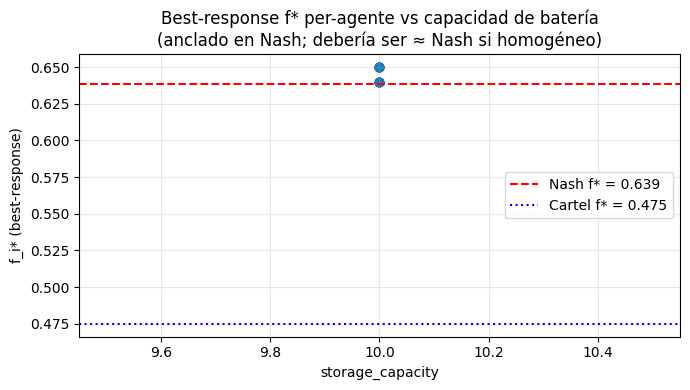

In [18]:
# Best-response per-agente, anclado en NASH (calculado en §2.2)
# OJO: pesado. 30 agentes × grid × days. Reduce grid o days si va lento
optimo_per_agente = compute_optimal_f_per_agente(
    params=PARAMS_INTERIOR,
    f_homogeneo=optimo_nash['f_star'],
    grid=101, seed=0, days=150, last=50,
)

print('Primeros agentes (anclados en Nash):')
print(optimo_per_agente.head(30))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(optimo_per_agente['storage_capacity'], optimo_per_agente['f_i_star'])
ax.axhline(optimo_nash['f_star'], color='red', linestyle='--',
           label=f"Nash f* = {optimo_nash['f_star']:.3f}")
ax.axhline(optimo_homogeneo['cooperativo']['f_star'], color='blue', linestyle=':',
           label=f"Cartel f* = {optimo_homogeneo['cooperativo']['f_star']:.3f}")
ax.set_xlabel('storage_capacity'); ax.set_ylabel('f_i* (best-response)')
ax.set_title('Best-response f* per-agente vs capacidad de batería\n'
             '(anclado en Nash; debería ser ≈ Nash si homogéneo)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Best-response de un agente representativo (anclado en Nash):
  agent_id          = 1
  f_i_star          = 0.642
  profit_i_star     = 283.689
  capacity          = 2.500
  storage_capacity  = 10.000
  eta               = 0.900


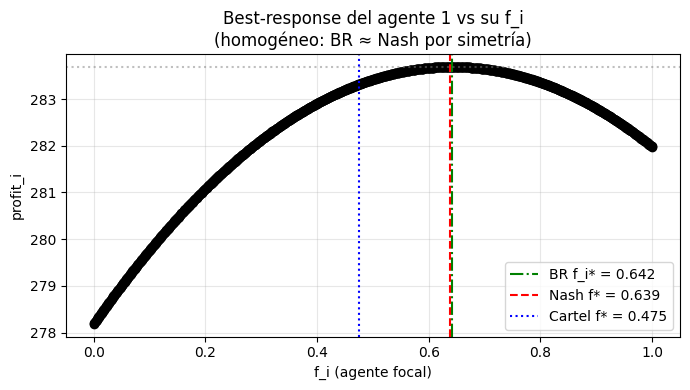

In [19]:
# Best-response de UN solo agente (rápido para casos homogéneos)
optimo_un_agente = compute_optimal_f_un_agente(
    params=PARAMS_INTERIOR,
    f_homogeneo=optimo_nash['f_star'],
    grid=1001, seed=0, days=150, last=50,
)

print('Best-response de un agente representativo (anclado en Nash):')
print(f"  agent_id          = {optimo_un_agente['agent_id']}")
print(f"  f_i_star          = {optimo_un_agente['f_i_star']:.3f}")
print(f"  profit_i_star     = {optimo_un_agente['profit_i_star']:.3f}")
print(f"  capacity          = {optimo_un_agente['capacity']:.3f}")
print(f"  storage_capacity  = {optimo_un_agente['storage_capacity']:.3f}")
print(f"  eta               = {optimo_un_agente['eta']:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
det = optimo_un_agente['detalle']
ax.plot(det['f_i'], det['profit_i'], 'o-', color='black')
ax.axvline(optimo_un_agente['f_i_star'], color='green', linestyle='-.',
           label=f"BR f_i* = {optimo_un_agente['f_i_star']:.3f}")
ax.axhline(optimo_un_agente['profit_i_star'], color='gray', linestyle=':', alpha=0.5)
ax.axvline(optimo_nash['f_star'], color='red', linestyle='--',
           label=f"Nash f* = {optimo_nash['f_star']:.3f}")
ax.axvline(optimo_homogeneo['cooperativo']['f_star'], color='blue', linestyle=':',
           label=f"Cartel f* = {optimo_homogeneo['cooperativo']['f_star']:.3f}")
ax.set_xlabel('f_i (agente focal)'); ax.set_ylabel('profit_i')
ax.set_title(f"Best-response del agente {optimo_un_agente['agent_id']} vs su f_i\n"
             '(homogéneo: BR ≈ Nash por simetría)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [20]:
optimo_nash['f_star']

0.6386924616410941

### §2.4 Nash heterogéneo — CPO analítica (Anexo B)

Resolución del equilibrio de Nash con jugadores **heterogéneos** en capacidad instalada $c_i$ y, opcionalmente, en capacidad de almacenamiento $s_i$. La derivación detallada se recoge en el Anexo B del TFG.

A diferencia del Nash simétrico (§2.2), aquí cada agente elige una fracción $f_i^*$ distinta. La ($CPO_i$) tiene la misma forma que la del caso simétrico, pero con cantidades inframarginales individuales $q_i^M, q_i^E$ proporcionales a $c_i$, mientras que los precios $P_M, P_E$ y el gas $g^M, g^E$ siguen evaluándose sobre la oferta agregada heterogénea $Q^p = \sum_i q_i^p$.

Sistema de equilibrio: $N$ ecuaciones no lineales acopladas:

$$\mathcal{R}_i(\mathbf{f}) := P_M - \eta P_E - \alpha_G \gamma_G \bigl\{q_i^M [g^M]^{\gamma_G - 1} - \eta q_i^E [g^E]^{\gamma_G - 1}\bigr\} = 0$$

Resuelto con `scipy.optimize.least_squares` partiendo del Nash simétrico de capacidad media. **Heurística esperada**: agentes con mayor $c_i$ almacenan **menos** (mayor cuña de poder de mercado individual).


In [21]:
def solve_nash_simetricos_robust(params, n_agentes):
    """Versión robusta de solve_nash_simetricos: si la CPO interior no
    cambia de signo en (0, 1), devuelve la esquina apropiada en vez de fallar."""
    p = {**DEFAULT_PARAMS, **(params or {})}
    c_i = (p['CAP_LOW'] + p['CAP_HIGH']) / 2.0
    M_i = p['ALPHA_M'] * c_i; E_i = p['ALPHA_E'] * c_i
    eta = (p['ETA_LOW'] + p['ETA_HIGH']) / 2.0
    D_M, D_E = p['DEMAND_M'], p['DEMAND_E']
    c0, ag, gg = p['C0'], p['ALPHA_G'], p['GAMMA_G']
    def dpi(f):
        qM = (1-f)*M_i; qE = E_i + eta*f*M_i
        QM = n_agentes*qM; QE = n_agentes*qE
        gM = D_M-QM; gE = D_E-QE
        if gM <= 0 or gE <= 0:
            return float('nan')
        PM = c0 + ag*gM**gg; PE = c0 + ag*gE**gg
        return M_i*(ag*gg*qM*gM**(gg-1) - PM - ag*gg*eta*qE*gE**(gg-1) + eta*PE)
    d0 = dpi(0.001); d1 = dpi(0.999)
    if not np.isfinite(d0) or not np.isfinite(d1): return 0.5
    if d0 <= 0: return 0.001
    if d1 >= 0: return 0.999
    return brentq(dpi, 0.001, 0.999, xtol=1e-8)


def solve_nash_heterogeneo(params=None, c_array=None, s_array=None, eta=None,
                            f_init=None, max_nfev=2000, xtol=1e-10):
    """Resuelve el equilibrio de Nash con jugadores heterogéneos (Anexo B).

    Parámetros:
        params: dict con parámetros del mercado (α_M, α_E, c_0, α_G, γ_G, D_M, D_E).
                Usa DEFAULT_PARAMS para los no especificados.
        c_array: array de capacidades individuales. Si None, usa N copias de la media.
        s_array: array de capacidades de batería. Si None, batería sin saturación.
        eta:     eficiencia común. Si None, usa la media de ETA_LOW, ETA_HIGH.
        f_init:  punto inicial. Si None, usa el Nash simétrico de capacidad media.

    Devuelve dict con f_array (longitud N), q_M_array, q_E_array, PM, PE,
    ratio, residual_norm, f_sat, etc.
    """
    from scipy.optimize import least_squares
    p = {**DEFAULT_PARAMS, **(params or {})}
    if c_array is None:
        c_mean = (p['CAP_LOW'] + p['CAP_HIGH']) / 2.0
        c_array = np.full(p['N'], c_mean)
    c_array = np.asarray(c_array, dtype=float)
    N = len(c_array)
    if eta is None:
        eta = (p['ETA_LOW'] + p['ETA_HIGH']) / 2.0
    M = p['ALPHA_M'] * c_array
    E = p['ALPHA_E'] * c_array
    D_M, D_E = p['DEMAND_M'], p['DEMAND_E']
    c0, ag, gg = p['C0'], p['ALPHA_G'], p['GAMMA_G']

    if s_array is None:
        f_sat = np.full(N, np.inf)
    else:
        s_array = np.asarray(s_array, dtype=float)
        f_sat = np.where(M*eta > 0, s_array/(eta*M), np.inf)
    upper = np.minimum(0.9999, np.where(f_sat <= 1, np.maximum(f_sat - 1e-6, 1e-6), 0.9999))
    lower = np.full(N, 1e-6)

    if f_init is None:
        c_mean = c_array.mean()
        f0_scalar = solve_nash_simetricos_robust(
            {**p, 'CAP_LOW': c_mean, 'CAP_HIGH': c_mean, 'N': N}, n_agentes=N)
        f0 = np.full(N, f0_scalar)
    else:
        f0 = np.asarray(f_init, dtype=float)
    f0 = np.clip(f0, lower, upper)

    def residual(f):
        qM = (1-f)*M
        if s_array is not None:
            S = np.minimum(s_array, eta*f*M)
        else:
            S = eta*f*M
        qE = E + S
        QM = qM.sum(); QE = qE.sum()
        gM = D_M - QM; gE = D_E - QE
        if gM <= 0 or gE <= 0:
            return np.full(N, 1e6)
        PM = c0 + ag*gM**gg; PE = c0 + ag*gE**gg
        return (PM - eta*PE) - ag*gg*(qM*gM**(gg-1) - eta*qE*gE**(gg-1))

    sol = least_squares(residual, f0, bounds=(lower, upper),
                        max_nfev=max_nfev, xtol=xtol)
    f = sol.x
    qM = (1-f)*M
    if s_array is not None:
        S = np.minimum(s_array, eta*f*M)
    else:
        S = eta*f*M
    qE = E + S
    QM = qM.sum(); QE = qE.sum()
    gM = max(D_M-QM, 0.0); gE = max(D_E-QE, 0.0)
    PM = c0 + ag*gM**gg if gM > 0 else 0.0
    PE = c0 + ag*gE**gg if gE > 0 else 0.0
    return {
        'f_array': f, 'qM_array': qM, 'qE_array': qE,
        'PM': PM, 'PE': PE, 'ratio': PM/PE if PE > 0 else float('inf'),
        'c_array': c_array, 's_array': s_array, 'eta': eta,
        'residual_norm': float(np.linalg.norm(sol.fun)),
        'f_sat': f_sat,
        'sol_status': int(sol.status),
    }


=== Caso A: heterogeneidad solo en c_i (Anexo B.1) ===
  Residual: 6.60e-12   sol_status=1
  f_array: min=0.5903, max=0.7120, mean=0.6485, std=0.0372
  c_array: min=2.025, max=2.968, mean=2.462
  Corr(c_i, f_i*) = -0.9956    (heurística B.1.4: < 0)
  PM = 106.03,  PE = 120.29,  PM/PE = 0.8815    (η = 0.900)

=== Caso B: heterogeneidad en c_i Y s_i (Anexo B.2) ===
  Residual: 6.60e-12   sol_status=1
  f_array: min=0.5903, max=0.7120, mean=0.6485
  f_sat:   min=5.3489, max=7.8368, mean=6.5386
  Agentes saturados: 0/30
  Corr(c_i, f_i*) = -0.9956
  Corr(s_i, f_i*) = +nan
  PM/PE = 0.8815


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


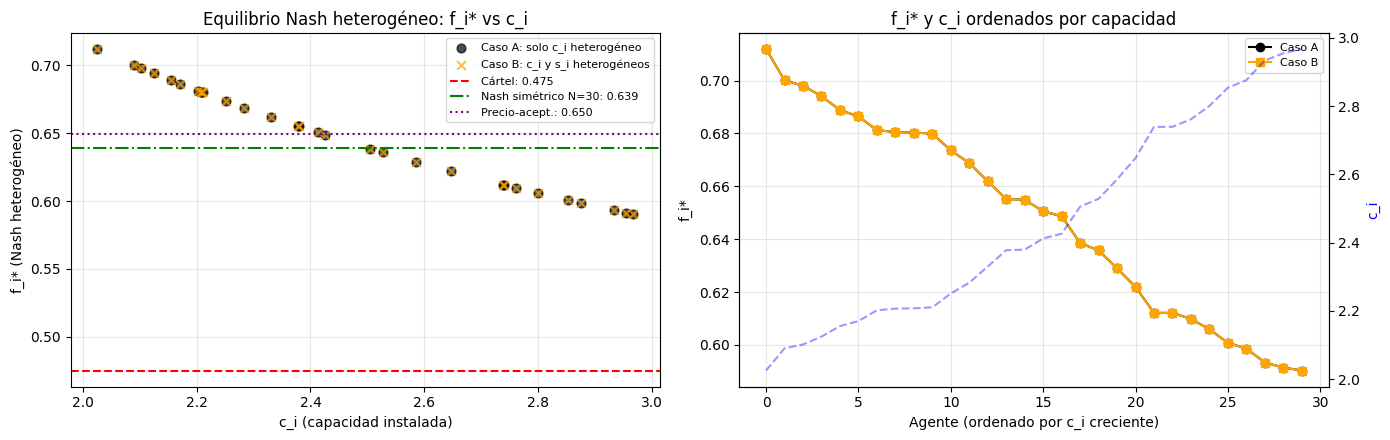

In [22]:
# Uso: extraer parámetros heterogéneos directamente del modelo Mesa
# (capacidades y baterías individuales, idénticas a las que ven los agentes ABM)
PARAMS_INTERIOR_HET = {
    'N': 30,
    'DEMAND_M': 80.0,
    'DEMAND_E': 120.0,
    'CAP_LOW': 3,
    'CAP_HIGH': 2,
    'STOR_CAP_LOW': 10,
    'STOR_CAP_HIGH': 10,
    'STORAGE_GRAN': 10,
}
template_model = MarketModel(params=PARAMS_INTERIOR_HET, seed=0)
c_modelo = np.array([a.capacity for a in template_model.agents])
s_modelo = np.array([a.storage_capacity for a in template_model.agents])
eta_modelo = float(np.mean([a.eta for a in template_model.agents]))

# Caso A: heterogeneidad solo en c_i (Anexo B.1)
res_c = solve_nash_heterogeneo(
    params=PARAMS_INTERIOR_HET, c_array=c_modelo, s_array=None, eta=eta_modelo
)

# Caso B: heterogeneidad en c_i Y s_i (Anexo B.2)
res_cs = solve_nash_heterogeneo(
    params=PARAMS_INTERIOR_HET, c_array=c_modelo, s_array=s_modelo, eta=eta_modelo
)

print('=== Caso A: heterogeneidad solo en c_i (Anexo B.1) ===')
print(f"  Residual: {res_c['residual_norm']:.2e}   sol_status={res_c['sol_status']}")
print(f"  f_array: min={res_c['f_array'].min():.4f}, max={res_c['f_array'].max():.4f}, mean={res_c['f_array'].mean():.4f}, std={res_c['f_array'].std():.4f}")
print(f"  c_array: min={c_modelo.min():.3f}, max={c_modelo.max():.3f}, mean={c_modelo.mean():.3f}")
print(f"  Corr(c_i, f_i*) = {np.corrcoef(c_modelo, res_c['f_array'])[0,1]:+.4f}    (heurística B.1.4: < 0)")
print(f"  PM = {res_c['PM']:.2f},  PE = {res_c['PE']:.2f},  PM/PE = {res_c['ratio']:.4f}    (η = {eta_modelo:.3f})")

print()
print('=== Caso B: heterogeneidad en c_i Y s_i (Anexo B.2) ===')
print(f"  Residual: {res_cs['residual_norm']:.2e}   sol_status={res_cs['sol_status']}")
print(f"  f_array: min={res_cs['f_array'].min():.4f}, max={res_cs['f_array'].max():.4f}, mean={res_cs['f_array'].mean():.4f}")
print(f"  f_sat:   min={res_cs['f_sat'].min():.4f}, max={res_cs['f_sat'].max():.4f}, mean={res_cs['f_sat'].mean():.4f}")
saturados = (res_cs['f_array'] >= res_cs['f_sat'] - 1e-3).sum()
print(f"  Agentes saturados: {saturados}/{len(c_modelo)}")
print(f"  Corr(c_i, f_i*) = {np.corrcoef(c_modelo, res_cs['f_array'])[0,1]:+.4f}")
print(f"  Corr(s_i, f_i*) = {np.corrcoef(s_modelo, res_cs['f_array'])[0,1]:+.4f}")
print(f"  PM/PE = {res_cs['ratio']:.4f}")

# Plot: dispersión f_i* vs c_i, comparada con las referencias homogéneas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.scatter(c_modelo, res_c['f_array'], color='black', s=40, alpha=0.7,
            label='Caso A: solo c_i heterogéneo')
ax1.scatter(c_modelo, res_cs['f_array'], color='orange', s=40, alpha=0.7, marker='x',
            label='Caso B: c_i y s_i heterogéneos')
if 'optimo_unico' in globals():
    ax1.axhline(optimo_unico['f_star'], color='red', linestyle='--',
                label=f"Cártel: {optimo_unico['f_star']:.3f}")
if 'nash_cpo_n30' in globals():
    ax1.axhline(nash_cpo_n30['f_star'], color='green', linestyle='-.',
                label=f"Nash simétrico N=30: {nash_cpo_n30['f_star']:.3f}")
if 'optimo_homogeneo' in globals() and 'price_taker_approx' in optimo_homogeneo:
    ax1.axhline(optimo_homogeneo['price_taker_approx']['f_star'], color='purple', linestyle=':',
                label=f"Precio-acept.: {optimo_homogeneo['price_taker_approx']['f_star']:.3f}")
ax1.set_xlabel('c_i (capacidad instalada)'); ax1.set_ylabel('f_i* (Nash heterogéneo)')
ax1.set_title('Equilibrio Nash heterogéneo: f_i* vs c_i')
ax1.legend(fontsize=8, loc='best'); ax1.grid(alpha=0.3)

# Plot 2: ordenar por c_i creciente y mostrar f_i*
order = np.argsort(c_modelo)
ax2.plot(np.arange(len(c_modelo)), res_c['f_array'][order], 'o-', color='black',
         label='Caso A')
ax2.plot(np.arange(len(c_modelo)), res_cs['f_array'][order], 's-', color='orange',
         label='Caso B')
ax2_twin = ax2.twinx()
ax2_twin.plot(np.arange(len(c_modelo)), c_modelo[order], '--', color='blue', alpha=0.4,
              label='c_i (eje derecho)')
ax2.set_xlabel('Agente (ordenado por c_i creciente)'); ax2.set_ylabel('f_i*')
ax2_twin.set_ylabel('c_i', color='blue')
ax2.set_title('f_i* y c_i ordenados por capacidad')
ax2.legend(loc='upper right', fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## §3 Runner y monkey-patch

`run_with_rule` ejecuta una simulación con `rule_fn` como regla de aprendizaje. Devuelve un dict con todo lo necesario para las visualizaciones posteriores.


In [23]:
def beneficio_contrafactual(agent, f, price_M=None, price_E=None):
    """Beneficio contrafactual del agente si hubiera elegido f (con los precios de hoy)."""
    pM = agent.model.price_M if price_M is None else price_M
    pE = agent.model.price_E if price_E is None else price_E
    stored_f = min(agent.storage_capacity, agent.eta * f * agent.qM_raw)
    sold_M = (1.0 - f) * agent.qM_raw
    sold_E = agent.qE_raw + stored_f
    return pM * sold_M + pE * sold_E


def pi_all_dict(agent, price_M=None, price_E=None):
    """Dict {f: beneficio_contrafactual} para todas las fracciones."""
    return {f: beneficio_contrafactual(agent, f, price_M, price_E) for f in agent.fractions}


In [24]:
def run_with_rule(rule_fn, params=None, seed=0, days=500, storage_enabled=True, rule_name=None):
    """Corre simulación con rule_fn (monkey-patch de update_learning).

    Devuelve dict con:
      - model:      MarketModel tras simular
      - df_model:   DataFrame modelo-nivel (día, precios, f media, gas, profits agregados...)
      - df_agents:  DataFrame agentes (día, agent_id, agent_choice, agent_profit,...)
      - df_attract: DataFrame long (day, agent_id, f, attract)
      - df_probs:   DataFrame long (day, agent_id, f, prob)  — softmax(attract) aplicada
      - params, seed, rule_name
    """
    original = SolarAgent.update_learning

    def patched_update(self, profit):
        self.profit = profit
        if not self.storage_enabled:
            return
        rule_fn(self, profit)

    SolarAgent.update_learning = patched_update
    try:
        model = MarketModel(params=params, storage_enabled=storage_enabled, seed=seed)
        attract_rows = []
        prob_rows = []
        for _ in range(days):
            model.step_day()
            day = model.current_day
            for a in model.agents:
                aid = a.unique_id
                arr = np.array([a.attract[f] for f in a.fractions], dtype=float)
                probs = stable_softmax(arr, a.beta)
                for f, A, P in zip(a.fractions, arr, probs):
                    attract_rows.append((day, aid, f, float(A)))
                    prob_rows.append((day, aid, f, float(P)))
        df_attract = pd.DataFrame(attract_rows, columns=['day', 'agent_id', 'f', 'attract'])
        df_probs = pd.DataFrame(prob_rows, columns=['day', 'agent_id', 'f', 'prob'])
        return {
            'model': model,
            'df_model': model.get_model_data(),
            'df_agents': model.get_agent_data(),
            'df_attract': df_attract,
            'df_probs': df_probs,
            'params': model.params,
            'seed': seed,
            'rule_name': rule_name or rule_fn.__name__,
        }
    finally:
        SolarAgent.update_learning = original


## §4 Métricas y visualizaciones genéricas

Todas trabajan sobre el `resultado` devuelto por `run_with_rule`. Los filtros (`agent_ids`, `fracciones`, `day_range`) permiten re-visualizar sin re-simular.


### Vistas por agente (ficha, cmap)


In [25]:
def agent_info(model, agent_id):
    for a in model.agents:
        if a.unique_id == agent_id:
            return {'agent_id': agent_id, 'capacity': a.capacity,
                    'storage_capacity': a.storage_capacity, 'eta': a.eta,
                    'phi': a.phi, 'beta': a.beta}
    return None


def ficha_agentes(model, agent_ids=None):
    if agent_ids is None:
        agent_ids = sorted(a.unique_id for a in model.agents)
    return pd.DataFrame([agent_info(model, aid) for aid in agent_ids]).set_index('agent_id')


def _cmap_sign_aware(values):
    v = np.asarray(values, dtype=float)
    vmin, vmax = float(v.min()), float(v.max())
    if vmin >= 0:
        return 'viridis', vmin, vmax
    if vmax <= 0:
        return 'viridis_r', vmin, vmax
    m = max(abs(vmin), abs(vmax))
    return 'coolwarm', -m, m


def _short_ficha(model, agent_ids):
    bits = []
    for aid in agent_ids:
        inf = agent_info(model, aid)
        if inf:
            bits.append(f"a{aid}[cap={inf['capacity']:.2f}, stor={inf['storage_capacity']:.2f}, β={inf['beta']:.1f}, φ={inf['phi']:.2f}]")
    return ' | '.join(bits)


def seleccionar_agentes_diversos(model, n=6):
    """Selecciona n agentes con storage_capacity diversa."""
    info = [(a.unique_id, a.storage_capacity) for a in model.agents]
    info.sort(key=lambda x: x[1])
    if n >= len(info):
        return [aid for aid, _ in info]
    idx = np.linspace(0, len(info) - 1, n).astype(int)
    return [info[i][0] for i in idx]


### Resumen de métricas fijas


In [26]:
def resumen_metricas(resultado, optimo=None, last=100):
    """Métricas fijas de una corrida (últimos `last` días para estadísticas).

    Incluye: f media temporal, f final, las 3 std (de medias, intraday mean, temporal mean),
    precios medios y ratio, profit agregado, atracción de f elegida, probabilidad de f elegida
    (media y varianza). Si `optimo` se pasa, añade gap_profit_pct, gap_f_abs.
    """
    df = resultado['df_model']
    df_a = resultado['df_agents']

    tail_model = df.tail(last)
    min_day = int(tail_model['day'].min())
    tail_agents = df_a[df_a['day'] >= min_day]

    intraday_std = tail_agents.groupby('day')['agent_choice'].std(ddof=0)
    temporal_std = tail_agents.groupby('agent_id')['agent_choice'].std(ddof=0)

    profit_agregado = tail_model['avg_profit'].mean()
    price_M_mean = tail_model['price_M'].mean()
    price_E_mean = tail_model['price_E'].mean()
    # ratio P_M/P_E: media de cocientes diarios (convencion del capitulo, refleja la inversion del ciclo)
    price_ratio_daily = float((tail_model['price_M'] / tail_model['price_E'].clip(lower=1e-9)).mean())
    # dias en extremos: sobre TODA la serie (no solo la cola), como en generate_figures_cap4.py
    daily_all = df['avg_storage_fraction']
    extremos_pct = 100.0 * float(((daily_all < 0.15) | (daily_all > 0.95)).mean())

    # Atracción de f elegida (merge con df_attract)
    df_att = resultado['df_attract']
    merged_att = df_a[['day', 'agent_id', 'agent_choice']].merge(
        df_att, left_on=['day', 'agent_id', 'agent_choice'],
        right_on=['day', 'agent_id', 'f'], how='inner'
    )
    atraccion_elegida = merged_att[merged_att['day'] >= min_day]['attract'].mean()

    # Probabilidad (softmax) de la f elegida (merge con df_probs)
    df_pr = resultado['df_probs']
    merged_pr = df_a[['day', 'agent_id', 'agent_choice']].merge(
        df_pr, left_on=['day', 'agent_id', 'agent_choice'],
        right_on=['day', 'agent_id', 'f'], how='inner'
    )
    probs_tail = merged_pr[merged_pr['day'] >= min_day]['prob']
    prob_elegida_media = float(probs_tail.mean()) if len(probs_tail) else None
    prob_elegida_var   = float(probs_tail.var())  if len(probs_tail) else None
    prob_elegida_std   = float(probs_tail.std())  if len(probs_tail) else None

    out = {
        'rule_name': resultado['rule_name'],
        'seed': resultado['seed'],
        'days': int(df['day'].max()),
        'f_media_temporal': float(tail_model['avg_storage_fraction'].mean()),
        'f_final_avg': float(df['avg_storage_fraction'].iloc[-1]),
        'f_std_de_medias': float(tail_model['avg_storage_fraction'].std(ddof=0)),
        'f_std_intraday_mean': float(intraday_std.mean()),
        'f_std_temporal_mean': float(temporal_std.mean()),
        'price_M_mean': float(price_M_mean),
        'price_E_mean': float(price_E_mean),
        'price_ratio_mean': price_ratio_daily,
        'price_ratio_of_means': float(price_M_mean / max(price_E_mean, 1e-9)),
        'extremos_pct': extremos_pct,
        'profit_agregado_mean': float(profit_agregado),
        'atraccion_elegida_media': float(atraccion_elegida) if not np.isnan(atraccion_elegida) else None,
        'prob_elegida_media': prob_elegida_media,
        'prob_elegida_std':   prob_elegida_std,
        'prob_elegida_var':   prob_elegida_var,
    }

    if optimo is not None:
        out['gap_profit_pct'] = 100 * (optimo['profit_star'] - profit_agregado) / max(optimo['profit_star'], 1e-9)
        out['gap_f_abs'] = float(abs(out['f_final_avg'] - optimo['f_star']))
        out['ratio_vs_optimo'] = float(out['price_ratio_mean'] - optimo['ratio_star'])

    return out


def print_resumen(res):
    for k, v in res.items():
        if isinstance(v, float):
            print(f"  {k:30s}: {v:10.4f}")
        else:
            print(f"  {k:30s}: {v}")


### Tablas por agente


In [27]:
def tabla_profits_por_agente(resultado, agent_ids=None, last=100):
    df_a = resultado['df_agents']
    max_day = int(df_a['day'].max())
    tail = df_a[df_a['day'] >= max_day - last + 1]
    if agent_ids is not None:
        tail = tail[tail['agent_id'].isin(agent_ids)]
    return tail.groupby('agent_id')['agent_profit'].mean().to_frame('profit_medio')


def tabla_atraccion_elegida_por_agente(resultado, agent_ids=None, last=100):
    df_a = resultado['df_agents']
    df_att = resultado['df_attract']
    max_day = int(df_a['day'].max())
    tail_a = df_a[df_a['day'] >= max_day - last + 1]
    if agent_ids is not None:
        tail_a = tail_a[tail_a['agent_id'].isin(agent_ids)]
    merged = tail_a[['day', 'agent_id', 'agent_choice']].merge(
        df_att, left_on=['day', 'agent_id', 'agent_choice'],
        right_on=['day', 'agent_id', 'f'], how='inner'
    )
    return merged.groupby('agent_id')['attract'].mean().to_frame('atraccion_elegida_media')


### Evoluciones (plots + tablas)


In [28]:
def plot_evolucion_f_media(resultado, ax=None):
    df = resultado['df_model']
    df_a = resultado['df_agents']
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df['day'], df['avg_storage_fraction'], color='black', label='f media entre agentes')
    intraday_std = df_a.groupby('day')['agent_choice'].std()
    ax.fill_between(
        intraday_std.index,
        df['avg_storage_fraction'] - intraday_std.values,
        df['avg_storage_fraction'] + intraday_std.values,
        alpha=0.25, label='± std intraday',
    )
    ax.set_xlabel('día'); ax.set_ylabel('f'); ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"Evolución de f media — {resultado['rule_name']} (seed={resultado['seed']})")
    ax.legend(); ax.grid(alpha=0.3)
    return ax


def tabla_evolucion_f_media(resultado, n_puntos=21, tail=10, decimales=4):
    """Devuelve (serie_completa, muestra_equiespaciada, cola).

    - serie_completa: DataFrame indexado por día con columnas f_media y f_std_intraday.
    - muestra_equiespaciada: n_puntos a lo largo de la serie (incluyendo extremos).
    - cola: últimos `tail` días.
    """
    df = resultado['df_model'][['day', 'avg_storage_fraction']].rename(
        columns={'avg_storage_fraction': 'f_media'}
    )
    intraday_std = (
        resultado['df_agents'].groupby('day')['agent_choice'].std().rename('f_std_intraday')
    )
    serie = df.set_index('day').join(intraday_std).round(decimales)

    n_dias = len(serie)
    if n_dias <= 2 * n_puntos:
        muestra = serie
    else:
        idx = np.linspace(0, n_dias - 1, n_puntos, dtype=int)
        muestra = serie.iloc[idx]
    cola = serie.tail(tail)
    return serie, muestra, cola


def print_evolucion_f_media(resultado, n_puntos=21, tail=10):
    """Imprime la serie numérica de f media (muestra equiespaciada + cola)."""
    _, muestra, cola = tabla_evolucion_f_media(resultado, n_puntos=n_puntos, tail=tail)
    print(f"Muestra equiespaciada ({len(muestra)} pts) — f media entre agentes:")
    print(muestra.to_string())
    print(f"\nCola (últimos {len(cola)} días):")
    print(cola.to_string())


def _filtrar_wide(df_long, value_col, agent_ids=None, fracciones=None, day_range=None):
    d = df_long.copy()
    if agent_ids is not None:
        d = d[d['agent_id'].isin(agent_ids)]
    if fracciones is not None:
        d = d[d['f'].isin(fracciones)]
    if day_range is not None:
        d = d[(d['day'] >= day_range[0]) & (d['day'] <= day_range[1])]
    return d.pivot_table(index='day', columns=['agent_id', 'f'], values=value_col)


def _plot_long_lines(wide, resultado, ylabel, title_prefix, ax=None, ylim=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 5))
    for col in wide.columns:
        label = f'a{col[0]} f={col[1]:.1f}' if isinstance(col, tuple) else f'a{col}'
        ax.plot(wide.index, wide[col], label=label, alpha=0.7, linewidth=1)
    ids_usados = sorted({(c[0] if isinstance(c, tuple) else c) for c in wide.columns})
    ficha_txt = _short_ficha(resultado['model'], ids_usados) if len(ids_usados) <= 6 else f'{len(ids_usados)} agentes'
    ax.set_xlabel('día'); ax.set_ylabel(ylabel)
    ax.set_title(f"{title_prefix} — {resultado['rule_name']}\n{ficha_txt}")
    if ylim is not None:
        ax.set_ylim(*ylim)
    if len(wide.columns) <= 15:
        ax.legend(fontsize=7, ncol=3)
    ax.grid(alpha=0.3)
    return ax


In [29]:
def plot_evolucion_atracciones(resultado, agent_ids=None, fracciones=None, day_range=None, ax=None):
    wide = _filtrar_wide(resultado['df_attract'], 'attract', agent_ids, fracciones, day_range)
    return _plot_long_lines(wide, resultado, 'atracción A(f)', 'Atracciones', ax)


def tabla_atracciones(resultado, agent_ids=None, fracciones=None, day_range=None):
    return _filtrar_wide(resultado['df_attract'], 'attract', agent_ids, fracciones, day_range)


def plot_evolucion_probabilidades(resultado, agent_ids=None, fracciones=None, day_range=None, ax=None):
    wide = _filtrar_wide(resultado['df_probs'], 'prob', agent_ids, fracciones, day_range)
    return _plot_long_lines(wide, resultado, 'P(f)', 'Probabilidades softmax', ax, ylim=(-0.05, 1.05))


def tabla_probabilidades(resultado, agent_ids=None, fracciones=None, day_range=None):
    return _filtrar_wide(resultado['df_probs'], 'prob', agent_ids, fracciones, day_range)


def plot_evolucion_f_elegida(resultado, agent_ids=None, day_range=None, ax=None):
    d = resultado['df_agents'].copy()
    if agent_ids is not None:
        d = d[d['agent_id'].isin(agent_ids)]
    if day_range is not None:
        d = d[(d['day'] >= day_range[0]) & (d['day'] <= day_range[1])]
    wide = d.pivot_table(index='day', columns='agent_id', values='agent_choice')
    return _plot_long_lines(wide, resultado, 'f elegida', 'f elegida', ax, ylim=(-0.05, 1.05))


def tabla_f_elegida(resultado, agent_ids=None, day_range=None):
    d = resultado['df_agents'].copy()
    if agent_ids is not None:
        d = d[d['agent_id'].isin(agent_ids)]
    if day_range is not None:
        d = d[(d['day'] >= day_range[0]) & (d['day'] <= day_range[1])]
    return d.pivot_table(index='day', columns='agent_id', values='agent_choice')


def plot_evolucion_atraccion_elegida(resultado, agent_ids=None, day_range=None, ax=None):
    df_a = resultado['df_agents']
    df_att = resultado['df_attract']
    merged = df_a[['day', 'agent_id', 'agent_choice']].merge(
        df_att, left_on=['day', 'agent_id', 'agent_choice'],
        right_on=['day', 'agent_id', 'f'], how='inner'
    )
    if agent_ids is not None:
        merged = merged[merged['agent_id'].isin(agent_ids)]
    if day_range is not None:
        merged = merged[(merged['day'] >= day_range[0]) & (merged['day'] <= day_range[1])]
    wide = merged.pivot_table(index='day', columns='agent_id', values='attract')
    return _plot_long_lines(wide, resultado, 'A(f_elegida)', 'Atracción de f elegida', ax)


### Extras: entropía, tiempo de convergencia, multi-seed


In [30]:
def entropia_softmax(resultado, agent_ids=None, last=100):
    """Entropía media de la softmax por agente en los últimos `last` días.

    H = -sum_f p_f * log p_f. Baja = converge a una fracción, alta = explora. H_max = log(n_fracciones).
    """
    df_p = resultado['df_probs']
    max_day = int(df_p['day'].max())
    tail = df_p[df_p['day'] >= max_day - last + 1]
    if agent_ids is not None:
        tail = tail[tail['agent_id'].isin(agent_ids)]
    def H(p):
        p = np.asarray(p, dtype=float)
        p = p[p > 1e-12]
        return -(p * np.log(p)).sum()
    h_daily = tail.groupby(['day', 'agent_id'])['prob'].apply(H)
    h_agent = h_daily.groupby('agent_id').mean().to_frame('H_media')
    n_f = resultado['df_probs']['f'].nunique()
    h_agent['H_max'] = np.log(n_f)
    h_agent['entropia_norm'] = h_agent['H_media'] / h_agent['H_max']
    return h_agent


def tiempo_convergencia(resultado, threshold=0.05, k=20, agent_ids=None):
    """Primer día t en que |f_i(t') - f_i_final| < threshold para todo t'∈[t, t+k).

    f_i_final = media de las últimas k fracciones elegidas por el agente.
    Devuelve None en t_convergencia si nunca se cumple la condición.
    """
    df_a = resultado['df_agents']
    if agent_ids is not None:
        df_a = df_a[df_a['agent_id'].isin(agent_ids)]
    rows = []
    for aid, grp in df_a.groupby('agent_id'):
        grp = grp.sort_values('day')
        f_final = float(grp['agent_choice'].tail(k).mean())
        diff = (grp['agent_choice'] - f_final).abs().values
        t_conv = None
        for i in range(len(diff) - k + 1):
            if (diff[i:i + k] < threshold).all():
                t_conv = int(grp['day'].iloc[i]); break
        rows.append({'agent_id': aid, 'f_final': f_final, 't_convergencia': t_conv})
    return pd.DataFrame(rows).set_index('agent_id')


def resumen_multiseed(rule_fn, params=None, seeds=range(10), days=500, last=100, optimo=None, rule_name=None):
    """Corre N seeds y devuelve (DataFrame por seed, DataFrame agregado media/std)."""
    rows = []
    for seed in seeds:
        res = run_with_rule(rule_fn, params=params, seed=seed, days=days, rule_name=rule_name)
        rows.append(resumen_metricas(res, optimo=optimo, last=last))
    df = pd.DataFrame(rows).set_index('seed')
    num_cols = df.select_dtypes(include=[np.number]).columns
    agg = pd.DataFrame({'media': df[num_cols].mean(), 'std': df[num_cols].std()}).T
    return df, agg


## §5 Definiciones de las 5 reglas

| Regla | Señal | Fracciones que actualiza |
|---|---|---|
| `regla_cf_raw` | pi_f sin normalizar | todas |
| `regla_cf_zscore` | z-score de pi_f | todas |
| `regla_zscore_elegida` | z-score del pi realizado | solo la elegida |
| `make_regla_ewa(δ, ρ, φ)` | pi_f con imaginación δ | todas (ponderadas por δ) |
| `make_regla_ewa_zscore(δ, ρ, φ)` | z-score de pi_f con imaginación δ | todas (ponderadas por δ) |


In [31]:
def regla_cf_raw(agent, profit):
    """Contrafactual raw: actualiza TODAS las fracciones con pi_f sin normalizar.
    Decaimiento phi sobre atracciones previas. Riesgo: colapso softmax y ciclos.
    """
    for f, pi_f in pi_all_dict(agent).items():
        agent.attract[f] = (1 - agent.phi) * agent.attract[f] + agent.phi * pi_f


In [32]:
def regla_cf_zscore(agent, profit):
    """Contrafactual z-score: actualiza TODAS las fracciones con (pi_f - media) / std.
    Señal centrada y a escala unitaria. Evita colapso de softmax.
    """
    pi_all = pi_all_dict(agent)
    pi_arr = np.array(list(pi_all.values()))
    mean_pi, std_pi = pi_arr.mean(), pi_arr.std()
    if std_pi < 1e-8:
        return
    for f, pi_f in pi_all.items():
        z_f = (pi_f - mean_pi) / std_pi
        agent.attract[f] = (1 - agent.phi) * agent.attract[f] + agent.phi * z_f


In [33]:
def regla_zscore_elegida(agent, profit):
    """SOLO actualiza la fracción elegida.
    Señal = z-score del beneficio realizado. Las demás fracciones no decaen.
    """
    pi_all = pi_all_dict(agent)
    pi_arr = np.array(list(pi_all.values()))
    mean_pi, std_pi = pi_arr.mean(), pi_arr.std()
    if std_pi < 1e-8:
        return
    z = (profit - mean_pi) / std_pi
    f = agent.last_choice
    agent.attract[f] = (1 - agent.phi) * agent.attract[f] + agent.phi * z


In [34]:
def make_regla_ewa(delta=0.5, rho=0.9, phi=0.95):
    """Experience-Weighted Attraction (Camerer & Ho, 1999).

    delta in [0,1]: 0 = bandit (solo refuerza elegida), 1 = fictitious play (refuerza todas).
    rho   in [0,1]: decaimiento del peso historico N(t).
    phi   in [0,1]: depreciacion de atracciones pasadas. Es un parametro PROPIO de EWA,
                    NO el agent.phi del modelo (que es la tasa de aprendizaje de las
                    otras reglas). Camerer-Ho lo estiman tipicamente en 0.9-1.0.

        N(t)   = rho * N(t-1) + 1
        A(f,t) = [phi * N(t-1) * A(f,t-1) + (delta + (1-delta)*I(f==f_chosen)) * pi_f] / N(t)
    """
    def rule(agent, profit):
        if not hasattr(agent, '_ewa_N'):
            agent._ewa_N = 1.0
        N_old = agent._ewa_N
        N_new = rho * N_old + 1.0
        for f, pi_f in pi_all_dict(agent).items():
            I_f = 1.0 if abs(f - agent.last_choice) < 1e-9 else 0.0
            weight = delta + (1 - delta) * I_f
            agent.attract[f] = (phi * N_old * agent.attract[f] + weight * pi_f) / N_new
        agent._ewa_N = N_new
    rule.__name__ = f'ewa_d{delta:.2f}_r{rho:.2f}_p{phi:.2f}'
    return rule


In [35]:
def make_regla_ewa_zscore(delta=0.5, rho=0.9, phi=0.95):
    """EWA (Camerer & Ho, 1999) con z-score de los contrafactuales como senal.

    Identica a make_regla_ewa pero sustituye pi_f por z_f = (pi_f - mean) / std.
    Centra y reescala la senal, eliminando el 'foso' que la asimetria 1 vs delta
    creaba sobre el nivel absoluto de pi (causa del lock-in mecanico en EWA raw).

    delta in [0,1]: 0 = bandit, 1 = fictitious play.
    rho   in [0,1]: decaimiento del peso historico N(t).
    phi   in [0,1]: depreciacion de atracciones (parametro propio de EWA, NO agent.phi).
    """
    def rule(agent, profit):
        if not hasattr(agent, '_ewa_zs_N'):
            agent._ewa_zs_N = 1.0
        pi_all = pi_all_dict(agent)
        pi_arr = np.array(list(pi_all.values()))
        mean_pi, std_pi = pi_arr.mean(), pi_arr.std()
        if std_pi < 1e-8:
            return
        N_old = agent._ewa_zs_N
        N_new = rho * N_old + 1.0
        for f, pi_f in pi_all.items():
            z_f = (pi_f - mean_pi) / std_pi
            I_f = 1.0 if abs(f - agent.last_choice) < 1e-9 else 0.0
            weight = delta + (1 - delta) * I_f
            agent.attract[f] = (phi * N_old * agent.attract[f] + weight * z_f) / N_new
        agent._ewa_zs_N = N_new
    rule.__name__ = f'ewa_zs_d{delta:.2f}_r{rho:.2f}_p{phi:.2f}'
    return rule


## §6 Pruebas: contrafactual raw

Plantilla: 1) Config → 2) Ejecución → 3) Métricas → 4) Evolución agregada → 5) Config agentes → 6–9) Plots y tablas por agente → 10) Multi-seed (opcional).

**Importante:** las celdas 3–10 solo leen `resultado_cf_raw`. Cambia los filtros sin re-simular.


In [36]:
# --- 1) Config §6: edita y re-ejecuta para cambiar parametrización ---
CFG_CF_RAW = {
    'params': {
        **PARAMS_INTERIOR,
        # Aprendizaje (override de DEFAULT_PARAMS de model.py)
        'PHI_LOW': 0.05,
        'PHI_HIGH': 0.3,
        'BETA_LOW': 2,
        'BETA_HIGH': 3,
        # Eficiencia de almacenamiento (homogénea)
        'ETA_LOW': 0.9,
        'ETA_HIGH': 0.9,
    },
    'seed': 0,
    'days': 500,
}


In [37]:
# --- 2) Ejecutar simulación (se re-ejecuta al cambiar Config) ---
resultado_cf_raw = run_with_rule(
    regla_cf_raw,
    params=CFG_CF_RAW['params'],
    seed=CFG_CF_RAW['seed'],
    days=CFG_CF_RAW['days'],
    rule_name='cf_raw',
)
print(f"OK: {resultado_cf_raw['rule_name']} seed={resultado_cf_raw['seed']} days={CFG_CF_RAW['days']}")


OK: cf_raw seed=0 days=500


In [38]:
# --- 3) Métricas fijas ---
print(f"=== Métricas — cf_raw (seed={resultado_cf_raw['seed']}) ===")
_res = resumen_metricas(resultado_cf_raw, optimo=optimo_nash)
print_resumen(_res)


=== Métricas — cf_raw (seed=0) ===
  rule_name                     : cf_raw
  seed                          : 0
  days                          : 500
  f_media_temporal              :     0.6270
  f_final_avg                   :     0.1033
  f_std_de_medias               :     0.3803
  f_std_intraday_mean           :     0.1868
  f_std_temporal_mean           :     0.4330
  price_M_mean                  :   105.6163
  price_E_mean                  :   121.6456
  price_ratio_mean              :     1.1049
  price_ratio_of_means          :     0.8682
  extremos_pct                  :    60.6000
  profit_agregado_mean          :   226.6333
  atraccion_elegida_media       :   286.0032
  prob_elegida_media            :     0.6322
  prob_elegida_std              :     0.4227
  prob_elegida_var              :     0.1787
  gap_profit_pct                :    17.6310
  gap_f_abs                     :     0.5354
  ratio_vs_optimo               :     0.2247


In [39]:
print(optimo_homogeneo['price_taker_approx']['ratio_star'])

print(optimo_nash['ratio_star'])
print(optimo_nash['profit_star'])
print(optimo_nash['f_star'])

0.9
0.8801505521080754
275.1437884433719
0.6386924616410941


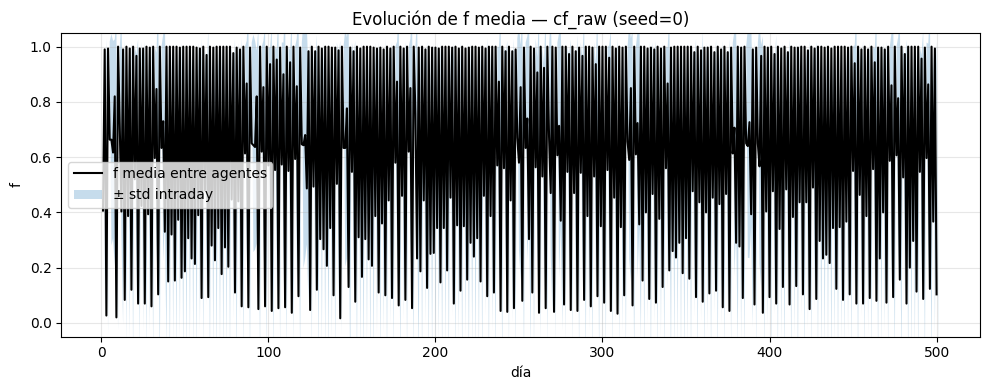

Muestra equiespaciada (21 pts) — f media entre agentes:
       f_media  f_std_intraday
day                           
1.0     0.4067             NaN
25.0    0.9933          0.4546
50.0    0.1867          0.0000
75.0    1.0000          0.3796
100.0   0.5700          0.0000
125.0   0.0467          0.0379
150.0   0.5467          0.0183
175.0   1.0000          0.2187
200.0   0.9967          0.3875
225.0   0.3067          0.0000
250.0   0.5800          0.4078
275.0   0.3700          0.3636
300.0   1.0000          0.4232
325.0   1.0000          0.2945
350.0   0.3067          0.0000
375.0   0.9800          0.4381
400.0   0.0933          0.0183
425.0   1.0000          0.1737
450.0   0.5500          0.0000
475.0   1.0000          0.2243
500.0   0.1033          0.0254

Cola (últimos 10 días):
       f_media  f_std_intraday
day                           
491.0   0.9567          0.4232
492.0   0.0867          0.1040
493.0   0.9967          0.2569
494.0   0.5967          0.0183
495.0   0.8633      

In [40]:
# --- 4) Evolución agregada (f media ± std intraday) ---
plot_evolucion_f_media(resultado_cf_raw)
plt.tight_layout(); plt.show()

print_evolucion_f_media(resultado_cf_raw)


In [41]:
# --- 5) Agentes y filtros para las vistas detalladas (edita y re-ejecuta sin re-simular) ---
AGENTES_CF_RAW = seleccionar_agentes_diversos(resultado_cf_raw['model'], n=1)
FRACCIONES_CF_RAW = [0.0, 0.3, 0.6, 0.7, 0.8, 0.9, 1]  # None = todas; o p.ej. [0.0, 0.3, 0.6, 0.9]
DIAS_CF_RAW = (0,50)   # None = todo; o p.ej. (400, 500)

print('Agentes seleccionados:')
ficha_agentes(resultado_cf_raw['model'], AGENTES_CF_RAW)


Agentes seleccionados:


,capacity,storage_capacity,eta,phi,beta
agent_id,,,,,
1,2.5,10.0,0.9,0.114729,2.511275


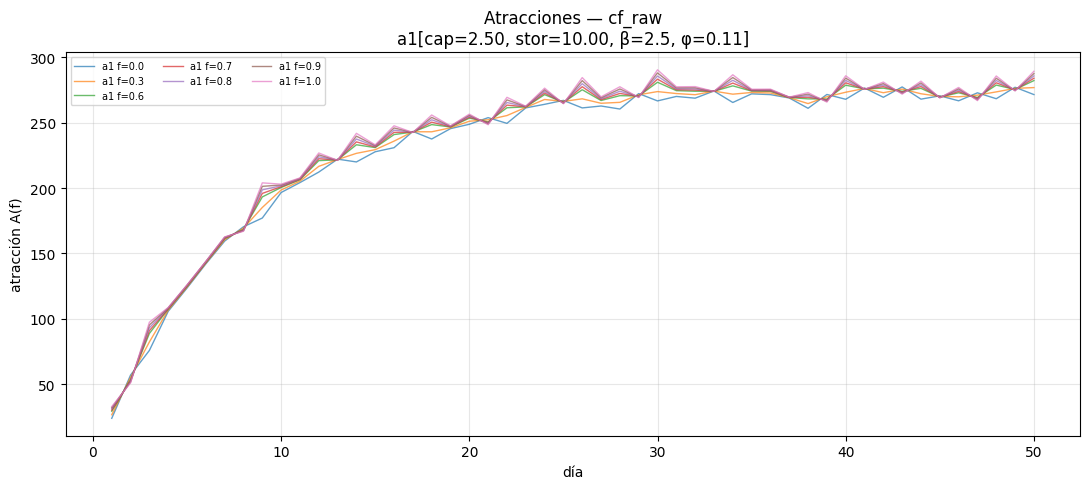

agent_id           1                                                                        
f                0.0         0.3         0.6         0.7         0.8         0.9         1.0
day                                                                                         
36        271.580166  272.838358  274.096441  274.515225  274.935742  275.354738  275.773161
37        269.035836  269.226624  269.417316  269.480369  269.544956  269.608197  269.670930
38        261.122538  264.731012  268.339400  269.541743  270.745445  271.947955  273.150016
39        271.704272  269.954746  268.205144  267.621543  267.039144  266.455690  265.871838
40        268.022180  273.417386  278.812525  280.610550  282.409640  284.207795  286.005599
41        276.659316  276.329251  275.999126  275.888770  275.779357  275.669117  275.558565
42        269.549385  273.040515  276.531592  277.695007  278.859255  280.022772  281.186013
43        277.473277  275.816973  274.160622  273.608260  273.056635  272.504363  271.951846
44        268.114157  272.248842  276.383486  277.761483  279.140133  280.518210  281.896071
45        270.685244  270.203702  269.722123  269.561404  269.401263  269.240615  269.079776
46        266.859912  269.924333  272.988721  274.010013  275.031817  276.053172  277.074357
47        272.977642  271.190273  269.402877  268.806927  268.211431  267.615536  267.019492
48        268.458981  273.676681  278.894355  280.633446  282.372939  284.112079  285.851087
49        277.217750  276.373214  275.528656  275.247018  274.965736  274.684141  274.402430
50        271.623897  276.971916  282.319915  284.102477  285.885353  287.667953  289.450449

In [42]:
# --- 6) Atracciones: plot + tabla (cola) ---
plot_evolucion_atracciones(resultado_cf_raw, AGENTES_CF_RAW, FRACCIONES_CF_RAW, DIAS_CF_RAW)
plt.tight_layout(); plt.show()
tabla_atracciones(resultado_cf_raw, AGENTES_CF_RAW, FRACCIONES_CF_RAW, DIAS_CF_RAW).tail(15)


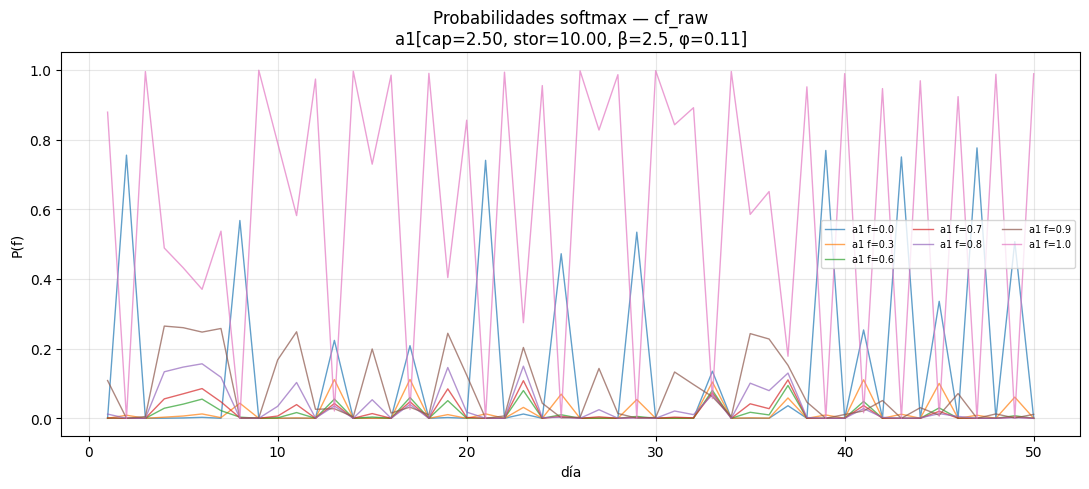

agent_id             1                                                                        
f                  0.0           0.3           0.6       0.7       0.8       0.9           1.0
day                                                                                           
36        1.739027e-05  4.097620e-04  9.652475e-03  0.027630  0.079434  0.227498  6.506142e-01
37        3.613192e-02  5.834058e-02  9.417723e-02  0.110335  0.129764  0.152099  1.780515e-01
38        7.255752e-14  6.254631e-10  5.390491e-06  0.000110  0.002269  0.046477  9.511386e-01
39        7.686186e-01  9.497733e-03  1.173403e-04  0.000027  0.000006  0.000001  3.347091e-07
40        2.409428e-20  1.845450e-14  1.413247e-08  0.000001  0.000118  0.010826  9.890541e-01
41        2.534941e-01  1.106592e-01  4.829950e-02  0.036609  0.027813  0.021087  1.597544e-02
42        1.926041e-13  1.236533e-09  7.937599e-06  0.000147  0.002744  0.050966  9.461342e-01
43        7.499262e-01  1.171114e-02  1.828644e-04  0.000046  0.000011  0.000003  7.131247e-07
44        9.018359e-16  2.914407e-11  9.417342e-07  0.000030  0.000956  0.030436  9.685767e-01
45        3.356846e-01  1.001718e-01  2.988958e-02  0.019963  0.013353  0.008920  5.956003e-03
46        6.683653e-12  1.469505e-08  3.230674e-05  0.000420  0.005465  0.071037  9.230436e-01
47        7.759470e-01  8.719063e-03  9.796629e-05  0.000022  0.000005  0.000001  2.464216e-07
48        1.061829e-19  5.207734e-14  2.553969e-08  0.000002  0.000159  0.012527  9.873124e-01
49        5.070184e-01  6.080584e-02  7.291933e-03  0.003595  0.001774  0.000875  4.310657e-04
50        3.571173e-20  2.429602e-14  1.652868e-08  0.000001  0.000128  0.011246  9.886250e-01

In [43]:
# --- 7) Probabilidades (softmax): plot + tabla (cola) ---
plot_evolucion_probabilidades(resultado_cf_raw, AGENTES_CF_RAW, FRACCIONES_CF_RAW, DIAS_CF_RAW)
plt.tight_layout(); plt.show()
tabla_probabilidades(resultado_cf_raw, AGENTES_CF_RAW, FRACCIONES_CF_RAW, DIAS_CF_RAW).tail(15)


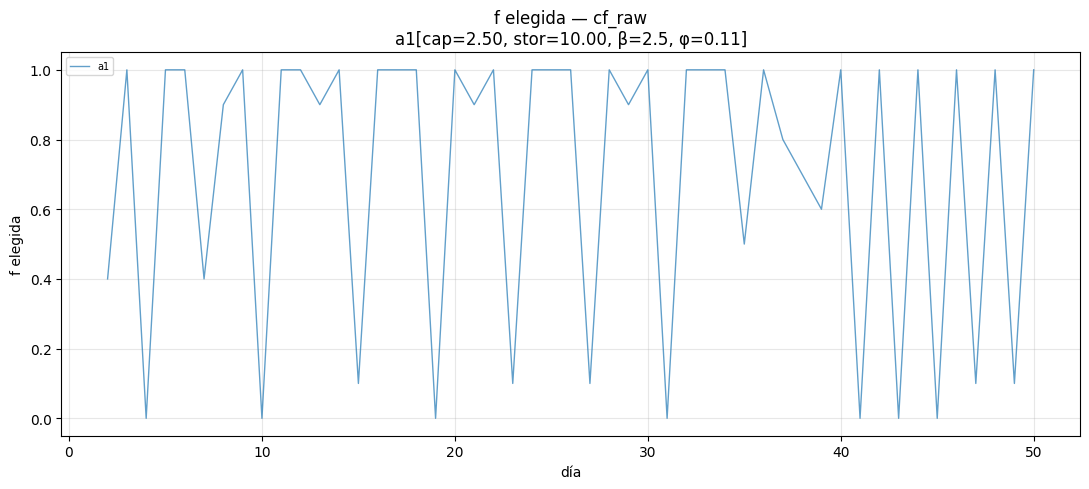

agent_id,1
day,
36.0,1.0
37.0,0.8
38.0,0.7
39.0,0.6
40.0,1.0
41.0,0.0
42.0,1.0
43.0,0.0
44.0,1.0


In [44]:
# --- 8) f elegida: plot + tabla (cola) ---
plot_evolucion_f_elegida(resultado_cf_raw, AGENTES_CF_RAW, DIAS_CF_RAW)
plt.tight_layout(); plt.show()
tabla_f_elegida(resultado_cf_raw, AGENTES_CF_RAW, DIAS_CF_RAW).tail(15)


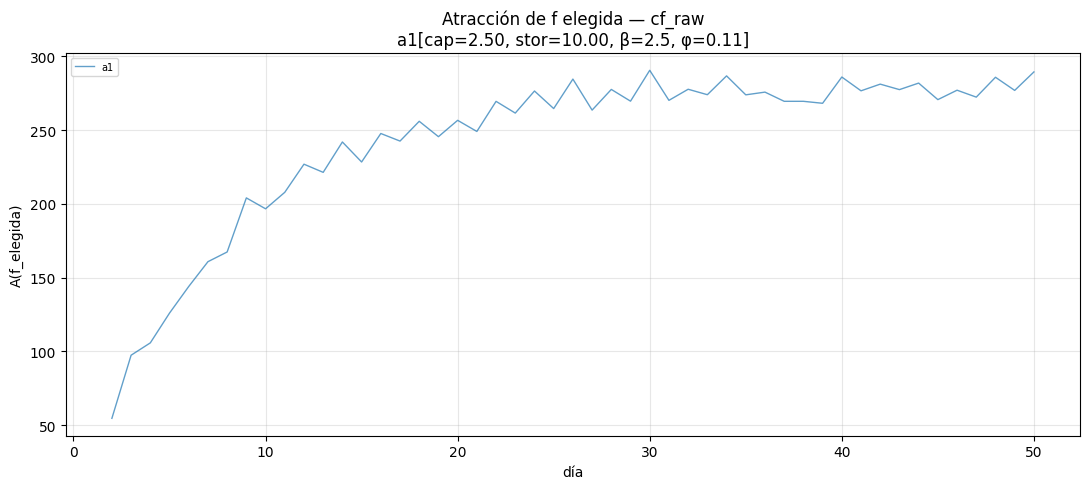

In [45]:
# --- 9) Atracción de la f elegida ---
plot_evolucion_atraccion_elegida(resultado_cf_raw, AGENTES_CF_RAW, DIAS_CF_RAW)
plt.tight_layout(); plt.show()


In [46]:
# --- Extras: entropía, tiempo de convergencia, profits/atracción por agente ---
print('Entropía softmax (últimos 100 días):')
display(entropia_softmax(resultado_cf_raw, AGENTES_CF_RAW))
print('\nTiempo hasta convergencia:')
display(tiempo_convergencia(resultado_cf_raw, threshold=0.05, k=20, agent_ids=AGENTES_CF_RAW))
print('\nProfits medios por agente:')
display(tabla_profits_por_agente(resultado_cf_raw, AGENTES_CF_RAW))
print('\nAtracción de f elegida media por agente:')
display(tabla_atraccion_elegida_por_agente(resultado_cf_raw, AGENTES_CF_RAW))


Entropía softmax (últimos 100 días):


,H_media,H_max,entropia_norm
agent_id,,,
1,0.722499,2.397895,0.301305



Tiempo hasta convergencia:


,f_final,t_convergencia
agent_id,,
1,0.67,None



Profits medios por agente:


,profit_medio
agent_id,
1,236.617168



Atracción de f elegida media por agente:


,atraccion_elegida_media
agent_id,
1,285.561837


In [47]:
# --- 10) Multi-seed opcional (descomentar para ejecutar; tarda) ---
# df_ms, agg_ms = resumen_multiseed(
#     regla_cf_raw, params=CFG_CF_RAW['params'], seeds=range(10),
#     days=CFG_CF_RAW['days'], optimo=optimo_homogeneo, rule_name='cf_raw',
# )
# print('Por seed:')
# display(df_ms[['f_final', 'gap_profit_pct', 'f_std_intraday_mean', 'atraccion_elegida_media']])
# print('\nAgregada:'); display(agg_ms)


## §7 Pruebas: contrafactual z-score

Plantilla: 1) Config → 2) Ejecución → 3) Métricas → 4) Evolución agregada → 5) Config agentes → 6–9) Plots y tablas por agente → 10) Multi-seed (opcional).

**Importante:** las celdas 3–10 solo leen `resultado_cf_zscore`. Cambia los filtros sin re-simular.


In [48]:
# --- 1) Config §7: edita y re-ejecuta para cambiar parametrización ---
CFG_CF_ZSCORE = {
    'params': {
        **PARAMS_INTERIOR,
        # Aprendizaje (override de DEFAULT_PARAMS de model.py)
        'PHI_LOW': 0.05,
        'PHI_HIGH': 0.3,
        'BETA_LOW': 2.0,
        'BETA_HIGH': 3.0,
        # Eficiencia de almacenamiento (homogénea)
        'ETA_LOW': 0.9,
        'ETA_HIGH': 0.9,
    },
    'seed': 0,
    'days': 500,
}


In [49]:
# --- 2) Ejecutar simulación (se re-ejecuta al cambiar Config) ---
resultado_cf_zscore = run_with_rule(
    regla_cf_zscore,
    params=CFG_CF_ZSCORE['params'],
    seed=CFG_CF_ZSCORE['seed'],
    days=CFG_CF_ZSCORE['days'],
    rule_name='cf_zscore',
)
print(f"OK: {resultado_cf_zscore['rule_name']} seed={resultado_cf_zscore['seed']} days={CFG_CF_ZSCORE['days']}")


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


OK: cf_zscore seed=0 days=500


In [50]:
# --- 3) Métricas fijas ---
print(f"=== Métricas — cf_zscore (seed={resultado_cf_zscore['seed']}) ===")
_res = resumen_metricas(resultado_cf_zscore, optimo=optimo_nash)
print_resumen(_res)


=== Métricas — cf_zscore (seed=0) ===
  rule_name                     : cf_zscore
  seed                          : 0
  days                          : 500
  f_media_temporal              :     0.6221
  f_final_avg                   :     0.6033
  f_std_de_medias               :     0.0986
  f_std_intraday_mean           :     0.2901
  f_std_temporal_mean           :     0.3071
  price_M_mean                  :   102.8495
  price_E_mean                  :   120.6831
  price_ratio_mean              :     0.8671
  price_ratio_of_means          :     0.8522
  extremos_pct                  :     0.0000
  profit_agregado_mean          :   273.6976
  atraccion_elegida_media       :     0.0660
  prob_elegida_media            :     0.1063
  prob_elegida_std              :     0.0511
  prob_elegida_var              :     0.0026
  gap_profit_pct                :     0.5256
  gap_f_abs                     :     0.0354
  ratio_vs_optimo               :    -0.0130


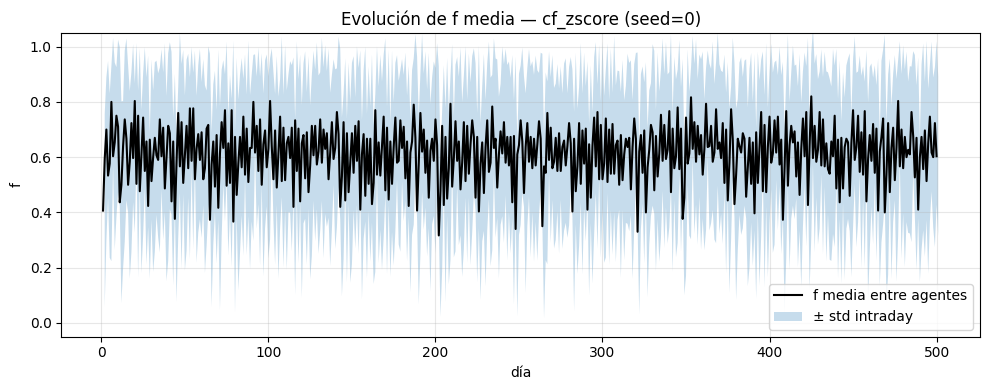

Muestra equiespaciada (21 pts) — f media entre agentes:
       f_media  f_std_intraday
day                           
1.0     0.4067             NaN
25.0    0.7433          0.2940
50.0    0.6067          0.3172
75.0    0.4967          0.2480
100.0   0.6300          0.3296
125.0   0.5700          0.3151
150.0   0.6867          0.3645
175.0   0.6367          0.2953
200.0   0.7367          0.3360
225.0   0.6733          0.3060
250.0   0.6433          0.2917
275.0   0.5500          0.2417
300.0   0.5200          0.3018
325.0   0.6967          0.3277
350.0   0.7433          0.2837
375.0   0.4433          0.2435
400.0   0.7467          0.2748
425.0   0.8200          0.3319
450.0   0.7700          0.3048
475.0   0.5167          0.2625
500.0   0.6033          0.2956

Cola (últimos 10 días):
       f_media  f_std_intraday
day                           
491.0   0.6733          0.3353
492.0   0.5567          0.3383
493.0   0.6967          0.3170
494.0   0.5133          0.3243
495.0   0.6500      

In [51]:
# --- 4) Evolución agregada (f media ± std intraday) ---
plot_evolucion_f_media(resultado_cf_zscore)
plt.tight_layout(); plt.show()

print_evolucion_f_media(resultado_cf_zscore)


In [52]:
# --- 5) Agentes y filtros para las vistas detalladas (edita y re-ejecuta sin re-simular) ---
AGENTES_CF_ZSCORE = seleccionar_agentes_diversos(resultado_cf_zscore['model'], n=1)
FRACCIONES_CF_ZSCORE = [0.0, 0.3, 0.6, 0.7, 0.8, 0.9, 1]  # None = todas; o p.ej. [0.0, 0.3, 0.6, 0.9]
DIAS_CF_ZSCORE = (0,50)   # None = todo; o p.ej. (400, 500)

print('Agentes seleccionados:')
ficha_agentes(resultado_cf_zscore['model'], AGENTES_CF_ZSCORE)


Agentes seleccionados:


,capacity,storage_capacity,eta,phi,beta
agent_id,,,,,
1,2.5,10.0,0.9,0.114729,2.511275


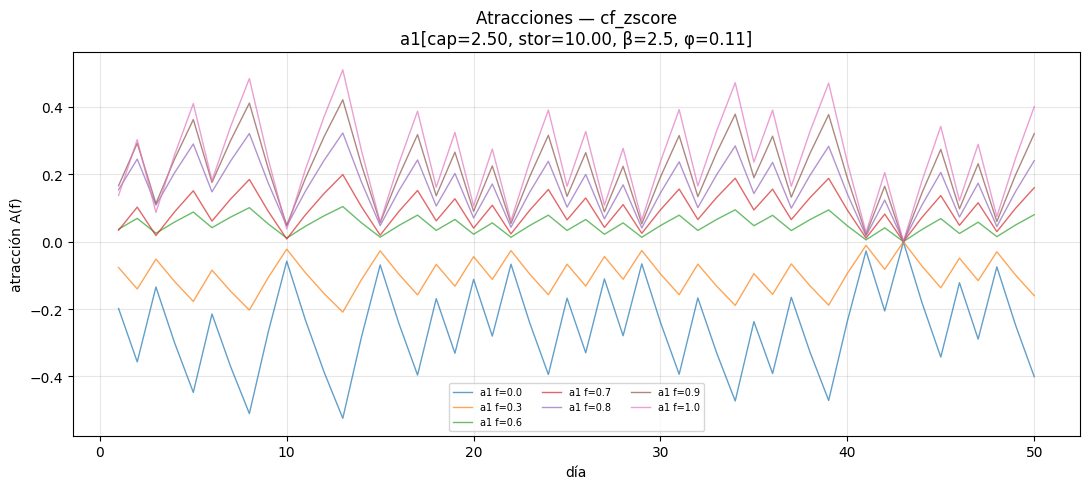

agent_id         1                                                            
f              0.0       0.3       0.6       0.7       0.8       0.9       1.0
day                                                                           
36       -0.391437 -0.156538  0.078252  0.155937  0.235357  0.313255  0.390580
37       -0.165125 -0.066018  0.032993  0.065486  0.099513  0.132193  0.164366
38       -0.327583 -0.131005  0.065489  0.130534  0.196937  0.262149  0.326911
39       -0.471402 -0.188536  0.094256  0.188119  0.283184  0.377195  0.470808
40       -0.235916 -0.094344  0.047161  0.093975  0.141853  0.188797  0.235390
41       -0.027447 -0.010959  0.005470  0.010632  0.016737  0.022015  0.026981
42       -0.205701 -0.082263  0.041123  0.081973  0.123658  0.164611  0.205288
43       -0.000698 -0.000264  0.000124  0.000008  0.000629  0.000603  0.000333
44       -0.182021 -0.072795  0.036391  0.072568  0.109399  0.145656  0.181697
45       -0.342540 -0.137004  0.068496  0.136803  0.205689  0.274067  0.342254
46       -0.121838 -0.048725  0.024357  0.048547  0.073249  0.097502  0.121585
47       -0.289263 -0.115696  0.057843  0.115538  0.173687  0.231438  0.289038
48       -0.074673 -0.029861  0.014926  0.029722  0.044918  0.059763  0.074474
49       -0.247509 -0.098996  0.049494  0.098873  0.148607  0.198028  0.247333
50       -0.400515 -0.160199  0.080097  0.160090  0.240399  0.320431  0.400359

In [53]:
# --- 6) Atracciones: plot + tabla (cola) ---
plot_evolucion_atracciones(resultado_cf_zscore, AGENTES_CF_ZSCORE, FRACCIONES_CF_ZSCORE, DIAS_CF_ZSCORE)
plt.tight_layout(); plt.show()
tabla_atracciones(resultado_cf_zscore, AGENTES_CF_ZSCORE, FRACCIONES_CF_ZSCORE, DIAS_CF_ZSCORE).tail(15)


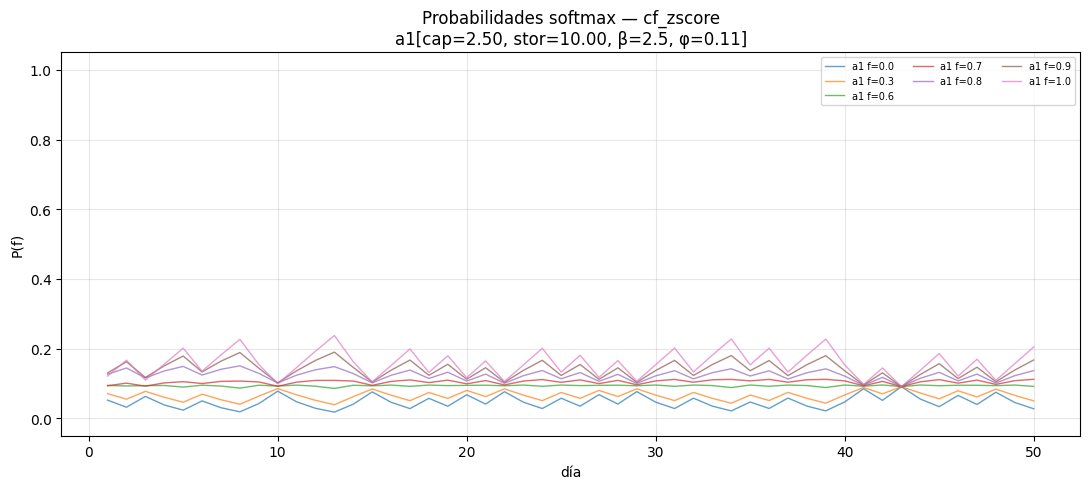

agent_id         1                                                            
f              0.0       0.3       0.6       0.7       0.8       0.9       1.0
day                                                                           
36        0.028242  0.050942  0.091865  0.111654  0.136299  0.165749  0.201272
37        0.058030  0.074429  0.095440  0.103554  0.112792  0.122439  0.132742
38        0.035004  0.057347  0.093932  0.110599  0.130669  0.153920  0.181104
39        0.021335  0.043410  0.088311  0.111785  0.141927  0.179720  0.227350
40        0.046908  0.066934  0.095494  0.107407  0.121130  0.136285  0.153202
41        0.084765  0.088348  0.092069  0.093271  0.094712  0.095975  0.097180
42        0.051443  0.070137  0.095613  0.105943  0.117634  0.130376  0.144398
43        0.090742  0.090841  0.090929  0.090903  0.091045  0.091039  0.090977
44        0.055218  0.072645  0.095563  0.104651  0.114793  0.125735  0.137647
45        0.033311  0.055816  0.093515  0.111015  0.131980  0.156706  0.185974
46        0.065707  0.078950  0.094854  0.100795  0.107246  0.113980  0.121087
47        0.039650  0.061311  0.094800  0.109580  0.126809  0.146601  0.169417
48        0.074834  0.083748  0.093718  0.097265  0.101049  0.104887  0.108834
49        0.045250  0.065704  0.095399  0.107993  0.122359  0.138528  0.156787
50        0.027371  0.050048  0.091509  0.111868  0.136865  0.167332  0.204527

In [54]:
# --- 7) Probabilidades (softmax): plot + tabla (cola) ---
plot_evolucion_probabilidades(resultado_cf_zscore, AGENTES_CF_ZSCORE, FRACCIONES_CF_ZSCORE, DIAS_CF_ZSCORE)
plt.tight_layout(); plt.show()
tabla_probabilidades(resultado_cf_zscore, AGENTES_CF_ZSCORE, FRACCIONES_CF_ZSCORE, DIAS_CF_ZSCORE).tail(15)


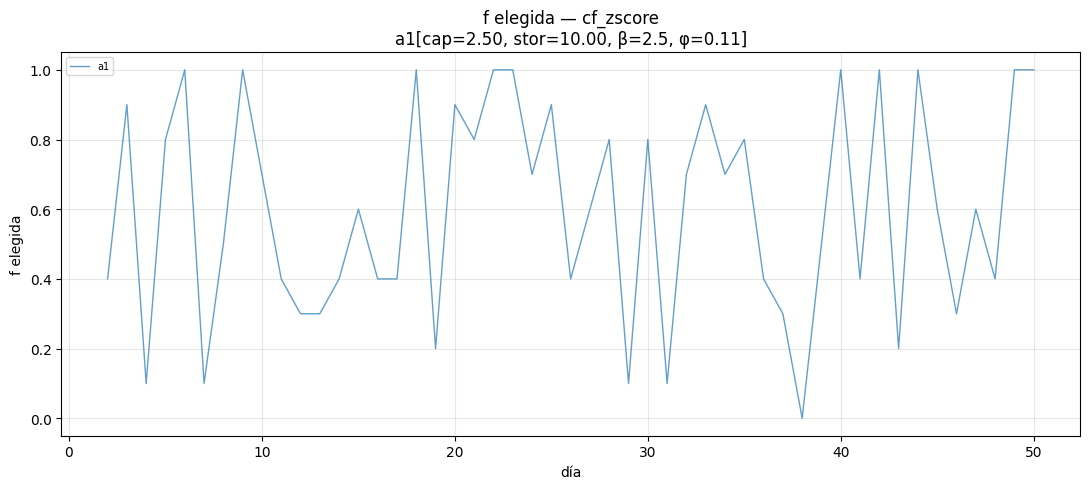

agent_id,1
day,
36.0,0.4
37.0,0.3
38.0,0.0
39.0,0.5
40.0,1.0
41.0,0.4
42.0,1.0
43.0,0.2
44.0,1.0


In [55]:
# --- 8) f elegida: plot + tabla (cola) ---
plot_evolucion_f_elegida(resultado_cf_zscore, AGENTES_CF_ZSCORE, DIAS_CF_ZSCORE)
plt.tight_layout(); plt.show()
tabla_f_elegida(resultado_cf_zscore, AGENTES_CF_ZSCORE, DIAS_CF_ZSCORE).tail(15)


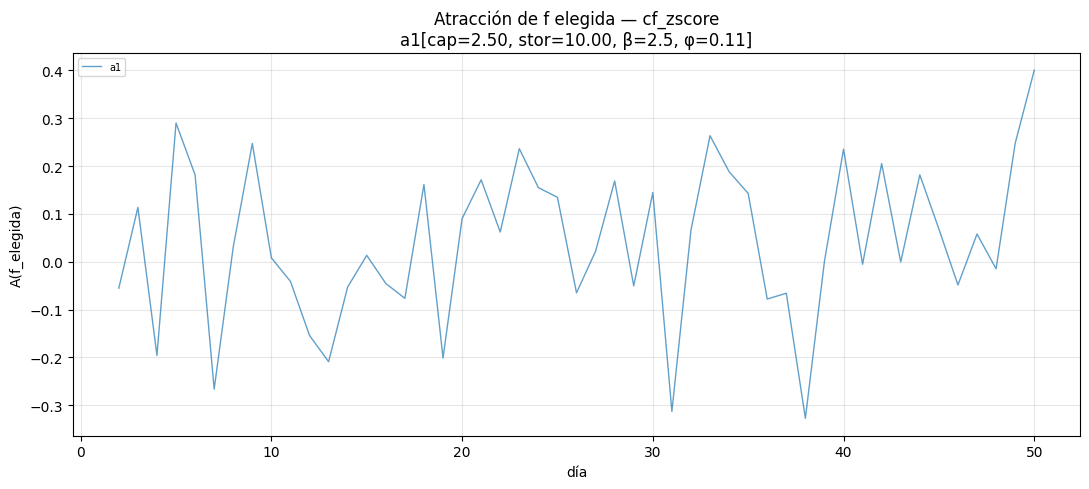

In [56]:
# --- 9) Atracción de la f elegida ---
plot_evolucion_atraccion_elegida(resultado_cf_zscore, AGENTES_CF_ZSCORE, DIAS_CF_ZSCORE)
plt.tight_layout(); plt.show()


In [57]:
# --- Extras: entropía, tiempo de convergencia, profits/atracción por agente ---
print('Entropía softmax (últimos 100 días):')
display(entropia_softmax(resultado_cf_zscore, AGENTES_CF_ZSCORE))
print('\nTiempo hasta convergencia:')
display(tiempo_convergencia(resultado_cf_zscore, threshold=0.05, k=20, agent_ids=AGENTES_CF_ZSCORE))
print('\nProfits medios por agente:')
display(tabla_profits_por_agente(resultado_cf_zscore, AGENTES_CF_ZSCORE))
print('\nAtracción de f elegida media por agente:')
display(tabla_atraccion_elegida_por_agente(resultado_cf_zscore, AGENTES_CF_ZSCORE))


Entropía softmax (últimos 100 días):


,H_media,H_max,entropia_norm
agent_id,,,
1,2.297724,2.397895,0.958226



Tiempo hasta convergencia:


,f_final,t_convergencia
agent_id,,
1,0.67,None



Profits medios por agente:


,profit_medio
agent_id,
1,277.356938



Atracción de f elegida media por agente:


,atraccion_elegida_media
agent_id,
1,0.062329


In [58]:
# --- 10) Multi-seed opcional (descomenta para ejecutar; tarda) ---
# df_ms, agg_ms = resumen_multiseed(
#     regla_cf_zscore, params=CFG_CF_ZSCORE['params'], seeds=range(10),
#     days=CFG_CF_ZSCORE['days'], optimo=optimo_homogeneo, rule_name='cf_zscore',
# )
# print('Por seed:')
# display(df_ms[['f_final', 'gap_profit_pct', 'f_std_intraday_mean', 'atraccion_elegida_media']])
# print('\nAgregada:'); display(agg_ms)


## §8 Pruebas: z-score solo elegida

Plantilla: 1) Config → 2) Ejecución → 3) Métricas → 4) Evolución agregada → 5) Config agentes → 6–9) Plots y tablas por agente → 10) Multi-seed (opcional).

**Importante:** las celdas 3–10 solo leen `resultado_zscore_elegida`. Cambia los filtros sin re-simular.


In [59]:
# --- 1) Config §8: edita y re-ejecuta para cambiar parametrización ---
CFG_ZSCORE_ELEGIDA = {
    'params': {
        **PARAMS_INTERIOR,
        # Aprendizaje (override de DEFAULT_PARAMS de model.py)
        'PHI_LOW': 0.05,
        'PHI_HIGH': 0.3,
        'BETA_LOW': 2.0,
        'BETA_HIGH': 3.0,
        # Eficiencia de almacenamiento (homogénea)
        'ETA_LOW': 0.9,
        'ETA_HIGH': 0.9,
    },
    'seed': 0,
    'days': 500,
}


In [60]:
# --- 2) Ejecutar simulación (se re-ejecuta al cambiar Config) ---
resultado_zscore_elegida = run_with_rule(
    regla_zscore_elegida,
    params=CFG_ZSCORE_ELEGIDA['params'],
    seed=CFG_ZSCORE_ELEGIDA['seed'],
    days=CFG_ZSCORE_ELEGIDA['days'],
    rule_name='zscore_elegida',
)
print(f"OK: {resultado_zscore_elegida['rule_name']} seed={resultado_zscore_elegida['seed']} days={CFG_ZSCORE_ELEGIDA['days']}")


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


OK: zscore_elegida seed=0 days=500


In [61]:
# --- 3) Métricas fijas ---
print(f"=== Métricas — zscore_elegida (seed={resultado_zscore_elegida['seed']}) ===")
_res = resumen_metricas(resultado_zscore_elegida, optimo=optimo_nash)
print_resumen(_res)




=== Métricas — zscore_elegida (seed=0) ===
  rule_name                     : zscore_elegida
  seed                          : 0
  days                          : 500
  f_media_temporal              :     0.6328
  f_final_avg                   :     0.6300
  f_std_de_medias               :     0.0443
  f_std_intraday_mean           :     0.2359
  f_std_temporal_mean           :     0.2372
  price_M_mean                  :   104.0141
  price_E_mean                  :   119.4013
  price_ratio_mean              :     0.8744
  price_ratio_of_means          :     0.8711
  extremos_pct                  :     0.0000
  profit_agregado_mean          :   275.1875
  atraccion_elegida_media       :     0.0139
  prob_elegida_media            :     0.1599
  prob_elegida_std              :     0.1116
  prob_elegida_var              :     0.0125
  gap_profit_pct                :    -0.0159
  gap_f_abs                     :     0.0087
  ratio_vs_optimo               :    -0.0057


In [62]:
print(optimo_homogeneo['price_taker_approx']['ratio_star'])

print(optimo_nash['ratio_star'])
print(optimo_nash['profit_star'])
print(optimo_nash['f_star'])

0.9
0.8801505521080754
275.1437884433719
0.6386924616410941


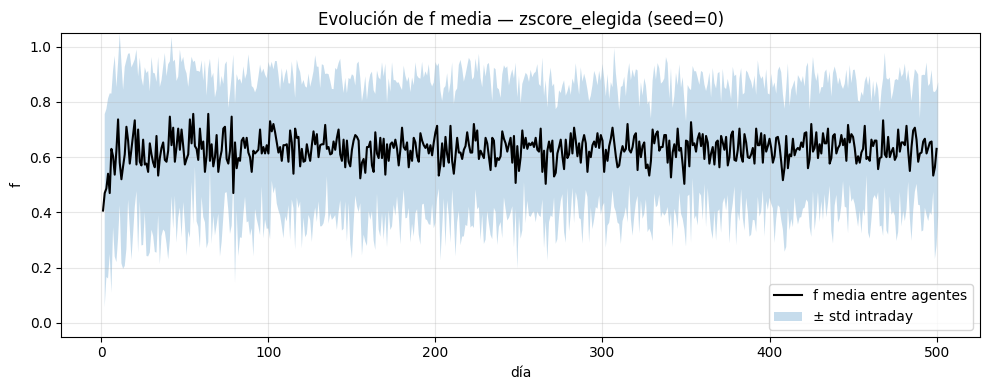

Muestra equiespaciada (21 pts) — f media entre agentes:
       f_media  f_std_intraday
day                           
1.0     0.4067             NaN
25.0    0.6633          0.2879
50.0    0.5733          0.2811
75.0    0.5933          0.2369
100.0   0.6133          0.3014
125.0   0.5867          0.2417
150.0   0.6267          0.3336
175.0   0.6333          0.2255
200.0   0.6900          0.2909
225.0   0.6967          0.2486
250.0   0.5500          0.2541
275.0   0.6633          0.1956
300.0   0.6600          0.2578
325.0   0.6533          0.2458
350.0   0.6600          0.2266
375.0   0.5700          0.2100
400.0   0.6667          0.1868
425.0   0.7200          0.2815
450.0   0.6733          0.2321
475.0   0.5900          0.2454
500.0   0.6300          0.2822

Cola (últimos 10 días):
       f_media  f_std_intraday
day                           
491.0   0.6167          0.2825
492.0   0.6567          0.2817
493.0   0.6667          0.2402
494.0   0.6133          0.2758
495.0   0.6333      

In [63]:
# --- 4) Evolución agregada (f media ± std intraday) ---
plot_evolucion_f_media(resultado_zscore_elegida)
plt.tight_layout(); plt.show()

print_evolucion_f_media(resultado_zscore_elegida)


In [64]:
# --- 5) Agentes y filtros para las vistas detalladas (edita y re-ejecuta sin re-simular) ---
AGENTES_ZSCORE_ELEGIDA = seleccionar_agentes_diversos(resultado_zscore_elegida['model'], n=1)
FRACCIONES_ZSCORE_ELEGIDA = [0.0, 0.3, 0.6, 0.7, 0.8, 0.9, 1]  # None = todas; o p.ej. [0.0, 0.3, 0.6, 0.9]
DIAS_ZSCORE_ELEGIDA = (50,100)   # None = todo; o p.ej. (400, 500)

print('Agentes seleccionados:')
ficha_agentes(resultado_zscore_elegida['model'], AGENTES_ZSCORE_ELEGIDA)


Agentes seleccionados:


,capacity,storage_capacity,eta,phi,beta
agent_id,,,,,
1,2.5,10.0,0.9,0.114729,2.511275


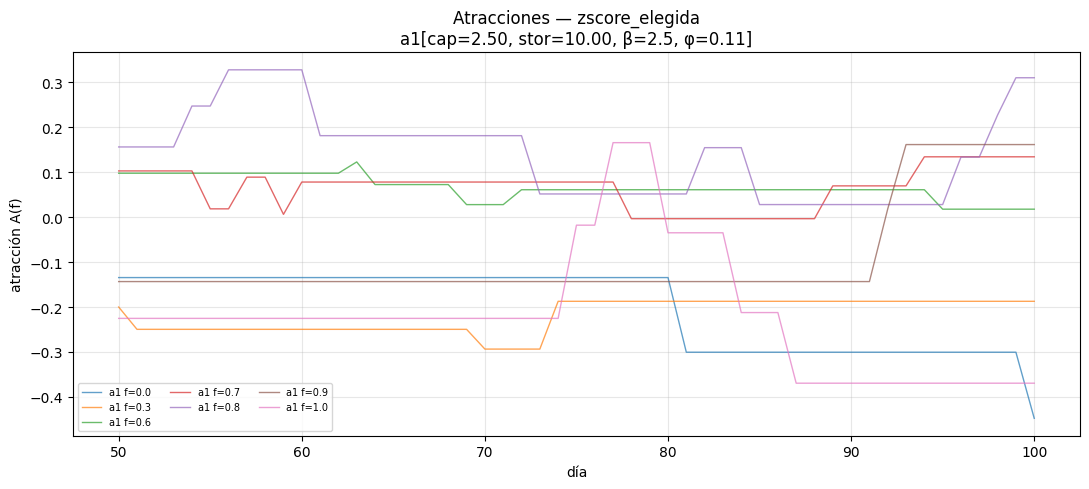

agent_id         1                                                            
f              0.0       0.3       0.6       0.7       0.8       0.9       1.0
day                                                                           
86       -0.300512 -0.187316  0.060773 -0.003628  0.027766 -0.143437 -0.212345
87       -0.300512 -0.187316  0.060773 -0.003628  0.027766 -0.143437 -0.369386
88       -0.300512 -0.187316  0.060773 -0.003628  0.027766 -0.143437 -0.369386
89       -0.300512 -0.187316  0.060773  0.069349  0.027766 -0.143437 -0.369386
90       -0.300512 -0.187316  0.060773  0.069349  0.027766 -0.143437 -0.369386
91       -0.300512 -0.187316  0.060773  0.069349  0.027766 -0.143437 -0.369386
92       -0.300512 -0.187316  0.060773  0.069349  0.027766  0.018142 -0.369386
93       -0.300512 -0.187316  0.060773  0.069349  0.027766  0.161182 -0.369386
94       -0.300512 -0.187316  0.060773  0.133954  0.027766  0.161182 -0.369386
95       -0.300512 -0.187316  0.017520  0.133954  0.027766  0.161182 -0.369386
96       -0.300512 -0.187316  0.017520  0.133954  0.133422  0.161182 -0.369386
97       -0.300512 -0.187316  0.017520  0.133954  0.133422  0.161182 -0.369386
98       -0.300512 -0.187316  0.017520  0.133954  0.226957  0.161182 -0.369386
99       -0.300512 -0.187316  0.017520  0.133954  0.309760  0.161182 -0.369386
100      -0.447437 -0.187316  0.017520  0.133954  0.309760  0.161182 -0.369386

In [65]:
# --- 6) Atracciones: plot + tabla (cola) ---
plot_evolucion_atracciones(resultado_zscore_elegida, AGENTES_ZSCORE_ELEGIDA, FRACCIONES_ZSCORE_ELEGIDA, DIAS_ZSCORE_ELEGIDA)
plt.tight_layout(); plt.show()
tabla_atracciones(resultado_zscore_elegida, AGENTES_ZSCORE_ELEGIDA, FRACCIONES_ZSCORE_ELEGIDA, DIAS_ZSCORE_ELEGIDA).tail(15)


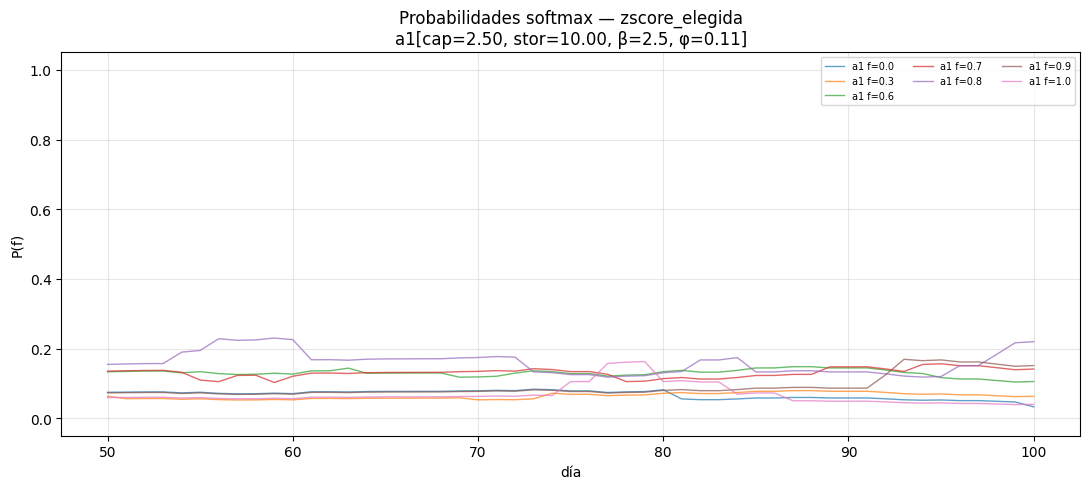

agent_id         1                                                            
f              0.0       0.3       0.6       0.7       0.8       0.9       1.0
day                                                                           
86        0.058348  0.077532  0.144562  0.122974  0.133062  0.086563  0.072808
87        0.059766  0.079416  0.148075  0.125963  0.136296  0.088667  0.050273
88        0.059804  0.079467  0.148170  0.126044  0.136383  0.088724  0.050305
89        0.058325  0.077502  0.144506  0.147652  0.133011  0.086530  0.049062
90        0.058357  0.077544  0.144585  0.147733  0.133084  0.086578  0.049088
91        0.058386  0.077582  0.144655  0.147805  0.133149  0.086620  0.049112
92        0.055960  0.074359  0.138645  0.141664  0.127616  0.124569  0.047072
93        0.053101  0.070560  0.131562  0.134426  0.121097  0.169294  0.044667
94        0.051873  0.068928  0.128519  0.154447  0.118296  0.165378  0.043634
95        0.052568  0.069852  0.116836  0.156518  0.119881  0.167595  0.044219
96        0.050720  0.067397  0.112730  0.151017  0.150815  0.161704  0.042664
97        0.050739  0.067422  0.112772  0.151073  0.150871  0.161764  0.042680
98        0.048790  0.064832  0.108440  0.145270  0.183488  0.155551  0.041041
99        0.046805  0.062194  0.104028  0.139359  0.216708  0.149222  0.039371
100       0.032837  0.063105  0.105552  0.141402  0.219884  0.151408  0.039948

In [66]:
# --- 7) Probabilidades (softmax): plot + tabla (cola) ---
plot_evolucion_probabilidades(resultado_zscore_elegida, AGENTES_ZSCORE_ELEGIDA, FRACCIONES_ZSCORE_ELEGIDA, DIAS_ZSCORE_ELEGIDA)
plt.tight_layout(); plt.show()
tabla_probabilidades(resultado_zscore_elegida, AGENTES_ZSCORE_ELEGIDA, FRACCIONES_ZSCORE_ELEGIDA, DIAS_ZSCORE_ELEGIDA).tail(15)


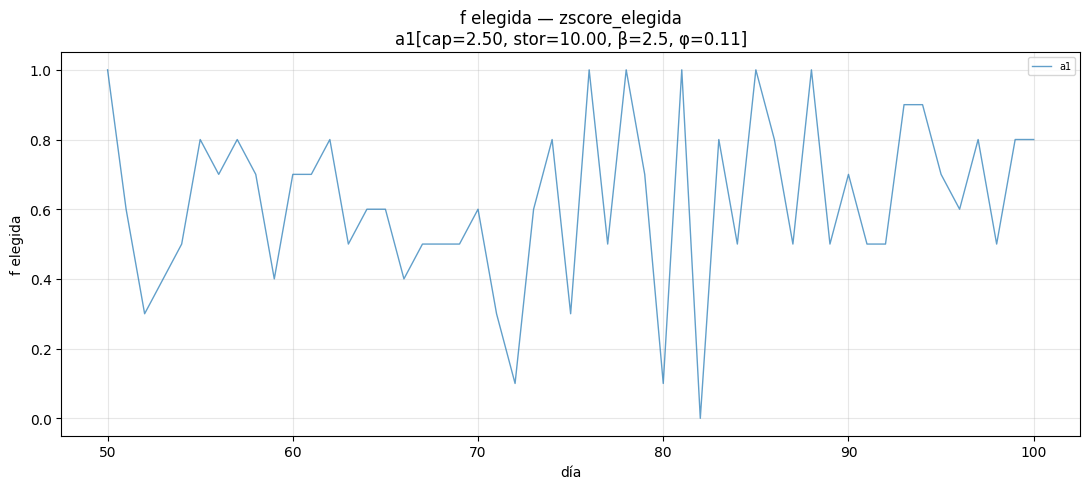

agent_id,1
day,
86.0,0.8
87.0,0.5
88.0,1.0
89.0,0.5
90.0,0.7
91.0,0.5
92.0,0.5
93.0,0.9
94.0,0.9


In [67]:
# --- 8) f elegida: plot + tabla (cola) ---
plot_evolucion_f_elegida(resultado_zscore_elegida, AGENTES_ZSCORE_ELEGIDA, DIAS_ZSCORE_ELEGIDA)
plt.tight_layout(); plt.show()
tabla_f_elegida(resultado_zscore_elegida, AGENTES_ZSCORE_ELEGIDA, DIAS_ZSCORE_ELEGIDA).tail(15)


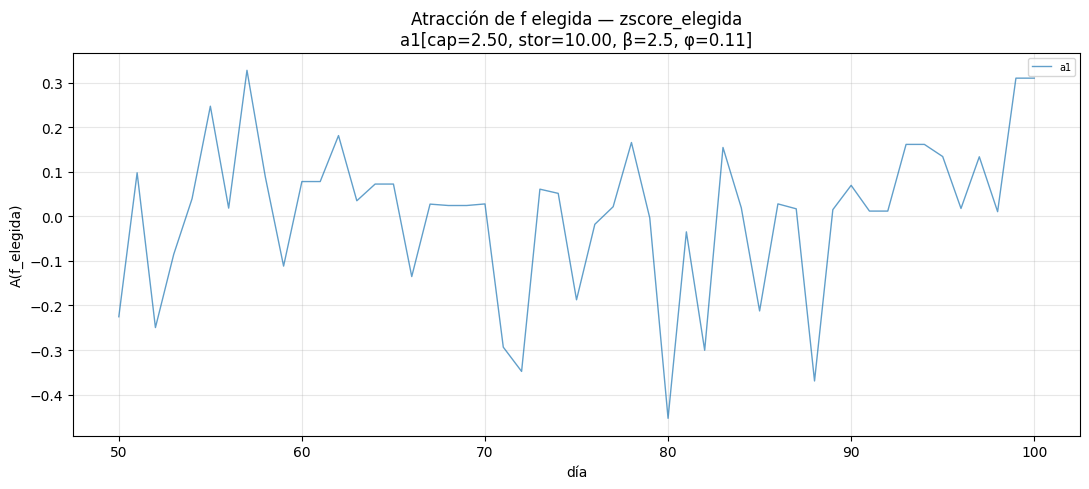

In [68]:
# --- 9) Atracción de la f elegida ---
plot_evolucion_atraccion_elegida(resultado_zscore_elegida, AGENTES_ZSCORE_ELEGIDA, DIAS_ZSCORE_ELEGIDA)
plt.tight_layout(); plt.show()


In [69]:
# --- Extras: entropía, tiempo de convergencia, profits/atracción por agente ---
print('Entropía softmax (últimos 100 días):')
display(entropia_softmax(resultado_zscore_elegida, AGENTES_ZSCORE_ELEGIDA))
print('\nTiempo hasta convergencia:')
display(tiempo_convergencia(resultado_zscore_elegida, threshold=0.05, k=20, agent_ids=AGENTES_ZSCORE_ELEGIDA))
print('\nProfits medios por agente:')
display(tabla_profits_por_agente(resultado_zscore_elegida, AGENTES_ZSCORE_ELEGIDA))
print('\nAtracción de f elegida media por agente:')
display(tabla_atraccion_elegida_por_agente(resultado_zscore_elegida, AGENTES_ZSCORE_ELEGIDA))


Entropía softmax (últimos 100 días):


,H_media,H_max,entropia_norm
agent_id,,,
1,2.207659,2.397895,0.920665



Tiempo hasta convergencia:


,f_final,t_convergencia
agent_id,,
1,0.665,None



Profits medios por agente:


,profit_medio
agent_id,
1,277.430853



Atracción de f elegida media por agente:


,atraccion_elegida_media
agent_id,
1,-0.039403


In [70]:
# --- 10) Multi-seed opcional (descomenta para ejecutar; tarda) ---
# df_ms, agg_ms = resumen_multiseed(
#     regla_zscore_elegida, params=CFG_ZSCORE_ELEGIDA['params'], seeds=range(10),
#     days=CFG_ZSCORE_ELEGIDA['days'], optimo=optimo_homogeneo, rule_name='zscore_elegida',
# )
# print('Por seed:')
# display(df_ms[['f_final', 'gap_profit_pct', 'f_std_intraday_mean', 'atraccion_elegida_media']])
# print('\nAgregada:'); display(agg_ms)


## §9 Pruebas: EWA con delta

Plantilla: 1) Config → 2) Ejecución → 3) Métricas → 4) Evolución agregada → 5) Config agentes → 6–9) Plots y tablas por agente → 10) Multi-seed (opcional).

**Importante:** las celdas 3–10 solo leen `resultado_ewa`. Cambia los filtros sin re-simular.


In [71]:
# --- 1) Config §9: edita y re-ejecuta para cambiar parametrización ---
CFG_EWA = {
    'params': {
        **PARAMS_INTERIOR,
        # Aprendizaje (override de DEFAULT_PARAMS de model.py)
        'PHI_LOW': 0.05,
        'PHI_HIGH': 0.3,
        'BETA_LOW': 2.0,
        'BETA_HIGH': 3.0,
        # Eficiencia de almacenamiento (homogénea)
        'ETA_LOW': 0.9,
        'ETA_HIGH': 0.9,
    },
    'seed': 0,
    'days': 500,
}


In [72]:
# --- 2) Ejecutar simulacion (se re-ejecuta al cambiar Config) ---
resultado_ewa = run_with_rule(
    make_regla_ewa(delta=0.5, rho=0.9, phi=0.95),
    params=CFG_EWA['params'],
    seed=CFG_EWA['seed'],
    days=CFG_EWA['days'],
    rule_name='ewa_delta',
)
print(f"OK: {resultado_ewa['rule_name']} seed={resultado_ewa['seed']} days={CFG_EWA['days']}")


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


OK: ewa_delta seed=0 days=500


In [73]:
# --- 3) Métricas fijas ---
print(f"=== Métricas — ewa_delta (seed={resultado_ewa['seed']}) ===")
_res = resumen_metricas(resultado_ewa, optimo=optimo_nash)
print_resumen(_res)


=== Métricas — ewa_delta (seed=0) ===
  rule_name                     : ewa_delta
  seed                          : 0
  days                          : 500
  f_media_temporal              :     0.4067
  f_final_avg                   :     0.4067
  f_std_de_medias               :     0.0000
  f_std_intraday_mean           :     0.3434
  f_std_temporal_mean           :     0.0000
  price_M_mean                  :    78.2469
  price_E_mean                  :   144.6239
  price_ratio_mean              :     0.5411
  price_ratio_of_means          :     0.5410
  extremos_pct                  :     0.0000
  profit_agregado_mean          :   282.8607
  atraccion_elegida_media       :   565.5505
  prob_elegida_media            :     1.0000
  prob_elegida_std              :     0.0000
  prob_elegida_var              :     0.0000
  gap_profit_pct                :    -2.8047
  gap_f_abs                     :     0.2320
  ratio_vs_optimo               :    -0.3391


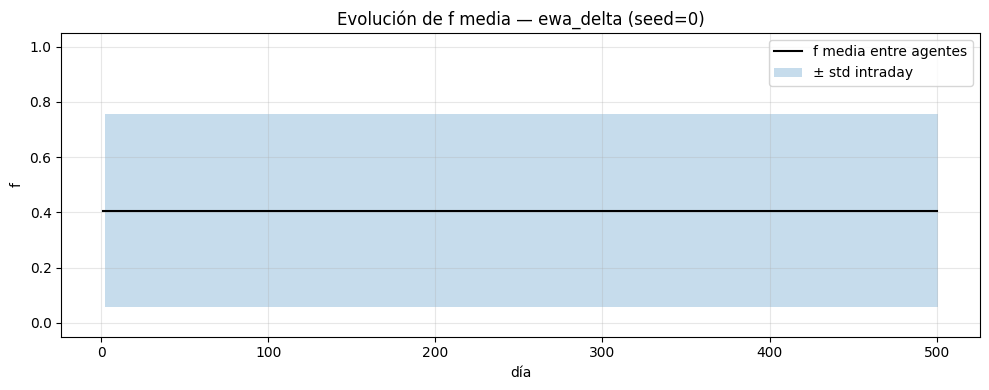

Muestra equiespaciada (21 pts) — f media entre agentes:
       f_media  f_std_intraday
day                           
1.0     0.4067             NaN
25.0    0.4067          0.3493
50.0    0.4067          0.3493
75.0    0.4067          0.3493
100.0   0.4067          0.3493
125.0   0.4067          0.3493
150.0   0.4067          0.3493
175.0   0.4067          0.3493
200.0   0.4067          0.3493
225.0   0.4067          0.3493
250.0   0.4067          0.3493
275.0   0.4067          0.3493
300.0   0.4067          0.3493
325.0   0.4067          0.3493
350.0   0.4067          0.3493
375.0   0.4067          0.3493
400.0   0.4067          0.3493
425.0   0.4067          0.3493
450.0   0.4067          0.3493
475.0   0.4067          0.3493
500.0   0.4067          0.3493

Cola (últimos 10 días):
       f_media  f_std_intraday
day                           
491.0   0.4067          0.3493
492.0   0.4067          0.3493
493.0   0.4067          0.3493
494.0   0.4067          0.3493
495.0   0.4067      

In [74]:
# --- 4) Evolución agregada (f media ± std intraday) ---
plot_evolucion_f_media(resultado_ewa)
plt.tight_layout(); plt.show()

print_evolucion_f_media(resultado_ewa)


In [75]:
# --- 5) Agentes y filtros para las vistas detalladas (edita y re-ejecuta sin re-simular) ---
AGENTES_EWA_DELTA = seleccionar_agentes_diversos(resultado_ewa['model'], n=1)
FRACCIONES_EWA_DELTA = None   # None = todas; o p.ej. [0.0, 0.3, 0.6, 0.9]
DIAS_EWA_DELTA = None   # None = todo; o p.ej. (400, 500)

print('Agentes seleccionados:')
ficha_agentes(resultado_ewa['model'], AGENTES_EWA_DELTA)


Agentes seleccionados:


,capacity,storage_capacity,eta,phi,beta
agent_id,,,,,
1,2.5,10.0,0.9,0.114729,2.511275


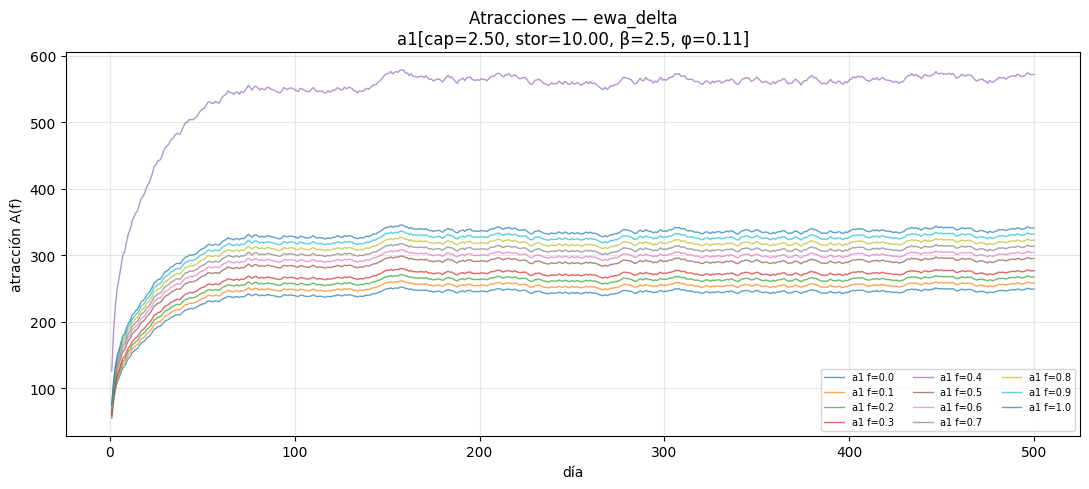

agent_id           1                                                                                                              \
f                0.0         0.1         0.2         0.3         0.4         0.5         0.6         0.7         0.8         0.9   
day                                                                                                                                
486       247.001028  256.142736  265.284444  274.426152  567.135720  292.709568  301.851276  310.992984  320.134692  329.276400   
487       247.367600  256.534481  265.701363  274.868245  568.070252  293.202008  302.368889  311.535771  320.702652  329.869534   
488       248.033551  257.194766  266.355982  275.517197  569.356825  293.839628  303.000844  312.162059  321.323275  330.484490   
489       248.208156  257.361405  266.514655  275.667904  569.642306  293.974402  303.127651  312.280900  321.434150  330.587399   
490       247.756965  256.887258  266.017550  275.147843  568.556271  293.408428  302.538721  311.669013  320.799306  329.929599   
491       249.122442  258.324336  267.526230  276.728124  571.860036  295.131912  304.333806  313.535700  322.737594  331.939487   
492       248.765278  257.943371  267.121464  276.299556  570.955298  294.655741  303.833834  313.011927  322.190019  331.368112   
493       247.587884  256.709227  265.830571  274.951915  568.146517  293.194603  302.315946  311.437290  320.558634  329.679978   
494       247.854651  257.009383  266.164115  275.318847  568.947157  293.628311  302.783043  311.937775  321.092507  330.247239   
495       248.112070  257.260205  266.408341  275.556477  569.409224  293.852748  303.000883  312.149019  321.297155  330.445290   
496       249.706118  258.916039  268.125961  277.335882  573.091606  295.755724  304.965646  314.175567  323.385488  332.595409   
497       250.030913  259.265999  268.501086  277.736172  573.942517  296.206345  305.441431  314.676517  323.911604  333.146690   
498       248.931889  258.100011  267.268133  276.436254  571.208752  294.772498  303.940620  313.108742  322.276863  331.444985   
499       249.009685  258.202017  267.394349  276.586681  571.558026  294.971345  304.163677  313.356009  322.548341  331.740672   
500       248.936718  258.117436  267.298155  276.478873  571.319183  294.840310  304.021028  313.201746  322.382465  331.563183   

agent_id              
f                1.0  
day                   
486       338.418108  
487       339.036416  
488       339.645706  
489       339.740648  
490       339.059891  
491       341.141381  
492       340.546204  
493       338.801321  
494       339.401971  
495       339.593426  
496       341.805331  
497       342.381776  
498       340.613107  
499       340.933004  
500       340.743902

In [76]:
# --- 6) Atracciones: plot + tabla (cola) ---
plot_evolucion_atracciones(resultado_ewa, AGENTES_EWA_DELTA, FRACCIONES_EWA_DELTA, DIAS_EWA_DELTA)
plt.tight_layout(); plt.show()
tabla_atracciones(resultado_ewa, AGENTES_EWA_DELTA, FRACCIONES_EWA_DELTA, DIAS_EWA_DELTA).tail(15)


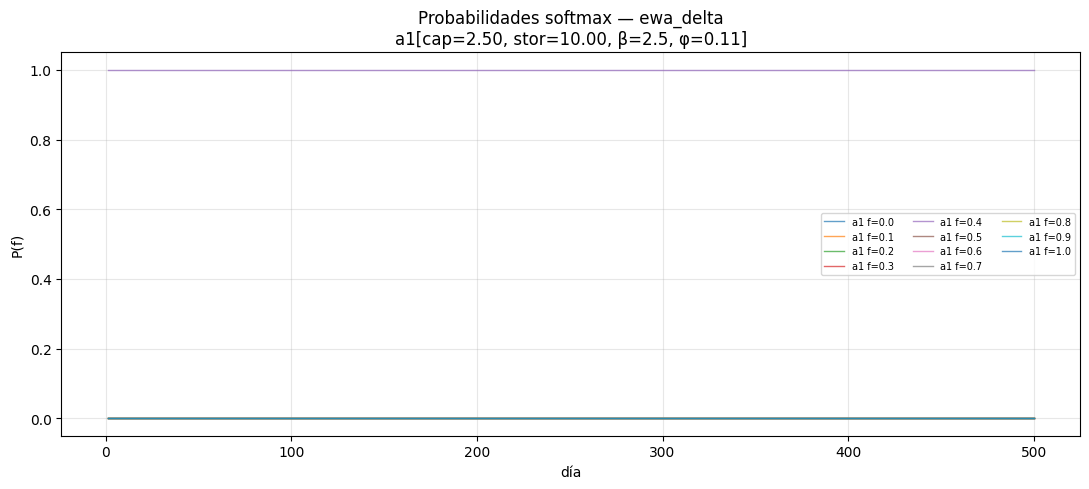

agent_id    1                                                                                                                        
f         0.0  0.1  0.2            0.3  0.4            0.5            0.6            0.7            0.8            0.9            1.0
day                                                                                                                                  
486       0.0  0.0  0.0  5.772169e-320  1.0  5.033266e-300  4.699980e-290  4.388764e-280  4.098155e-270  3.826790e-260  3.573393e-250
487       0.0  0.0  0.0  1.675871e-320  1.0  1.658400e-300  1.649646e-290  1.640937e-280  1.632275e-270  1.623658e-260  1.615087e-250
488       0.0  0.0  0.0  3.379409e-321  1.0  3.250278e-301  3.187441e-291  3.125820e-281  3.065389e-271  3.006127e-261  2.948011e-251
489       0.0  0.0  0.0  2.411040e-321  1.0  2.226153e-301  2.139875e-291  2.056940e-281  1.977220e-271  1.900590e-261  1.826929e-251
490       0.0  0.0  0.0  9.980126e-321  1.0  8.217700e-301  7.456696e-291  6.766165e-281  6.139582e-271  5.571023e-261  5.055116e-251
491       0.0  0.0  0.0  1.333977e-322  1.0  1.553259e-302  1.687061e-292  1.832389e-282  1.990236e-272  2.161680e-262  2.347893e-252
492       0.0  0.0  0.0  4.347778e-322  1.0  4.556738e-302  4.662110e-292  4.769918e-282  4.880219e-272  4.993071e-262  5.108532e-252
493       0.0  0.0  0.0  1.707491e-320  1.0  1.344113e-300  1.192538e-290  1.058055e-280  9.387385e-271  8.328771e-261  7.389537e-251
494       0.0  0.0  0.0  5.745983e-321  1.0  5.348697e-301  5.160581e-291  4.979081e-281  4.803965e-271  4.635008e-261  4.471993e-251
495       0.0  0.0  0.0  3.270715e-321  1.0  2.944971e-301  2.794714e-291  2.652124e-281  2.516808e-271  2.388397e-261  2.266537e-251
496       0.0  0.0  0.0  2.964394e-323  1.0  3.376007e-303  3.741494e-293  4.146550e-283  4.595457e-273  5.092962e-263  5.644328e-253
497       0.0  0.0  0.0  9.881313e-324  1.0  1.235475e-303  1.458551e-293  1.721905e-283  2.032810e-273  2.399852e-263  2.833167e-253
498       0.0  0.0  0.0  3.260833e-322  1.0  3.232709e-302  3.225674e-292  3.218655e-282  3.211651e-272  3.204662e-262  3.197689e-252
499       0.0  0.0  0.0  1.976263e-322  1.0  2.215676e-302  2.349441e-292  2.491281e-282  2.641685e-272  2.801168e-262  2.970280e-252
500       0.0  0.0  0.0  2.717361e-322  1.0  2.904593e-302  2.991421e-292  3.080844e-282  3.172940e-272  3.267789e-262  3.365473e-252

In [77]:
# --- 7) Probabilidades (softmax): plot + tabla (cola) ---
plot_evolucion_probabilidades(resultado_ewa, AGENTES_EWA_DELTA, FRACCIONES_EWA_DELTA, DIAS_EWA_DELTA)
plt.tight_layout(); plt.show()
tabla_probabilidades(resultado_ewa, AGENTES_EWA_DELTA, FRACCIONES_EWA_DELTA, DIAS_EWA_DELTA).tail(15)


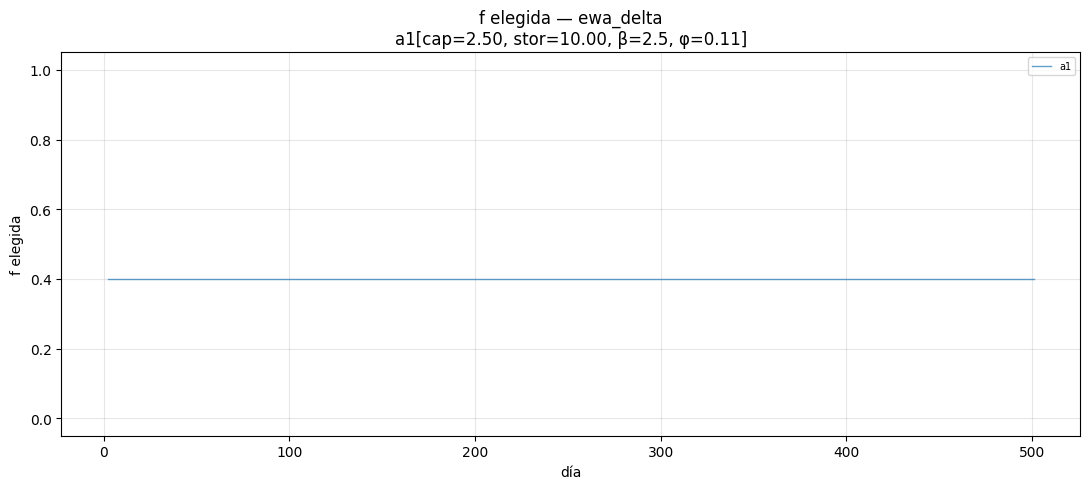

agent_id,1
day,
487.0,0.4
488.0,0.4
489.0,0.4
490.0,0.4
491.0,0.4
492.0,0.4
493.0,0.4
494.0,0.4
495.0,0.4


In [78]:
# --- 8) f elegida: plot + tabla (cola) ---
plot_evolucion_f_elegida(resultado_ewa, AGENTES_EWA_DELTA, DIAS_EWA_DELTA)
plt.tight_layout(); plt.show()
tabla_f_elegida(resultado_ewa, AGENTES_EWA_DELTA, DIAS_EWA_DELTA).tail(15)


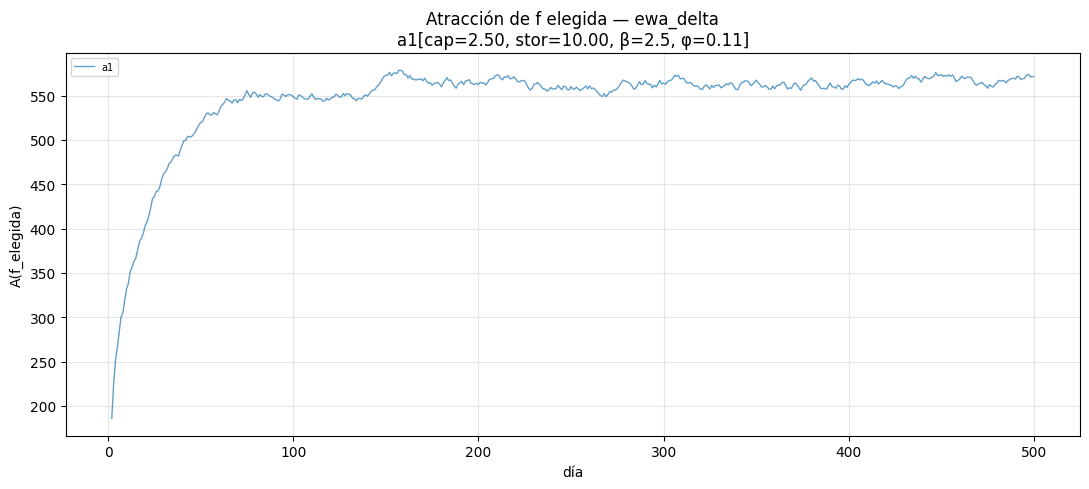

In [79]:
# --- 9) Atracción de la f elegida ---
plot_evolucion_atraccion_elegida(resultado_ewa, AGENTES_EWA_DELTA, DIAS_EWA_DELTA)
plt.tight_layout(); plt.show()


In [80]:
# --- Extras: entropía, tiempo de convergencia, profits/atracción por agente ---
print('Entropía softmax (últimos 100 días):')
display(entropia_softmax(resultado_ewa, AGENTES_EWA_DELTA))
print('\nTiempo hasta convergencia:')
display(tiempo_convergencia(resultado_ewa, threshold=0.05, k=20, agent_ids=AGENTES_EWA_DELTA))
print('\nProfits medios por agente:')
display(tabla_profits_por_agente(resultado_ewa, AGENTES_EWA_DELTA))
print('\nAtracción de f elegida media por agente:')
display(tabla_atraccion_elegida_por_agente(resultado_ewa, AGENTES_EWA_DELTA))


Entropía softmax (últimos 100 días):


,H_media,H_max,entropia_norm
agent_id,,,
1,0.0,2.397895,0.0



Tiempo hasta convergencia:


,f_final,t_convergencia
agent_id,,
1,0.4,2



Profits medios por agente:


,profit_medio
agent_id,
1,284.393692



Atracción de f elegida media por agente:


,atraccion_elegida_media
agent_id,
1,567.202146


In [81]:
# --- 10) Multi-seed opcional (descomenta para ejecutar; tarda) ---
# df_ms, agg_ms = resumen_multiseed(
#     make_regla_ewa(delta=0.5, rho=0.9), params=CFG_EWA['params'], seeds=range(10),
#     days=CFG_EWA['days'], optimo=optimo_homogeneo, rule_name='ewa_delta',
# )
# print('Por seed:')
# display(df_ms[['f_final', 'gap_profit_pct', 'f_std_intraday_mean', 'atraccion_elegida_media']])
# print('\nAgregada:'); display(agg_ms)


## §10 Pruebas: EWA con z-score

Mismo esqueleto que §9 pero con la senal z-score sobre los contrafactuales. Esperamos:
- El "foso" 1 vs delta deja de pesar el NIVEL absoluto de pi (~180) y pasa a pesar diferencias normalizadas (z en [-2, +2] aprox), eliminando el lock-in mecanico.
- Convergencia comparable a las reglas cf_zscore / zscore_elegida.

**Importante:** las celdas 3-10 solo leen `resultado_ewa_zs`. Cambia los filtros sin re-simular.


In [82]:
# --- 1) Config §10: edita y re-ejecuta para cambiar parametrización ---
CFG_EWA_ZS = {
    'params': {
        **PARAMS_INTERIOR,
        # Aprendizaje (override de DEFAULT_PARAMS de model.py)
        'PHI_LOW': 0.05,
        'PHI_HIGH': 0.3,
        'BETA_LOW': 2.0,
        'BETA_HIGH': 3.0,
        # Eficiencia de almacenamiento (homogénea)
        'ETA_LOW': 0.9,
        'ETA_HIGH': 0.9,
    },
    'seed': 0,
    'days': 500,
}


In [83]:
# --- 2) Ejecutar simulación (se re-ejecuta al cambiar Config) ---
resultado_ewa_zs = run_with_rule(
    make_regla_ewa_zscore(delta=0.5, rho=0.9, phi=0.95),
    params=CFG_EWA_ZS['params'],
    seed=CFG_EWA_ZS['seed'],
    days=CFG_EWA_ZS['days'],
    rule_name='ewa_zscore',
)
print(f"OK: {resultado_ewa_zs['rule_name']} seed={resultado_ewa_zs['seed']} days={CFG_EWA_ZS['days']}")


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


OK: ewa_zscore seed=0 days=500


In [84]:
# --- 3) Métricas fijas ---
print(f"=== Métricas — ewa_zscore (seed={resultado_ewa_zs['seed']}) ===")
_res = resumen_metricas(resultado_ewa_zs, optimo=optimo_nash)
print_resumen(_res)


=== Métricas — ewa_zscore (seed=0) ===
  rule_name                     : ewa_zscore
  seed                          : 0
  days                          : 500
  f_media_temporal              :     0.6381
  f_final_avg                   :     0.6533
  f_std_de_medias               :     0.0607
  f_std_intraday_mean           :     0.2885
  f_std_temporal_mean           :     0.2943
  price_M_mean                  :   104.6403
  price_E_mean                  :   118.8642
  price_ratio_mean              :     0.8866
  price_ratio_of_means          :     0.8803
  extremos_pct                  :     0.0000
  profit_agregado_mean          :   274.0208
  atraccion_elegida_media       :     0.0728
  prob_elegida_media            :     0.1111
  prob_elegida_std              :     0.0537
  prob_elegida_var              :     0.0029
  gap_profit_pct                :     0.4081
  gap_f_abs                     :     0.0146
  ratio_vs_optimo               :     0.0064


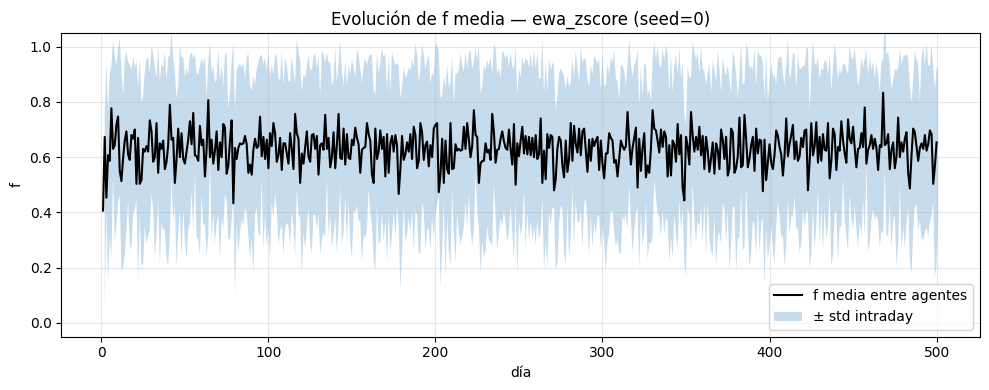

Muestra equiespaciada (21 pts) — f media entre agentes:
       f_media  f_std_intraday
day                           
1.0     0.4067             NaN
25.0    0.6300          0.3041
50.0    0.5767          0.2959
75.0    0.5400          0.2677
100.0   0.5600          0.3168
125.0   0.5833          0.3157
150.0   0.6633          0.3610
175.0   0.6200          0.2750
200.0   0.7167          0.3090
225.0   0.6733          0.2722
250.0   0.6033          0.2713
275.0   0.6600          0.2477
300.0   0.5767          0.3092
325.0   0.6867          0.3078
350.0   0.6733          0.2750
375.0   0.5333          0.2612
400.0   0.6467          0.2952
425.0   0.7233          0.3374
450.0   0.7100          0.3060
475.0   0.5600          0.2636
500.0   0.6533          0.3517

Cola (últimos 10 días):
       f_media  f_std_intraday
day                           
491.0   0.6500          0.3241
492.0   0.6300          0.3511
493.0   0.6800          0.3030
494.0   0.6233          0.3336
495.0   0.6467      

In [85]:
# --- 4) Evolución agregada (f media ± std intraday) ---
plot_evolucion_f_media(resultado_ewa_zs)
plt.tight_layout(); plt.show()

print_evolucion_f_media(resultado_ewa_zs)


In [86]:
# --- 5) Agentes y filtros para las vistas detalladas (edita y re-ejecuta sin re-simular) ---

AGENTES_EWA_ZS = seleccionar_agentes_diversos(resultado_ewa_zs['model'], n=1)
FRACCIONES_EWA_ZS = [0.0, 0.3, 0.6, 0.7, 0.8, 0.9, 1]  # None = todas; o p.ej. [0.0, 0.3, 0.6, 0.9]
DIAS_EWA_ZS = (450,500)   # None = todo; o p.ej. (400, 500)

print('Agentes seleccionados:')
ficha_agentes(resultado_ewa_zs['model'], AGENTES_EWA_ZS)


Agentes seleccionados:


,capacity,storage_capacity,eta,phi,beta
agent_id,,,,,
1,2.5,10.0,0.9,0.114729,2.511275


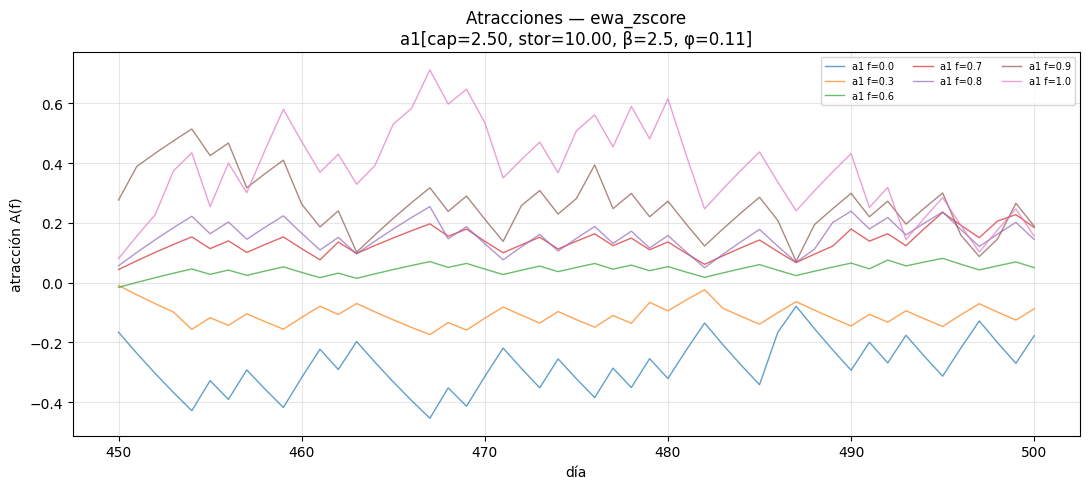

agent_id         1                                                            
f              0.0       0.3       0.6       0.7       0.8       0.9       1.0
day                                                                           
486      -0.166291 -0.100352  0.041323  0.103803  0.121575  0.207881  0.335996
487      -0.078919 -0.063711  0.023446  0.066990  0.068062  0.070996  0.240139
488      -0.154030 -0.092149  0.038085  0.095263  0.112093  0.193937  0.307189
489      -0.225386 -0.119164  0.051992  0.122123  0.201357  0.247486  0.370887
490      -0.293173 -0.144829  0.065204  0.179262  0.238723  0.298357  0.431399
491      -0.199458 -0.105964  0.046132  0.138676  0.179353  0.220194  0.251715
492      -0.268542 -0.132289  0.075448  0.163365  0.217819  0.272430  0.318187
493      -0.176058 -0.094052  0.055865  0.123574  0.159494  0.195563  0.144163
494      -0.246312 -0.120972  0.068883  0.180641  0.198954  0.249030  0.216012
495      -0.313053 -0.146546  0.081250  0.234855  0.236440  0.299824  0.284269
496      -0.218343 -0.107596  0.061376  0.191489  0.177184  0.158342  0.190998
497      -0.128369 -0.070593  0.042496  0.150292  0.120891  0.087179  0.102391
498      -0.201008 -0.098687  0.056182  0.206023  0.162280  0.146066  0.176329
499      -0.270014 -0.125375  0.069185  0.227344  0.201600  0.265254  0.246569
500      -0.177457 -0.087483  0.049914  0.184354  0.144086  0.188745  0.155184

In [87]:
# --- 6) Atracciones: plot + tabla (cola) ---
plot_evolucion_atracciones(resultado_ewa_zs, AGENTES_EWA_ZS, FRACCIONES_EWA_ZS, DIAS_EWA_ZS)
plt.tight_layout(); plt.show()
tabla_atracciones(resultado_ewa_zs, AGENTES_EWA_ZS, FRACCIONES_EWA_ZS, DIAS_EWA_ZS).tail(15)


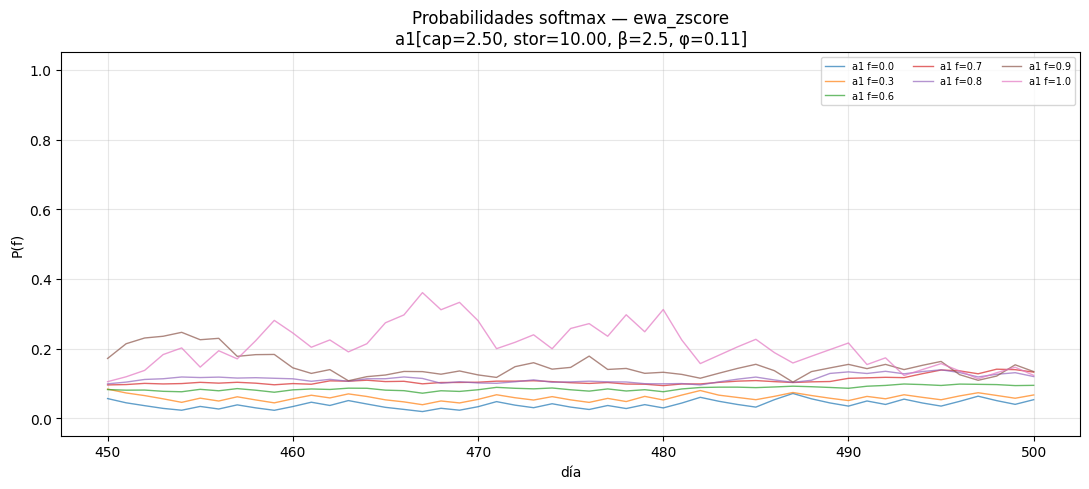

agent_id         1                                                            
f              0.0       0.3       0.6       0.7       0.8       0.9       1.0
day                                                                           
486       0.053393  0.063008  0.089932  0.105210  0.110012  0.136637  0.188492
487       0.071239  0.074013  0.092122  0.102767  0.103044  0.103806  0.158743
488       0.055934  0.065338  0.090616  0.104608  0.109124  0.134024  0.178114
489       0.044095  0.057576  0.088493  0.105535  0.128769  0.144585  0.197110
490       0.035024  0.050834  0.086143  0.114714  0.133188  0.154705  0.216075
491       0.049676  0.062822  0.092043  0.116125  0.128614  0.142505  0.154244
492       0.039760  0.055983  0.094323  0.117626  0.134863  0.154687  0.173523
493       0.054973  0.067544  0.098421  0.116663  0.127676  0.139781  0.122854
494       0.043851  0.060073  0.096770  0.128124  0.134153  0.152131  0.140025
495       0.035008  0.053182  0.094234  0.138591  0.139144  0.163152  0.156902
496       0.048626  0.064217  0.098161  0.136096  0.131293  0.125225  0.135928
497       0.063453  0.073361  0.097455  0.127752  0.118660  0.109028  0.113273
498       0.050697  0.065551  0.096713  0.140898  0.126240  0.121203  0.130773
499       0.040034  0.057568  0.093837  0.139594  0.130854  0.153536  0.146498
500       0.053422  0.066965  0.094557  0.132532  0.119785  0.134001  0.123170

In [88]:
# --- 7) Probabilidades (softmax): plot + tabla (cola) ---
plot_evolucion_probabilidades(resultado_ewa_zs, AGENTES_EWA_ZS, FRACCIONES_EWA_ZS, DIAS_EWA_ZS)
plt.tight_layout(); plt.show()
tabla_probabilidades(resultado_ewa_zs, AGENTES_EWA_ZS, FRACCIONES_EWA_ZS, DIAS_EWA_ZS).tail(15)


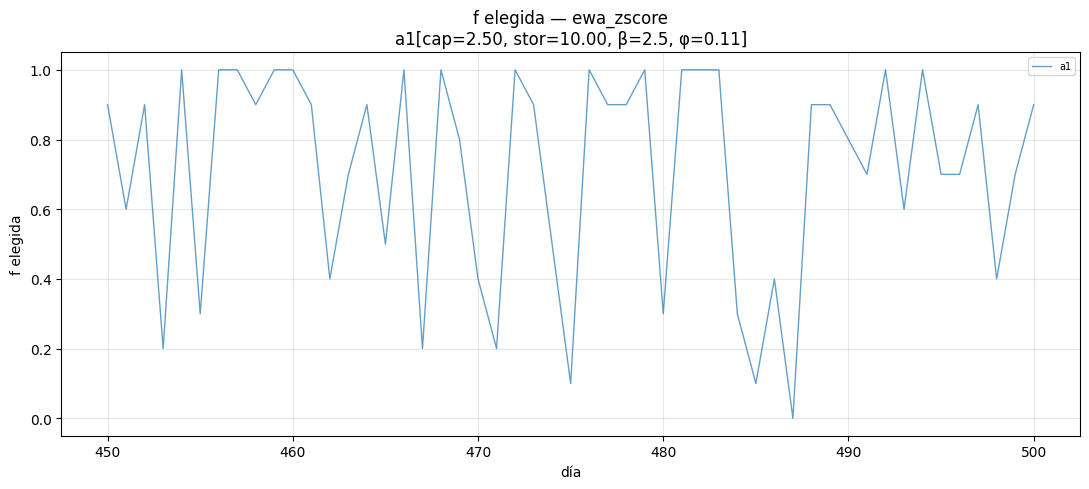

agent_id,1
day,
486.0,0.4
487.0,0.0
488.0,0.9
489.0,0.9
490.0,0.8
491.0,0.7
492.0,1.0
493.0,0.6
494.0,1.0


In [89]:
# --- 8) f elegida: plot + tabla (cola) ---
plot_evolucion_f_elegida(resultado_ewa_zs, AGENTES_EWA_ZS, DIAS_EWA_ZS)
plt.tight_layout(); plt.show()
tabla_f_elegida(resultado_ewa_zs, AGENTES_EWA_ZS, DIAS_EWA_ZS).tail(15)


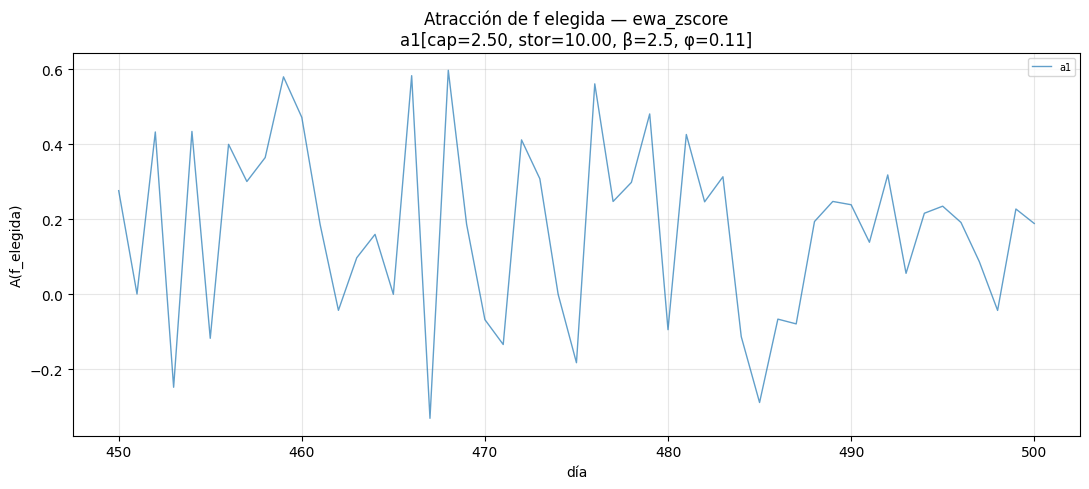

In [90]:
# --- 9) Atracción de la f elegida ---
plot_evolucion_atraccion_elegida(resultado_ewa_zs, AGENTES_EWA_ZS, DIAS_EWA_ZS)
plt.tight_layout(); plt.show()


In [91]:
# --- Extras: entropía, tiempo de convergencia, profits/atracción por agente ---
print('Entropía softmax (últimos 100 días):')
display(entropia_softmax(resultado_ewa_zs, AGENTES_EWA_ZS))
print('\nTiempo hasta convergencia:')
display(tiempo_convergencia(resultado_ewa_zs, threshold=0.05, k=20, agent_ids=AGENTES_EWA_ZS))
print('\nProfits medios por agente:')
display(tabla_profits_por_agente(resultado_ewa_zs, AGENTES_EWA_ZS))
print('\nAtracción de f elegida media por agente:')
display(tabla_atraccion_elegida_por_agente(resultado_ewa_zs, AGENTES_EWA_ZS))


Entropía softmax (últimos 100 días):


,H_media,H_max,entropia_norm
agent_id,,,
1,2.273632,2.397895,0.948178



Tiempo hasta convergencia:


,f_final,t_convergencia
agent_id,,
1,0.67,None



Profits medios por agente:


,profit_medio
agent_id,
1,277.138558



Atracción de f elegida media por agente:


,atraccion_elegida_media
agent_id,
1,0.104345


In [92]:
# --- 10) Multi-seed opcional (descomenta para ejecutar; tarda) ---
# df_ms, agg_ms = resumen_multiseed(
#     make_regla_ewa_zscore(delta=0.5, rho=0.9, phi=0.95), params=CFG_EWA_ZS['params'], seeds=range(10),
#     days=CFG_EWA_ZS['days'], optimo=optimo_homogeneo, rule_name='ewa_zscore',
# )
# print('Por seed:')
# display(df_ms[['f_final', 'gap_profit_pct', 'f_std_intraday_mean', 'atraccion_elegida_media']])
# print('\nAgregada:'); display(agg_ms)


## §11 Comparativa cross-rule

Tabla con una fila por regla, todas corridas con la misma seed y params. Para que funcione, las secciones §6–§10 deben haberse ejecutado antes.


In [93]:
# Comparativa de §4.3: las configuraciones del capitulo (mismas columnas que la tabla).
# cf_raw se incluye en sus dos regimenes de beta: operacion (ciclo) y beta=0.2 (palanca de escala).
# ewa_delta (EWA cruda, congelada) se conserva como referencia, fuera de la tabla del capitulo.
resultado_cf_raw_b02 = run_with_rule(
    regla_cf_raw,
    params={**CFG_CF_RAW['params'], 'BETA_LOW': 0.2, 'BETA_HIGH': 0.2},
    seed=CFG_CF_RAW['seed'], days=CFG_CF_RAW['days'], rule_name='cf_raw_b02',
)

_reglas_resultados = [
    ('cf_raw', resultado_cf_raw),
    ('cf_raw_b02', resultado_cf_raw_b02),
    ('cf_zscore', resultado_cf_zscore),
    ('ewa_zscore', resultado_ewa_zs),
    ('zscore_elegida', resultado_zscore_elegida),
    ('ewa_delta', resultado_ewa),
]

_filas = []
for name, res in _reglas_resultados:
    metr = resumen_metricas(res, optimo=optimo_nash)
    try:
        ent = float(entropia_softmax(res)['entropia_norm'].mean())
    except Exception:
        ent = np.nan
    _filas.append({
        'regla': name,
        'f_media': metr['f_media_temporal'],
        'std_temporal': metr['f_std_de_medias'],
        'std_intradia': metr['f_std_intraday_mean'],
        'gap_profit_pct': metr['gap_profit_pct'],
        'price_ratio_mean': metr['price_ratio_mean'],
        'dias_extremos_pct': metr['extremos_pct'],
        'entropia_norm': ent,
        'atraccion_elegida_media': metr['atraccion_elegida_media'],
        'ratio_vs_nash': metr['ratio_vs_optimo'],
    })

comparativa = pd.DataFrame(_filas).set_index('regla')
comparativa


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


,f_media,std_temporal,std_intradia,gap_profit_pct,price_ratio_mean,dias_extremos_pct,entropia_norm,atraccion_elegida_media,ratio_vs_nash
regla,,,,,,,,,
cf_raw,0.627033,3.803209e-01,0.186825,17.630973,1.104892,60.6,0.221644,286.003175,0.224742
cf_raw_b02,0.630033,7.650925e-02,0.292007,0.356625,0.875457,0.0,0.951987,276.374904,-0.004694
cf_zscore,0.622067,9.859995e-02,0.290148,0.525627,0.867116,0.0,0.945615,0.065996,-0.013035
ewa_zscore,0.638067,6.073106e-02,0.288465,0.408140,0.886553,0.0,0.951039,0.072824,0.006402
zscore_elegida,0.632833,4.430043e-02,0.235853,-0.015896,0.874404,0.0,0.858879,0.013896,-0.005746
ewa_delta,0.406667,5.551115e-17,0.343447,-2.804691,0.541061,0.0,0.000000,565.550505,-0.339089


## §12 Experimentos de diagnóstico (notas al pie del cap. 4)

Reproducen las afirmaciones que el capítulo remite al "material complementario": la señal siempre apunta a una esquina (`[^reparto]`), el perfil esquina-vs-interior (§4.2.3), la fijación de la regla cruda (`[^fijacion]`), el papel del decaimiento (`[^decayinterior]`) y por qué no se rescata la regla cruda rebajando β ni inicializando en el Nash (`[^initraw]`). Parametrización INTERIOR, seed=0, reutilizando `pi_all_dict` / `stable_softmax` / las reglas de §5.

In [94]:
# Reglas extra para los experimentos (las 5 principales estan en §5) + runner de diagnostico
def regla_raw_elegida(agent, profit):
    """Refuerzo clasico: senal = beneficio realizado SIN normalizar, solo la fraccion jugada."""
    f = agent.last_choice
    agent.attract[f] = (1 - agent.phi) * agent.attract[f] + agent.phi * profit


def regla_zscore_elegida_decay(agent, profit):
    """Como regla_zscore_elegida pero CON decaimiento (1-phi) tambien en las no jugadas."""
    pi_arr = np.array(list(pi_all_dict(agent).values()))
    mean_pi, std_pi = pi_arr.mean(), pi_arr.std()
    if std_pi < 1e-8:
        return
    z = (profit - mean_pi) / std_pi
    ch = agent.last_choice
    for f in agent.fractions:
        agent.attract[f] = (1 - agent.phi) * agent.attract[f] + (agent.phi * z if abs(f - ch) < 1e-9 else 0.0)


def diag_run(rule_fn, beta=None, init=None, init_peak=None, seed=0, days=500, last=100, skip=100):
    """Corre rule_fn (monkey-patch) con init/beta configurables; devuelve diagnosticos del cap. 4.
    init: None = natural U(-0.1,0.1) | 'flat' = escala-beneficio uniforme | 'peak' = bump en init_peak.
    beta: None usa el rango operativo de CFG_CF_RAW (heterogeneo [2,3]); un escalar lo fija homogeneo."""
    params = dict(CFG_CF_RAW['params'])
    if beta is not None:
        params = {**params, 'BETA_LOW': beta, 'BETA_HIGH': beta}
    original = SolarAgent.update_learning
    try:
        m = MarketModel(params=params, storage_enabled=True, seed=seed)
        fr = m.agents[0].fractions
        if init == 'flat':
            for a in m.agents:
                for f in fr:
                    a.attract[f] = 230.0 + np.random.uniform(-0.1, 0.1)
        elif init == 'peak':
            for a in m.agents:
                for f in fr:
                    a.attract[f] = 250.0 - 200.0 * abs(f - init_peak)

        def patched(self, profit):
            self.profit = profit
            if not self.storage_enabled:
                return
            rule_fn(self, profit)
        SolarAgent.update_learning = patched

        fmean = []; acc = np.zeros(len(fr)); na = 0; H = []
        n_f1 = n_int = tot = 0
        for d in range(days):
            m.step_day()
            fmean.append(np.mean([a.last_choice for a in m.agents]))
            if d >= skip:
                for a in m.agents:
                    arr = np.array([pi_all_dict(a)[f] for f in fr])
                    fm = fr[int(arr.argmax())]; tot += 1
                    if fm > 0.95:
                        n_f1 += 1
                    elif 0.05 <= fm <= 0.95:
                        n_int += 1
            if d >= days - last:
                for a in m.agents:
                    p = stable_softmax(np.array([a.attract[f] for f in fr]), a.beta)
                    acc += p; na += 1
                    pc = np.clip(p, 1e-12, 1.0)
                    H.append(float(-(pc * np.log(pc)).sum() / np.log(len(fr))))
        prof = acc / na
        return {
            'f_med': float(np.mean(fmean[-last:])),
            'std_temp': float(np.std(fmean[-last:])),
            'entropia': float(np.mean(H)),
            'moda': float(fr[int(prof.argmax())]),
            'P_f1': float(prof[-1]),
            'argmax_esquina_pct': 100.0 * n_f1 / tot if tot else float('nan'),
            'argmax_interior_pct': 100.0 * n_int / tot if tot else float('nan'),
            'perfil': prof, 'fracciones': fr,
        }
    finally:
        SolarAgent.update_learning = original

In [95]:
# §12.1 — La senal apunta SIEMPRE a una esquina (nota [^reparto]).
# El argmax del contrafactual de cada agente cae en f=0 o f=1; en 0% de los dias es interior.
# El reparto entre esquinas depende de la regla (la media ~0.63 es identica), no su naturaleza.
_rep = []
for nombre, regla in [('cf_raw (ciclo)', regla_cf_raw),
                      ('cf_zscore (todas)', regla_cf_zscore),
                      ('zscore_elegida', regla_zscore_elegida)]:
    r = diag_run(regla)
    _rep.append({'regla': nombre,
                 'argmax f=1 (%)': round(r['argmax_esquina_pct'], 1),
                 'argmax interior (%)': round(r['argmax_interior_pct'], 2)})
pd.DataFrame(_rep).set_index('regla')

C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


,argmax f=1 (%),argmax interior (%)
regla,,
cf_raw (ciclo),49.8,0.0
cf_zscore (todas),58.0,0.0
zscore_elegida,63.5,0.0


C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


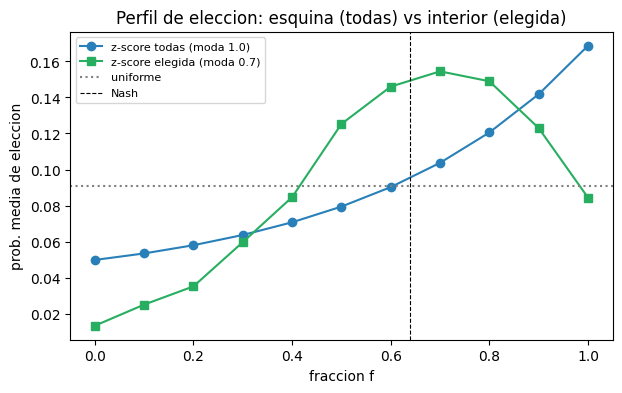

P(f=1): z-todas=0.169  elegida=0.084  uniforme=0.091


In [96]:
# §12.2 — Perfil de eleccion poblacional (cola): la que actualiza todas tiene su moda en la
# esquina (perfil creciente); la elegida forma una joroba interior con moda ~0.7 (nota §4.2.3).
_pz = diag_run(regla_cf_zscore)
_pe = diag_run(regla_zscore_elegida)
fr = _pe['fracciones']
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fr, _pz['perfil'], 'o-', color='#2980b9', label=f"z-score todas (moda {_pz['moda']:.1f})")
ax.plot(fr, _pe['perfil'], 's-', color='#27ae60', label=f"z-score elegida (moda {_pe['moda']:.1f})")
ax.axhline(1 / len(fr), ls=':', color='gray', label='uniforme')
ax.axvline(0.639, ls='--', color='k', lw=0.8, label='Nash')
ax.set_xlabel('fraccion f'); ax.set_ylabel('prob. media de eleccion')
ax.set_title('Perfil de eleccion: esquina (todas) vs interior (elegida)'); ax.legend(fontsize=8)
plt.show()
print(f"P(f=1): z-todas={_pz['P_f1']:.3f}  elegida={_pe['P_f1']:.3f}  uniforme={1/len(fr):.3f}")

In [97]:
# §12.3 — El decaimiento es co-responsable de la preferencia interior (nota [^decayinterior]).
# Anadir decay a la elegida, o usar EWA delta=0 (z-score, solo la jugada, pero con la depreciacion
# propia de la EWA), desplaza la moda de 0.7 a la esquina f=1 pese a conservar el z-score.
_dec = []
for nombre, regla in [('z-score elegida (sin decay)', regla_zscore_elegida),
                      ('z-score elegida + decay', regla_zscore_elegida_decay),
                      ('EWA z-score, delta=0', make_regla_ewa_zscore(delta=0.0))]:
    r = diag_run(regla)
    _dec.append({'regla': nombre, 'moda': r['moda'],
                 'f_med': round(r['f_med'], 2), 'entropia': round(r['entropia'], 3)})
pd.DataFrame(_dec).set_index('regla')

,moda,f_med,entropia
regla,,,
z-score elegida (sin decay),0.7,0.63,0.859
z-score elegida + decay,1.0,0.57,0.964
"EWA z-score, delta=0",1.0,0.60,0.949


### Por qué no se rescata la regla cruda sobre solo la fracción jugada (nota [^initraw])

Cabe preguntarse por qué no se controla la escala de la regla cruda solo-elegida **rebajando β** (la otra palanca de §4.2.1) en vez de normalizar. Los tres experimentos siguientes muestran por qué se descarta: (a) desde la init natural ningún β la lleva al equilibrio; (b) con init en escala-beneficio hay una ventana estrecha donde converge, pero sesgada a la esquina; (c) aun ahí, **no aprende**: se queda anclada donde se la inicializa, mientras la z-score converge al Nash desde cualquier punto.

In [98]:
# §12.4a — Desde la init NATURAL, ningun beta lleva la raw-solo-elegida al equilibrio (Nash=0.639):
# beta minusculo -> casi uniforme, sin preferencia (no aprende); subirlo -> colapsa (fijacion) en
# una fraccion temprana, dependiente de la semilla. No hay beta intermedio fuerte-sin-colapso.
_nat = []
for b in [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]:
    r = diag_run(regla_raw_elegida, beta=b, init=None)
    _nat.append({'beta': b, 'f_med': round(r['f_med'], 2),
                 'moda': r['moda'], 'entropia': round(r['entropia'], 3)})
print('raw solo elegida, init natural U(-0.1,0.1) — Nash=0.639')
pd.DataFrame(_nat).set_index('beta')

C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


raw solo elegida, init natural U(-0.1,0.1) — Nash=0.639


,f_med,moda,entropia
beta,,,
0.01,0.54,1.0,0.981
0.02,0.55,1.0,0.650
0.05,0.42,1.0,0.000
0.10,0.40,0.1,0.000
0.20,0.41,0.1,0.000
0.50,0.41,0.1,0.000


In [99]:
# §12.4b — Con init en escala-beneficio se esquiva la fijacion: hay una ventana estrecha (beta~0.1)
# donde converge cerca del Nash conservando exploracion. Pero el perfil queda SESGADO a la esquina:
# P(f=1) > uniforme (0.091) a todo beta, porque la senal cruda no centra (la z-score deja P(f=1)=0.086).
_flat = []
for b in [0.05, 0.1, 0.15, 0.2, 0.3]:
    r = diag_run(regla_raw_elegida, beta=b, init='flat')
    _flat.append({'beta': b, 'f_med': round(r['f_med'], 2), 'moda': r['moda'],
                  'entropia': round(r['entropia'], 3), 'P(f=1)': round(r['P_f1'], 3)})
print('raw solo elegida, init escala-beneficio | uniforme=%.3f | (z-score elegida: P(f=1)=0.086)' % (1 / 11))
pd.DataFrame(_flat).set_index('beta')

C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


raw solo elegida, init escala-beneficio | uniforme=0.091 | (z-score elegida: P(f=1)=0.086)


,f_med,moda,entropia,P(f=1)
beta,,,,
0.05,0.60,1.0,0.942,0.140
0.10,0.62,0.7,0.715,0.114
0.15,0.63,0.6,0.351,0.127
0.20,0.64,0.8,0.112,0.132
0.30,0.60,0.6,0.005,0.133


In [100]:
# §12.4c — No aprende desde cualquier punto (experimento decisivo). Inicializada con un sesgo,
# la raw-solo-elegida (beta=0.1) se queda anclada en el; la z-score (beta operativo) converge al
# Nash desde CUALQUIER init, porque su senal centrada penaliza y abandona lo que rinde poco.
_idp = []
for etiqueta, kw in [('sesgo f=0.2', dict(init='peak', init_peak=0.2)),
                     ('sesgo f=0.9', dict(init='peak', init_peak=0.9)),
                     ('uniforme',    dict(init='flat')),
                     ('neutra',      dict(init=None))]:
    rr = diag_run(regla_raw_elegida, beta=0.1, **kw)
    rz = diag_run(regla_zscore_elegida, beta=2.5, **kw)
    _idp.append({'init': etiqueta,
                 'raw b=0.1 (f_med)': round(rr['f_med'], 2),
                 'raw moda': rr['moda'],
                 'z-score b=2.5 (f_med)': round(rz['f_med'], 2),
                 'z moda': rz['moda']})
print('Nash=0.639. La raw hereda el sesgo inicial; la z-score converge desde cualquier sitio.')
pd.DataFrame(_idp).set_index('init')

C:\Users\cmolina\AppData\Roaming\Python\Python314\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Nash=0.639. La raw hereda el sesgo inicial; la z-score converge desde cualquier sitio.


,raw b=0.1 (f_med),raw moda,z-score b=2.5 (f_med),z moda
init,,,,
sesgo f=0.2,0.30,0.3,0.62,0.8
sesgo f=0.9,0.77,0.7,0.62,0.8
uniforme,0.62,0.7,0.62,0.9
neutra,0.40,0.1,0.64,0.7
